# **IMPORT LIBRARY**

In [ ]:
pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 4.9 MB/s eta 0:00:00


In [ ]:
pip install optuna

In [ ]:
import csv
import pandas as pd

# Data manipulation
import pandas as pd
import numpy as np
import re

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Handling imbalance
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_val_predict
from feature_engine.encoding import DecisionTreeEncoder
from scipy.stats import skew

# Machine learning models
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# **UPLOAD DATASET**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/[Berkas Kegiatan]/Penelitian Pendanaan/Penelitian 2025 - Fraud - Bu Tri/Salinan/3. Multinominal RL/MLR ke-4 Trial 16 param/Data Bersih16Param.csv')

In [ ]:
df

,Sub_Sektor,No,Nama_Perusahaan,Tahun,Current_Ratio,Cash_Ratio,DAR,DER,NPM,ROA,...,TMT_Education_DK,TMT_Education_DD,Total_Asset,Pertumbuhan_Revenue,Z_Score_X1,Z_Score_X2,Z_Score_X3,Z_Score_X4,Z_Score,Label
0,Asuransi Jiwa,2,PT AIA Financial,2015,0.52,0.18,0.79,3.85,0.09,0.03,...,0,0,31860954000000,-0.2480,-0.1817,0.5921,0.3478,0.2727,1.0310,Potensi Bangkrut
1,Asuransi Jiwa,2,PT AIA Financial,2016,0.53,0.18,0.78,3.61,0.09,0.03,...,0,0,35767906000000,0.4761,-0.1806,0.6244,0.1943,0.2912,0.9293,Potensi Bangkrut
2,Asuransi Jiwa,2,PT AIA Financial,2017,0.41,0.15,0.76,3.25,0.10,0.03,...,0,0,44937292000000,0.1703,-0.2670,0.5252,0.0811,0.3226,0.6619,Potensi Bangkrut
3,Asuransi Jiwa,2,PT AIA Financial,2018,0.45,0.22,0.76,3.22,0.08,0.02,...,0,0,46562563000000,-0.1763,-0.2564,0.5998,0.3103,0.3258,0.9795,Potensi Bangkrut
4,Asuransi Jiwa,2,PT AIA Financial,2019,0.59,0.30,0.76,3.22,0.14,0.04,...,0,0,50043024000000,0.2158,-0.1808,0.5149,0.0604,0.3265,0.7210,Potensi Bangkrut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,Asuransi Sosial,148,BPJS Ketenagakerjaan,2020,5.37,0.89,0.23,0.30,0.02,0.00,...,0,0,15801971000000,-0.1372,2.5175,0.4250,0.1898,3.5440,6.6763,Perusahaan Sehat
1167,Asuransi Sosial,148,BPJS Ketenagakerjaan,2021,5.29,1.05,0.25,0.33,0.01,0.00,...,0,0,16149482000000,0.1508,2.8335,0.4275,0.0796,3.2158,6.5564,Perusahaan Sehat
1168,Asuransi Sosial,148,BPJS Ketenagakerjaan,2022,4.86,0.99,0.22,0.28,0.01,0.00,...,0,0,16468014000000,-0.0317,2.3790,0.4487,0.0714,3.6915,6.5906,Perusahaan Sehat
1169,Asuransi Sosial,148,BPJS Ketenagakerjaan,2023,5.77,0.07,0.26,0.35,0.10,0.03,...,0,0,16787071000000,0.0580,2.4883,0.5276,0.2387,3.0053,6.2599,Perusahaan Sehat


In [ ]:
cols_to_round = ["Current_Ratio", "Cash_Ratio", "DAR", "DER", "NPM", "ROA", "Kepemilikan_Mayoritas",
                 "Insider_Ownership"]
df[cols_to_round] = df[cols_to_round].round(2)

In [ ]:
# #Rapikan nama kolom
# df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [ ]:
# Simpan ke Excel dgn format desimal
df.to_excel("hasil.xlsx", float_format="%.2f", index=False)

In [ ]:
df

,Sub_Sektor,No,Nama_Perusahaan,Tahun,Current_Ratio,Cash_Ratio,DAR,DER,NPM,ROA,...,TMT_Education_DK,TMT_Education_DD,Total_Asset,Pertumbuhan_Revenue,Z_Score_X1,Z_Score_X2,Z_Score_X3,Z_Score_X4,Z_Score,Label
0,Asuransi Jiwa,2,PT AIA Financial,2015,0.52,0.18,0.79,3.85,0.09,0.03,...,0,0,31860954000000,-0.2480,-0.1817,0.5921,0.3478,0.2727,1.0310,Potensi Bangkrut
1,Asuransi Jiwa,2,PT AIA Financial,2016,0.53,0.18,0.78,3.61,0.09,0.03,...,0,0,35767906000000,0.4761,-0.1806,0.6244,0.1943,0.2912,0.9293,Potensi Bangkrut
2,Asuransi Jiwa,2,PT AIA Financial,2017,0.41,0.15,0.76,3.25,0.10,0.03,...,0,0,44937292000000,0.1703,-0.2670,0.5252,0.0811,0.3226,0.6619,Potensi Bangkrut
3,Asuransi Jiwa,2,PT AIA Financial,2018,0.45,0.22,0.76,3.22,0.08,0.02,...,0,0,46562563000000,-0.1763,-0.2564,0.5998,0.3103,0.3258,0.9795,Potensi Bangkrut
4,Asuransi Jiwa,2,PT AIA Financial,2019,0.59,0.30,0.76,3.22,0.14,0.04,...,0,0,50043024000000,0.2158,-0.1808,0.5149,0.0604,0.3265,0.7210,Potensi Bangkrut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,Asuransi Sosial,148,BPJS Ketenagakerjaan,2020,5.37,0.89,0.23,0.30,0.02,0.00,...,0,0,15801971000000,-0.1372,2.5175,0.4250,0.1898,3.5440,6.6763,Perusahaan Sehat
1167,Asuransi Sosial,148,BPJS Ketenagakerjaan,2021,5.29,1.05,0.25,0.33,0.01,0.00,...,0,0,16149482000000,0.1508,2.8335,0.4275,0.0796,3.2158,6.5564,Perusahaan Sehat
1168,Asuransi Sosial,148,BPJS Ketenagakerjaan,2022,4.86,0.99,0.22,0.28,0.01,0.00,...,0,0,16468014000000,-0.0317,2.3790,0.4487,0.0714,3.6915,6.5906,Perusahaan Sehat
1169,Asuransi Sosial,148,BPJS Ketenagakerjaan,2023,5.77,0.07,0.26,0.35,0.10,0.03,...,0,0,16787071000000,0.0580,2.4883,0.5276,0.2387,3.0053,6.2599,Perusahaan Sehat


In [ ]:
# Hapus spasi depan & belakang pada semua header
df.columns = df.columns.str.strip()

# Hapus spasi kiri-kanan di seluruh DataFrame
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x) # type: ignore

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1171 entries, 0 to 1170
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sub_Sektor             1171 non-null   object 
 1   No                     1171 non-null   int64  
 2   Nama_Perusahaan        1171 non-null   object 
 3   Tahun                  1171 non-null   int64  
 4   Current_Ratio          1171 non-null   float64
 5   Cash_Ratio             1171 non-null   float64
 6   DAR                    1171 non-null   float64
 7   DER                    1171 non-null   float64
 8   NPM                    1171 non-null   float64
 9   ROA                    1171 non-null   float64
 10  ROE                    1171 non-null   float64
 11  Kepemilikan_Mayoritas  1171 non-null   float64
 12  Komisaris_Independen   1171 non-null   int64  
 13  Insider_Ownership      1171 non-null   float64
 14  BoC_Size               1171 non-null   int64  
 15  BoC_

In [ ]:
df.isna().sum()

,0
Sub_Sektor,0
No,0
Nama_Perusahaan,0
Tahun,0
Current_Ratio,0
Cash_Ratio,0
DAR,0
DER,0
NPM,0
ROA,0


In [ ]:
df = df.replace('-', 0)

Pengcek-kan apakah masih ada nilai selain angka didalam dataset

In [ ]:
df["TMT_Education_DD"].replace("", np.nan, inplace=True)

# Imputasi berdasarkan Nama_Perusahaan dengan modus
df["TMT_Education_DD"] = (
    df.groupby("Nama_Perusahaan")["TMT_Education_DD"]
        .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))
)

In [ ]:
df.iloc[688]

,688
Sub_Sektor,Asuransi Umum
No,85
Nama_Perusahaan,PT Asuransi Jasaraharja Putera
Tahun,2024
Current_Ratio,2.04
Cash_Ratio,0.41
DAR,0.67
DER,2.02
NPM,0.15
ROA,0.03


In [ ]:
# Konversi tipe data numerik
cols = ["Cash_Ratio", "DAR", "DER", "NPM", "ROA", "ROE", "Kepemilikan_Mayoritas", "Pertumbuhan_Revenue"]

# Loop melalui setiap kolom dan lakukan konversi
for col in cols:
    df[col] = (
        df[col]
        .astype(str)                         # pastikan string
        .str.replace(",", "", regex=False)   # hapus koma (pemisah ribuan)
        .replace(["", " "], np.nan)          # kosong jadi NaN
        .astype(float)                       # konversi ke float
    )

Memperbaiki kolom fitur Total_Asset

In [ ]:
# Bersihkan dan konversi Total_Asset dulu
df['Total_Asset'] = (
    df['Total_Asset']
    .astype(str)                          # pastikan string
    .str.replace(',', '', regex=False)    # hapus koma
    .replace('', '0')                     # ganti kosong jadi 0 kalau ada
    .astype('float')              # ubah ke float dulu
    .astype('int64')                      # konversi ke int64
)

In [ ]:
# Daftar kolom yang mau dicek
cols = ["Cash_Ratio", "DAR", "DER", "NPM", "ROA", "ROE", "Kepemilikan_Mayoritas", "Pertumbuhan_Revenue","Insider_Ownership","Komisaris_Independen"]

# Regex untuk cek apakah value berupa angka valid
pattern = re.compile(r'^[0-9]*\.?[0-9]+$')

for col in cols:
    mask = ~df[col].astype(str).str.match(pattern)   # nilai yang bukan angka murni
    if mask.any():
        print(f"\nKolom {col} ada data non-numerik:")
        print(df.loc[mask, col])


Kolom DER ada data non-numerik:
150      -10.04
171       -6.19
172       -4.45
173       -3.42
174       -2.06
175       -1.78
633      -33.63
1131   -3976.61
1132      -5.97
Name: DER, dtype: float64

Kolom NPM ada data non-numerik:
5      -0.03
6      -0.04
7      -0.07
32     -1.61
33     -1.47
        ... 
1128   -0.11
1129   -0.13
1132   -0.48
1141   -0.10
1146   -0.03
Name: NPM, Length: 230, dtype: float64

Kolom ROA ada data non-numerik:
5      -0.01
6      -0.01
7      -0.02
32     -0.05
33     -0.17
        ... 
1128   -0.07
1129   -0.07
1132   -0.15
1141   -0.03
1146   -0.01
Name: ROA, Length: 232, dtype: float64

Kolom ROE ada data non-numerik:
5        -0.03
6        -0.05
7        -0.10
32       -0.05
33       -0.19
         ...  
1128     -0.76
1129   -109.05
1131   -374.19
1141     -0.13
1146     -0.02
Name: ROE, Length: 225, dtype: float64

Kolom Pertumbuhan_Revenue ada data non-numerik:
0      -0.2480
3      -0.1763
7      -0.2376
9      -0.2194
10     -0.3044
      

In [ ]:
df[["Komisaris_Independen", "BoC_Size", "BoC_Education","TMT_Size_DK","TMT_Size_DD","TMT_Education_DK","TMT_Education_DD","Total_Asset"]] = df[["Komisaris_Independen", "BoC_Size", "BoC_Education","TMT_Size_DK","TMT_Size_DD","TMT_Education_DK","TMT_Education_DD","Total_Asset"]].astype(int)

In [ ]:
df['Total_Asset'].value_counts()

,count
Total_Asset,
2337953000000,2
438728480000,1
965173000000,1
842799000000,1
693414000000,1
...,...
14646070810000,1
15534781440000,1
15860037150000,1


In [ ]:
cols = ["Komisaris_Independen", "BoC_Size", "BoC_Education",
        "TMT_Size_DK","TMT_Size_DD","TMT_Education_DK",
        "TMT_Education_DD"]

for col in cols:
    mask = ~df[col].astype(str).str.fullmatch(r"-?\d+")  # hanya angka bulat (bisa negatif)
    if mask.any():
        print(f"\nKolom {col} ada data bermasalah:")
        print(df.loc[mask, col])

In [ ]:
df[["Cash_Ratio", "DAR", "DER","NPM","ROA","ROE","Kepemilikan_Mayoritas","Pertumbuhan_Revenue","Insider_Ownership"]] = df[["Cash_Ratio", "DAR", "DER","NPM","ROA","ROE","Kepemilikan_Mayoritas","Pertumbuhan_Revenue","Insider_Ownership"]].astype(float)

In [ ]:
df['Total_Asset'] = df['Total_Asset'].abs()

In [ ]:
df['Total_Asset'].value_counts()

,count
Total_Asset,
2337953000000,2
438728480000,1
965173000000,1
842799000000,1
693414000000,1
...,...
14646070810000,1
15534781440000,1
15860037150000,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1171 entries, 0 to 1170
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sub_Sektor             1171 non-null   object 
 1   No                     1171 non-null   int64  
 2   Nama_Perusahaan        1171 non-null   object 
 3   Tahun                  1171 non-null   int64  
 4   Current_Ratio          1171 non-null   float64
 5   Cash_Ratio             1171 non-null   float64
 6   DAR                    1171 non-null   float64
 7   DER                    1171 non-null   float64
 8   NPM                    1171 non-null   float64
 9   ROA                    1171 non-null   float64
 10  ROE                    1171 non-null   float64
 11  Kepemilikan_Mayoritas  1171 non-null   float64
 12  Komisaris_Independen   1171 non-null   int64  
 13  Insider_Ownership      1171 non-null   float64
 14  BoC_Size               1171 non-null   int64  
 15  BoC_

In [ ]:
df.isna().sum()

,0
Sub_Sektor,0
No,0
Nama_Perusahaan,0
Tahun,0
Current_Ratio,0
Cash_Ratio,0
DAR,0
DER,0
NPM,0
ROA,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
No,1171.0,7.289069e+01,4.179001e+01,2.000000e+00,3.700000e+01,7.200000e+01,1.080000e+02,1.480000e+02
Tahun,1171.0,2.019967e+03,2.761101e+00,2.015000e+03,2.018000e+03,2.020000e+03,2.022000e+03,2.024000e+03
Current_Ratio,1171.0,3.723117e+00,1.168067e+01,4.000000e-02,1.005000e+00,2.190000e+00,3.700000e+00,3.351900e+02
Cash_Ratio,1171.0,1.122553e+00,9.615405e+00,0.000000e+00,9.000000e-02,2.300000e-01,5.250000e-01,2.897700e+02
DAR,1171.0,6.100171e-01,2.197255e-01,0.000000e+00,4.950000e-01,6.600000e-01,7.600000e-01,1.500000e+00
DER,1171.0,9.951153e-01,1.259163e+02,-3.976610e+03,1.060000e+00,1.950000e+00,3.210000e+00,1.641970e+03
NPM,1171.0,3.577284e-02,3.963118e-01,-8.150000e+00,0.000000e+00,6.000000e-02,1.500000e-01,1.760000e+00
ROA,1171.0,2.415884e-02,3.102476e-01,-3.400000e-01,0.000000e+00,2.000000e-02,4.000000e-02,1.039000e+01
ROE,1171.0,-3.656789e-01,1.139510e+01,-3.741900e+02,0.000000e+00,6.000000e-02,1.300000e-01,4.320000e+00
Kepemilikan_Mayoritas,1171.0,7.418873e-01,2.767756e-01,0.000000e+00,5.900000e-01,8.000000e-01,9.900000e-01,1.000000e+00


In [ ]:
df.to_csv('datayes.csv', index=False)

# **DATA PREPROCESSING**

In [ ]:
data = pd.read_csv('datayes.csv')
data

,Sub_Sektor,No,Nama_Perusahaan,Tahun,Current_Ratio,Cash_Ratio,DAR,DER,NPM,ROA,...,TMT_Education_DK,TMT_Education_DD,Total_Asset,Pertumbuhan_Revenue,Z_Score_X1,Z_Score_X2,Z_Score_X3,Z_Score_X4,Z_Score,Label
0,Asuransi Jiwa,2,PT AIA Financial,2015,0.52,0.18,0.79,3.85,0.09,0.03,...,0,0,31860954000000,-0.2480,-0.1817,0.5921,0.3478,0.2727,1.0310,Potensi Bangkrut
1,Asuransi Jiwa,2,PT AIA Financial,2016,0.53,0.18,0.78,3.61,0.09,0.03,...,0,0,35767906000000,0.4761,-0.1806,0.6244,0.1943,0.2912,0.9293,Potensi Bangkrut
2,Asuransi Jiwa,2,PT AIA Financial,2017,0.41,0.15,0.76,3.25,0.10,0.03,...,0,0,44937292000000,0.1703,-0.2670,0.5252,0.0811,0.3226,0.6619,Potensi Bangkrut
3,Asuransi Jiwa,2,PT AIA Financial,2018,0.45,0.22,0.76,3.22,0.08,0.02,...,0,0,46562563000000,-0.1763,-0.2564,0.5998,0.3103,0.3258,0.9795,Potensi Bangkrut
4,Asuransi Jiwa,2,PT AIA Financial,2019,0.59,0.30,0.76,3.22,0.14,0.04,...,0,0,50043024000000,0.2158,-0.1808,0.5149,0.0604,0.3265,0.7210,Potensi Bangkrut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,Asuransi Sosial,148,BPJS Ketenagakerjaan,2020,5.37,0.89,0.23,0.30,0.02,0.00,...,0,0,15801971000000,-0.1372,2.5175,0.4250,0.1898,3.5440,6.6763,Perusahaan Sehat
1167,Asuransi Sosial,148,BPJS Ketenagakerjaan,2021,5.29,1.05,0.25,0.33,0.01,0.00,...,0,0,16149482000000,0.1508,2.8335,0.4275,0.0796,3.2158,6.5564,Perusahaan Sehat
1168,Asuransi Sosial,148,BPJS Ketenagakerjaan,2022,4.86,0.99,0.22,0.28,0.01,0.00,...,0,0,16468014000000,-0.0317,2.3790,0.4487,0.0714,3.6915,6.5906,Perusahaan Sehat
1169,Asuransi Sosial,148,BPJS Ketenagakerjaan,2023,5.77,0.07,0.26,0.35,0.10,0.03,...,0,0,16787071000000,0.0580,2.4883,0.5276,0.2387,3.0053,6.2599,Perusahaan Sehat


In [ ]:
data = data.drop(columns=['No','Nama_Perusahaan','Tahun','Z_Score','Z_Score_X1','Z_Score_X2','Z_Score_X3','Z_Score_X4'])

**Menghitung Skewness dan melihat outlier**

In [ ]:
# pilih kolom numerik saja
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

# hitung skewness
skewness = data[num_cols].apply(lambda x: skew(x.dropna()))

# contoh outlier counts pakai IQR
outlier_counts = {}
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_counts[col] = ((data[col] < (Q1 - 1.5 * IQR)) | (data[col] > (Q3 + 1.5 * IQR))).sum()

# buat summary dataframe
summary = pd.DataFrame({
    "Skewness": skewness,
    "Outlier_Counts": pd.Series(outlier_counts)
})

print(summary)


                        Skewness  Outlier_Counts
Current_Ratio          21.464171              97
Cash_Ratio             24.924931             133
DAR                    -0.668718              36
DER                   -25.060422             117
NPM                    -9.185810             157
ROA                    31.925306             105
ROE                   -30.931091             118
Kepemilikan_Mayoritas  -1.100414               0
Komisaris_Independen   -0.473680             396
Insider_Ownership       5.663274             126
BoC_Size               -0.435911             154
BoC_Education           1.465702              25
TMT_Size_DK            -0.435911             154
TMT_Size_DD            -0.308209               0
TMT_Education_DK        1.465702              25
TMT_Education_DD        1.400632              19
Total_Asset             3.205062             170
Pertumbuhan_Revenue    17.334234             150


**Interpretasi**

Hasil analisis menunjukkan bahwa beberapa variabel memiliki nilai skewness yang tinggi dan jumlah outlier cukup tinggi. Misalnya, Current Ratio (21,46), Cash Ratio (24,92), dan ROA (31,92) menunjukkan distribusi data yang sangat miring ke kanan, sehingga sebaran datanya tidak normal dan cenderung terkonsentrasi pada nilai tertentu dengan adanya nilai ekstrim.

Variabel lain seperti DER (-25,06), NPM (-9,18), dan ROE (-30,93) justru memiliki skewness negatif yang besar, artinya distribusi data lebih berat ke kiri. Dari sisi outlier, variabel seperti NPM (157 outlier), Komisaris Independen (396 outlier), dan Pertumbuhan Revenue (150 outlier) juga menunjukkan adanya banyak nilai yang menyimpang jauh dari distribusi normal.

Dari hasil ini didapatkan, tidak sepenuhnya terdistribusi normal dan masih dipengaruhi oleh nilai ekstrim, sehingga pada tahap preprocessing perlu dilakukan penanganan khusus agar model yang digunakan lebih stabil dan akurat.

**Pisahkan Fitur dan Label**

In [ ]:
X = data.drop(columns=['Label'])
y = data['Label']

Inisiasi label atau mengubah label menjadi kategorikal

In [ ]:
# Encode label
le = LabelEncoder()
data["Label"] = le.fit_transform(data["Label"])

Area abu-abu => 0

Perusahaan Sehat => 1

Potensi Bangkrut => 2

In [ ]:
data['Label'].value_counts()

,count
Label,
1,567
2,391
0,213


In [ ]:
# custom_classes = ["Area abu-abu", "Perusahaan Sehat", "Potensi Bangkrut"]

# class_to_num = {cls: i for i, cls in enumerate(custom_classes)}
# data["Label_encoded"] = data["Label"].map(class_to_num)
# for cls, idx in class_to_num.items():
#     print(f"{cls} => {idx}")


**Memisahkan data fitur (X) dan target (y) menjadi himpunan training dan testing menggunakan lima rasio pembagian yang berbeda**



In [ ]:
#split data
splits = {
    "90:10": 0.1,
    "80:20": 0.2,
    "70:30": 0.3,
    "60:40": 0.4,
    "50:50": 0.5
}

# Simpan hasil split di dictionary
split_results = {}

for name, test_size in splits.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    split_results[name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }
    print(f"{name} -> Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

90:10 -> Train: 1053, Test: 118
80:20 -> Train: 936, Test: 235
70:30 -> Train: 819, Test: 352
60:40 -> Train: 702, Test: 469
50:50 -> Train: 585, Test: 586


Proses pembagian data dilakukan dengan menggunakan skema split yang bervariasi, yaitu 90:10, 80:20, 70:30, 60:40, dan 50:50. Setiap skema pembagian ini menentukan proporsi data yang digunakan sebagai data latih dan data uji. Misalnya, pada pembagian 90:10, sebanyak 1053 data digunakan untuk pelatihan dan 118 data untuk pengujian, sedangkan pada pembagian 50:50 jumlah data latih dan data uji relatif seimbang yaitu 585 dan 586.

**Encode label dan scalling fitur**

In [ ]:
# Encoder untuk Sub_Sektor
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# Scalers
robust_scaler = RobustScaler()
standard_scaler = StandardScaler()

# Tentukan kategori kolom
robust_cols = ["Current_Ratio", "Cash_Ratio", "DER", "NPM", "ROA", "ROE",
               "Total_Asset", "Pertumbuhan_Revenue"]
standard_cols = ["Kepemilikan_Mayoritas", "Komisaris_Independen",
                 "BoC_Size", "TMT_Size_DK", "TMT_Size_DD"]

# Dictionary untuk simpan hasil transformasi
processed_splits = {}

# Loop semua split
for split_name, data in split_results.items():
    print(f"\n🔹 Processing split {split_name} ...")

    # Ambil data
    X_train = data["X_train"].copy()
    X_test = data["X_test"].copy()
    y_train = data["y_train"].copy()
    y_test = data["y_test"].copy()

    # === OneHot Encoding Sub_Sektor ===
    X_train_encoded = encoder.fit_transform(X_train[["Sub_Sektor"]])
    X_test_encoded = encoder.transform(X_test[["Sub_Sektor"]])

    # Konversi ke DataFrame
    X_train_encoded_df = pd.DataFrame(
        X_train_encoded,
        columns=encoder.get_feature_names_out(["Sub_Sektor"]),
        index=X_train.index
    )
    X_test_encoded_df = pd.DataFrame(
        X_test_encoded,
        columns=encoder.get_feature_names_out(["Sub_Sektor"]),
        index=X_test.index
    )

    # Gabungkan kembali
    X_train = pd.concat([X_train.drop(columns=["Sub_Sektor"]), X_train_encoded_df], axis=1)
    X_test = pd.concat([X_test.drop(columns=["Sub_Sektor"]), X_test_encoded_df], axis=1)

    # === Scaling ===
    # RobustScaler
    X_train[robust_cols] = robust_scaler.fit_transform(X_train[robust_cols])
    X_test[robust_cols] = robust_scaler.transform(X_test[robust_cols])

    # StandardScaler
    X_train[standard_cols] = standard_scaler.fit_transform(X_train[standard_cols])
    X_test[standard_cols] = standard_scaler.transform(X_test[standard_cols])

    # Simpan hasil
    processed_splits[split_name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    print(f"✅ Selesai split {split_name}: Train {X_train.shape}, Test {X_test.shape}")




🔹 Processing split 90:10 ...
✅ Selesai split 90:10: Train (1053, 23), Test (118, 23)

🔹 Processing split 80:20 ...
✅ Selesai split 80:20: Train (936, 23), Test (235, 23)

🔹 Processing split 70:30 ...
✅ Selesai split 70:30: Train (819, 23), Test (352, 23)

🔹 Processing split 60:40 ...
✅ Selesai split 60:40: Train (702, 22), Test (469, 22)

🔹 Processing split 50:50 ...
✅ Selesai split 50:50: Train (585, 22), Test (586, 22)


Proses pembagian data (split data) dilakukan dengan lima skenario, yaitu 90:10, 80:20, 70:30, 60:40, dan 50:50. Pada split 90:10, data latih berjumlah 1053 sampel dan data uji 118 sampel. Split 80:20 menghasilkan 936 data latih dan 235 data uji, sedangkan split 70:30 memberikan 819 data latih dan 352 data uji. Semakin besar porsi data uji, jumlah data latih berkurang signifikan, misalnya pada split 60:40 hanya tersisa 702 data latih dengan 469 data uji, dan pada split 50:50 data latih tinggal 585 sementara data uji mencapai 586.

**Headling imbalance data**

In [ ]:
def finalize_all_splits(processed_splits, test_size_val=0.5, random_state=42):
    final_splits = {}

    for split_name, data in processed_splits.items():
        print(f"\n🔹 Processing split {split_name} ...")

        # === Gabung kembali (sudah otomatis di processed_splits) ===
        X_train = data["X_train"].copy()
        X_test  = data["X_test"].copy()
        y_train = data["y_train"].copy()
        y_test  = data["y_test"].copy()

        # Ringkasan awal distribusi label
        print("   Label distribusi sebelum SMOTE:")
        print("   Train:\n", y_train.value_counts(normalize=True).round(2))
        print("   Test:\n", y_test.value_counts(normalize=True).round(2))

        # === Split Test → Validation & Test ===
        X_val, X_test_new, y_val, y_test_new = train_test_split(
            X_test, y_test, test_size=test_size_val,
            random_state=random_state, stratify=y_test
        )

        # === SMOTE pada Train ===
        smote = SMOTE(random_state=random_state)
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

        # Ringkasan setelah SMOTE
        print("   Label distribusi setelah SMOTE (Train):")
        print(y_train_res.value_counts(normalize=True).round(2))

        # === DataFrame Final ===
        final_splits[split_name] = {
            "X_train": pd.DataFrame(X_train_res, columns=X_train.columns),
            "y_train": pd.Series(y_train_res, name="Label"),
            "X_val": pd.DataFrame(X_val, columns=X_val.columns),
            "y_val": pd.Series(y_val, name="Label"),
            "X_test": pd.DataFrame(X_test_new, columns=X_test_new.columns),
            "y_test": pd.Series(y_test_new, name="Label")
        }

        print(f"✅ {split_name} | Train: {X_train_res.shape}, "
              f"Val: {X_val.shape}, Test: {X_test_new.shape}")

    return final_splits


In [ ]:
final_splits = finalize_all_splits(processed_splits)


🔹 Processing split 90:10 ...
   Label distribusi sebelum SMOTE:
   Train:
 Label
Perusahaan Sehat    0.48
Potensi Bangkrut    0.33
Area abu-abu        0.18
Name: proportion, dtype: float64
   Test:
 Label
Perusahaan Sehat    0.48
Potensi Bangkrut    0.33
Area abu-abu        0.19
Name: proportion, dtype: float64
   Label distribusi setelah SMOTE (Train):
Label
Perusahaan Sehat    0.33
Potensi Bangkrut    0.33
Area abu-abu        0.33
Name: proportion, dtype: float64
✅ 90:10 | Train: (1530, 23), Val: (59, 23), Test: (59, 23)

🔹 Processing split 80:20 ...
   Label distribusi sebelum SMOTE:
   Train:
 Label
Perusahaan Sehat    0.48
Potensi Bangkrut    0.33
Area abu-abu        0.18
Name: proportion, dtype: float64
   Test:
 Label
Perusahaan Sehat    0.49
Potensi Bangkrut    0.33
Area abu-abu        0.18
Name: proportion, dtype: float64
   Label distribusi setelah SMOTE (Train):
Label
Perusahaan Sehat    0.33
Potensi Bangkrut    0.33
Area abu-abu        0.33
Name: proportion, dtype: float64


🔹 Processing split 90:10 ...
   Label distribusi sebelum SMOTE:
   Train:
 1    0.48
2    0.33
0    0.18
Name: proportion, dtype: float64
   Test:
 1    0.48
2    0.33
0    0.19
Name: proportion, dtype: float64
   Label distribusi setelah SMOTE (Train):
1    0.33
2    0.33
0    0.33
Name: proportion, dtype: float64


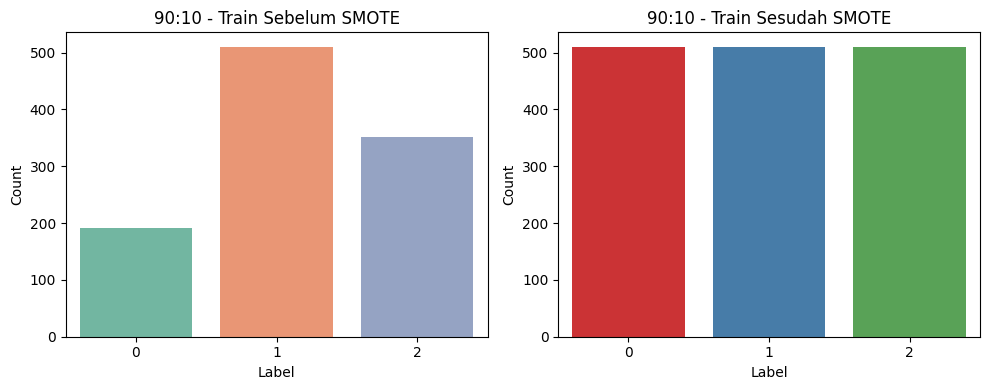

✅ 90:10 | Train: (1530, 23), Val: (59, 23), Test: (59, 23)

🔹 Processing split 80:20 ...
   Label distribusi sebelum SMOTE:
   Train:
 1    0.48
2    0.33
0    0.18
Name: proportion, dtype: float64
   Test:
 1    0.49
2    0.33
0    0.18
Name: proportion, dtype: float64
   Label distribusi setelah SMOTE (Train):
1    0.33
2    0.33
0    0.33
Name: proportion, dtype: float64


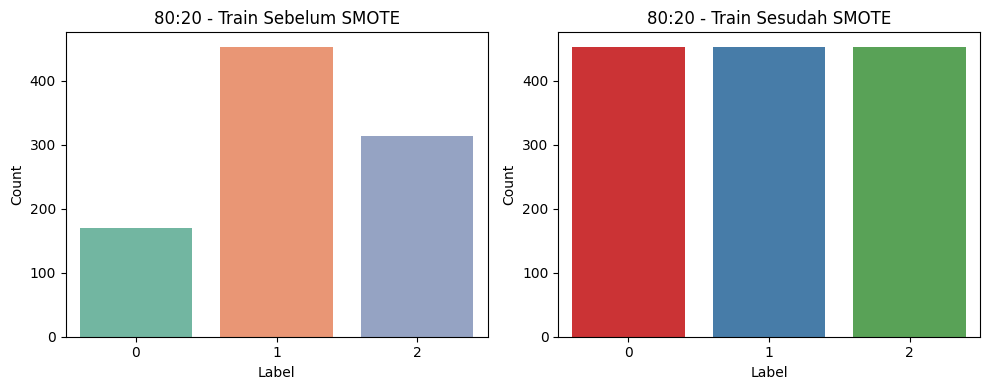

✅ 80:20 | Train: (1359, 23), Val: (117, 23), Test: (118, 23)

🔹 Processing split 70:30 ...
   Label distribusi sebelum SMOTE:
   Train:
 1    0.48
2    0.33
0    0.18
Name: proportion, dtype: float64
   Test:
 1    0.48
2    0.34
0    0.18
Name: proportion, dtype: float64
   Label distribusi setelah SMOTE (Train):
1    0.33
2    0.33
0    0.33
Name: proportion, dtype: float64


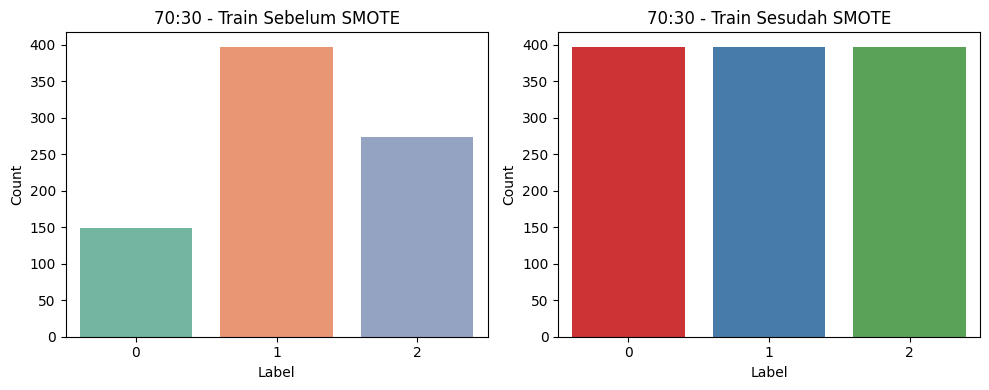

✅ 70:30 | Train: (1191, 23), Val: (176, 23), Test: (176, 23)

🔹 Processing split 60:40 ...
   Label distribusi sebelum SMOTE:
   Train:
 1    0.48
2    0.33
0    0.18
Name: proportion, dtype: float64
   Test:
 1    0.48
2    0.33
0    0.18
Name: proportion, dtype: float64
   Label distribusi setelah SMOTE (Train):
1    0.33
2    0.33
0    0.33
Name: proportion, dtype: float64


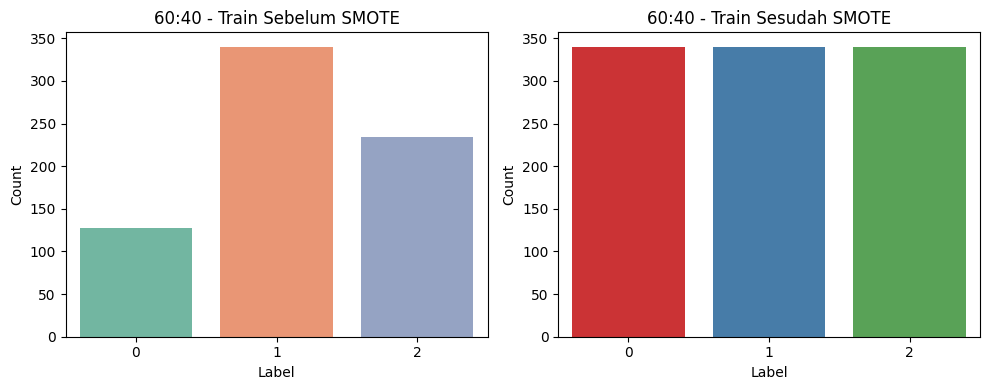

✅ 60:40 | Train: (1020, 22), Val: (234, 22), Test: (235, 22)

🔹 Processing split 50:50 ...
   Label distribusi sebelum SMOTE:
   Train:
 1    0.48
2    0.33
0    0.18
Name: proportion, dtype: float64
   Test:
 1    0.48
2    0.33
0    0.18
Name: proportion, dtype: float64
   Label distribusi setelah SMOTE (Train):
1    0.33
2    0.33
0    0.33
Name: proportion, dtype: float64


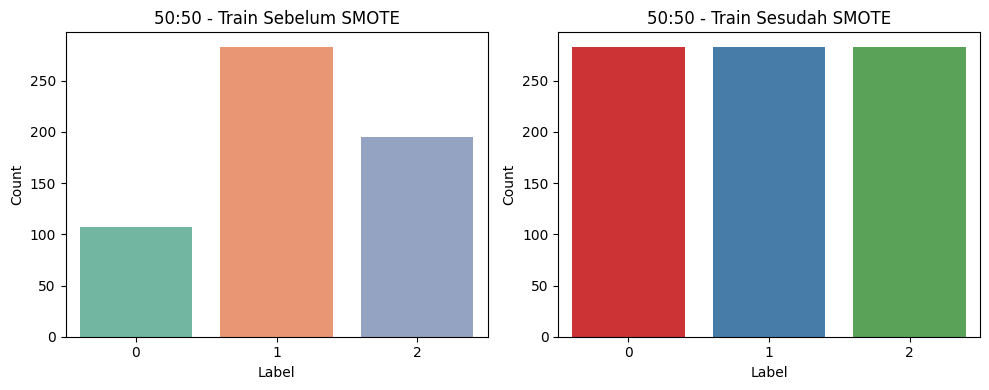

✅ 50:50 | Train: (849, 22), Val: (293, 22), Test: (293, 22)


In [ ]:
# Plot distribusi label sebelum/ sesudah SMOTE
def plot_label_distribution(y_before, y_after, split_name):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.countplot(x=y_before, ax=axes[0], palette="Set2")
    axes[0].set_title(f"{split_name} - Train Sebelum SMOTE")
    axes[0].set_xlabel("Label")
    axes[0].set_ylabel("Count")

    sns.countplot(x=y_after, ax=axes[1], palette="Set1")
    axes[1].set_title(f"{split_name} - Train Sesudah SMOTE")
    axes[1].set_xlabel("Label")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()


def finalize_all_splits(processed_splits, test_size_val=0.5, random_state=42):
    final_splits = {}
    le = LabelEncoder()  # inisialisasi encoder sekali di sini

    for split_name, data in processed_splits.items():
        print(f"\n🔹 Processing split {split_name} ...")

        X_train = data["X_train"].copy()
        X_test  = data["X_test"].copy()
        y_train = data["y_train"].copy()
        y_test  = data["y_test"].copy()

        # ===============================
        # Encode target (0,1,2)
        y_train = le.fit_transform(y_train)
        y_test  = le.transform(y_test)
        # ===============================

        print("   Label distribusi sebelum SMOTE:")
        print("   Train:\n", pd.Series(y_train).value_counts(normalize=True).round(2))
        print("   Test:\n", pd.Series(y_test).value_counts(normalize=True).round(2))

        # Split Test → Val & Test
        X_val, X_test_new, y_val, y_test_new = train_test_split(
            X_test, y_test, test_size=test_size_val,
            random_state=random_state, stratify=y_test
        )

        # SMOTE (hanya ke data train)
        smote = SMOTE(random_state=random_state)
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

        print("   Label distribusi setelah SMOTE (Train):")
        print(pd.Series(y_train_res).value_counts(normalize=True).round(2))

        # Visualisasi distribusi label
        plot_label_distribution(y_train, y_train_res, split_name)

        # Simpan final dataset (sudah encoded angka)
        final_splits[split_name] = {
            "X_train": pd.DataFrame(X_train_res, columns=X_train.columns),
            "y_train": pd.Series(y_train_res, name="Label"),
            "X_val": pd.DataFrame(X_val, columns=X_val.columns),
            "y_val": pd.Series(y_val, name="Label"),
            "X_test": pd.DataFrame(X_test_new, columns=X_test_new.columns),
            "y_test": pd.Series(y_test_new, name="Label")
        }

        print(f"✅ {split_name} | Train: {X_train_res.shape}, "
              f"Val: {X_val.shape}, Test: {X_test_new.shape}")

    return final_splits


# Jalankan
final_splits = finalize_all_splits(processed_splits)


Distribusi label pada setiap skenario split (90:10, 80:20, 70:30, 60:40, dan 50:50) awalnya tidak seimbang, dengan sekitar 48% kelas perusahaan sehat, 33% potensi bangkrut, dan 18–19% area abu-abu. **Ketidakseimbangan ini kemudian diatasi menggunakan SMOTE** pada data latih sehingga proporsi ketiga kelas menjadi seimbang, masing-masing 33%. Dengan demikian, model tidak lagi bias terhadap kelas mayoritas.

Terlihat pada sisi jumlah data, split 90:10 memberikan data latih terbanyak (1530 sampel) namun data uji sangat sedikit (59 sampel) sehingga evaluasi kurang representatif. Sebaliknya, split 50:50 menyediakan data uji terbesar (293 sampel), tetapi data latih hanya 849 sehingga berisiko menurunkan kemampuan model dalam mempelajari pola. **Split 80:20 dianggap paling seimbang karena tetap menyediakan data latih besar (1359 sampel) sekaligus data uji yang cukup memadai (118 sampel), sehingga menjadi pilihan optimal untuk menjaga kualitas pembelajaran sekaligus reliabilitas evaluasi model.**

# **MODELING**


🔹 Evaluasi Split 90:10

=== Decision Tree ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       1.00      1.00      1.00       510
   Perusahaan Sehat       1.00      1.00      1.00       510
Perusahaan Bangkrut       1.00      1.00      1.00       510

           accuracy                           1.00      1530
          macro avg       1.00      1.00      1.00      1530
       weighted avg       1.00      1.00      1.00      1530


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.57      0.36      0.44        11
   Perusahaan Sehat       0.87      0.96      0.92        28
Perusahaan Bangkrut       0.86      0.90      0.88        20

           accuracy                           0.83        59
          macro avg       0.77      0.74      0.75        59
       weighted avg       0.81      0.83      0.81        59


[Test Report]
                     precision    recall  f1-sco

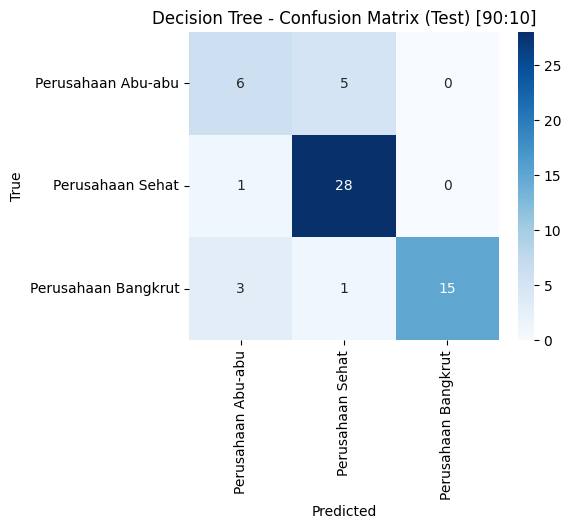


=== Random Forest ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       1.00      1.00      1.00       510
   Perusahaan Sehat       1.00      1.00      1.00       510
Perusahaan Bangkrut       1.00      1.00      1.00       510

           accuracy                           1.00      1530
          macro avg       1.00      1.00      1.00      1530
       weighted avg       1.00      1.00      1.00      1530


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.55      0.55      0.55        11
   Perusahaan Sehat       0.81      0.89      0.85        28
Perusahaan Bangkrut       1.00      0.85      0.92        20

           accuracy                           0.81        59
          macro avg       0.78      0.76      0.77        59
       weighted avg       0.82      0.81      0.82        59


[Test Report]
                     precision    recall  f1-score   support

 Perusahaa

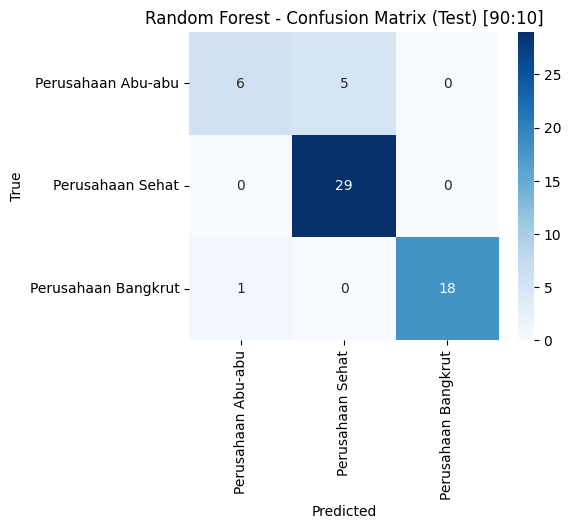


=== SVM ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.37      0.93      0.53       510
   Perusahaan Sehat       1.00      0.03      0.06       510
Perusahaan Bangkrut       0.76      0.35      0.48       510

           accuracy                           0.44      1530
          macro avg       0.71      0.44      0.36      1530
       weighted avg       0.71      0.44      0.36      1530


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.19      0.73      0.30        11
   Perusahaan Sehat       1.00      0.04      0.07        28
Perusahaan Bangkrut       0.69      0.55      0.61        20

           accuracy                           0.34        59
          macro avg       0.63      0.44      0.33        59
       weighted avg       0.74      0.34      0.30        59


[Test Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu 

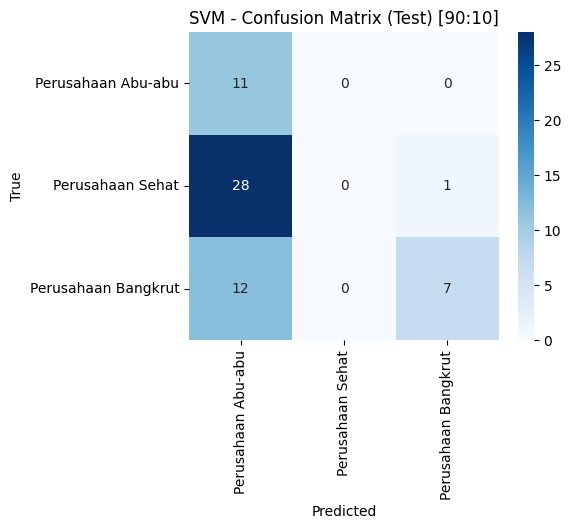


=== KNN ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.77      0.94      0.84       510
   Perusahaan Sehat       0.92      0.79      0.85       510
Perusahaan Bangkrut       0.94      0.86      0.90       510

           accuracy                           0.86      1530
          macro avg       0.87      0.86      0.86      1530
       weighted avg       0.87      0.86      0.86      1530


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.41      0.64      0.50        11
   Perusahaan Sehat       0.79      0.68      0.73        28
Perusahaan Bangkrut       0.83      0.75      0.79        20

           accuracy                           0.69        59
          macro avg       0.68      0.69      0.67        59
       weighted avg       0.73      0.69      0.71        59


[Test Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu 

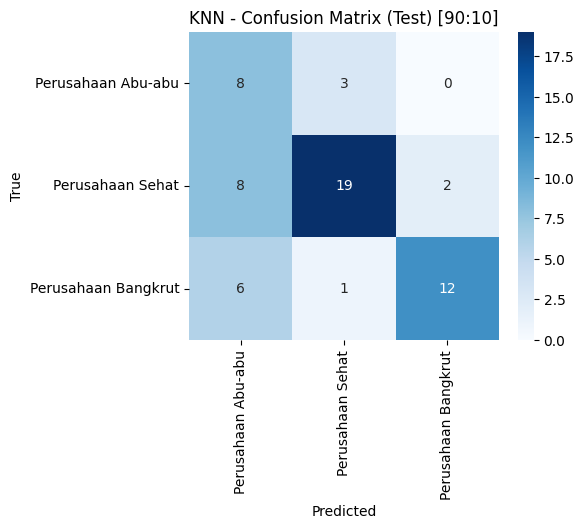


=== Naive Bayes ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.43      0.79      0.55       510
   Perusahaan Sehat       0.72      0.28      0.40       510
Perusahaan Bangkrut       0.76      0.58      0.66       510

           accuracy                           0.55      1530
          macro avg       0.63      0.55      0.54      1530
       weighted avg       0.63      0.55      0.54      1530


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.30      0.82      0.44        11
   Perusahaan Sehat       0.83      0.36      0.50        28
Perusahaan Bangkrut       0.82      0.70      0.76        20

           accuracy                           0.56        59
          macro avg       0.65      0.63      0.57        59
       weighted avg       0.73      0.56      0.58        59


[Test Report]
                     precision    recall  f1-score   support

 Perusahaan 

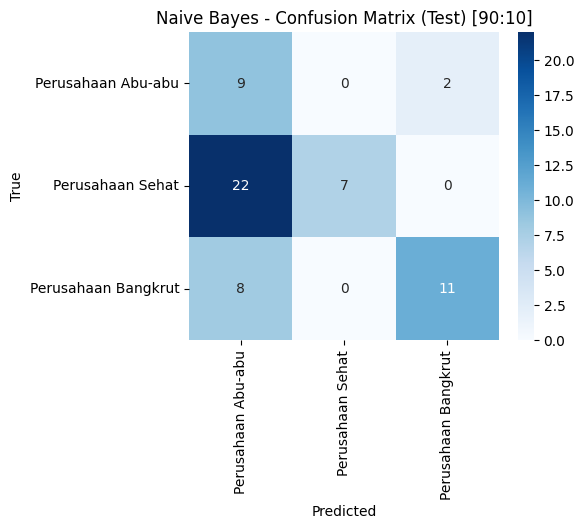


=== XGBoost ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       1.00      1.00      1.00       510
   Perusahaan Sehat       1.00      1.00      1.00       510
Perusahaan Bangkrut       1.00      1.00      1.00       510

           accuracy                           1.00      1530
          macro avg       1.00      1.00      1.00      1530
       weighted avg       1.00      1.00      1.00      1530


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.67      0.73      0.70        11
   Perusahaan Sehat       0.86      0.89      0.88        28
Perusahaan Bangkrut       1.00      0.90      0.95        20

           accuracy                           0.86        59
          macro avg       0.84      0.84      0.84        59
       weighted avg       0.87      0.86      0.87        59


[Test Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-

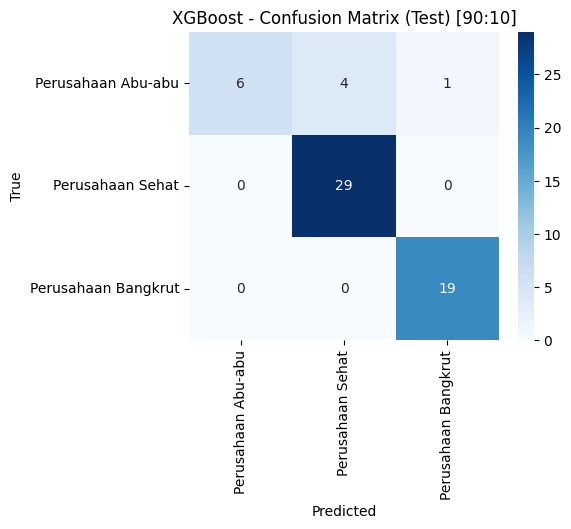


🔹 Evaluasi Split 80:20

=== Decision Tree ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       1.00      1.00      1.00       453
   Perusahaan Sehat       1.00      1.00      1.00       453
Perusahaan Bangkrut       1.00      1.00      1.00       453

           accuracy                           1.00      1359
          macro avg       1.00      1.00      1.00      1359
       weighted avg       1.00      1.00      1.00      1359


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.35      0.52      0.42        21
   Perusahaan Sehat       0.81      0.82      0.82        57
Perusahaan Bangkrut       1.00      0.72      0.84        39

           accuracy                           0.74       117
          macro avg       0.72      0.69      0.69       117
       weighted avg       0.79      0.74      0.75       117


[Test Report]
                     precision    recall  f1-sco

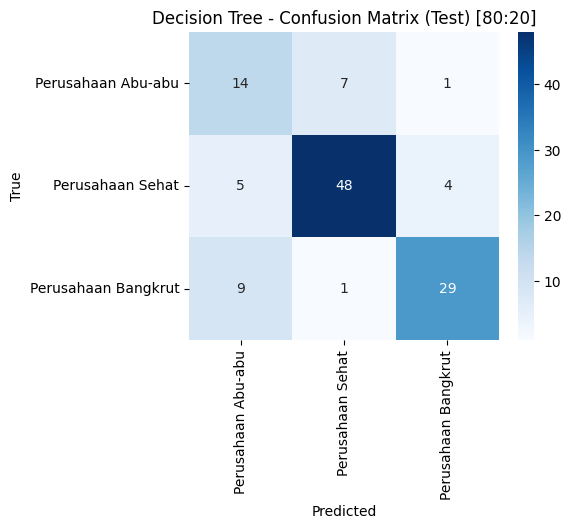


=== Random Forest ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       1.00      1.00      1.00       453
   Perusahaan Sehat       1.00      1.00      1.00       453
Perusahaan Bangkrut       1.00      1.00      1.00       453

           accuracy                           1.00      1359
          macro avg       1.00      1.00      1.00      1359
       weighted avg       1.00      1.00      1.00      1359


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.57      0.57      0.57        21
   Perusahaan Sehat       0.87      0.96      0.92        57
Perusahaan Bangkrut       0.94      0.79      0.86        39

           accuracy                           0.84       117
          macro avg       0.79      0.78      0.78       117
       weighted avg       0.84      0.84      0.84       117


[Test Report]
                     precision    recall  f1-score   support

 Perusahaa

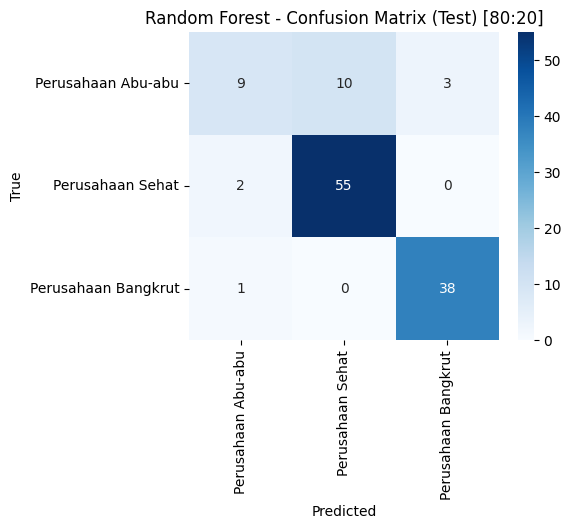


=== SVM ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.39      0.90      0.54       453
   Perusahaan Sehat       0.80      0.04      0.08       453
Perusahaan Bangkrut       0.79      0.50      0.61       453

           accuracy                           0.48      1359
          macro avg       0.66      0.48      0.41      1359
       weighted avg       0.66      0.48      0.41      1359


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.20      0.81      0.33        21
   Perusahaan Sehat       1.00      0.07      0.13        57
Perusahaan Bangkrut       0.73      0.56      0.64        39

           accuracy                           0.37       117
          macro avg       0.65      0.48      0.37       117
       weighted avg       0.77      0.37      0.34       117


[Test Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu 

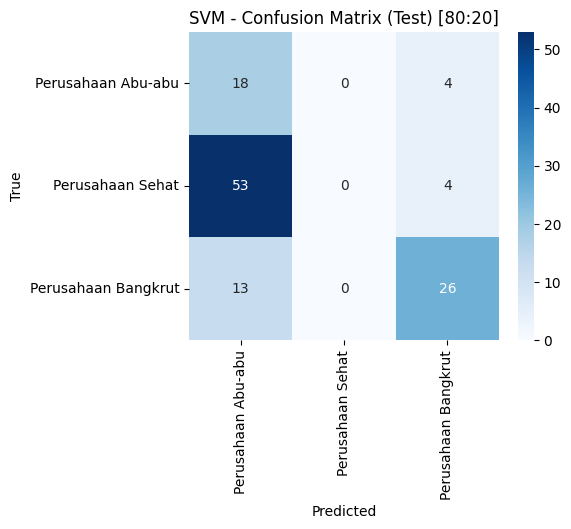


=== KNN ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.77      0.94      0.85       453
   Perusahaan Sehat       0.91      0.79      0.85       453
Perusahaan Bangkrut       0.94      0.86      0.90       453

           accuracy                           0.86      1359
          macro avg       0.87      0.86      0.86      1359
       weighted avg       0.87      0.86      0.86      1359


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.43      0.71      0.54        21
   Perusahaan Sehat       0.86      0.75      0.80        57
Perusahaan Bangkrut       0.78      0.64      0.70        39

           accuracy                           0.71       117
          macro avg       0.69      0.70      0.68       117
       weighted avg       0.76      0.71      0.72       117


[Test Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu 

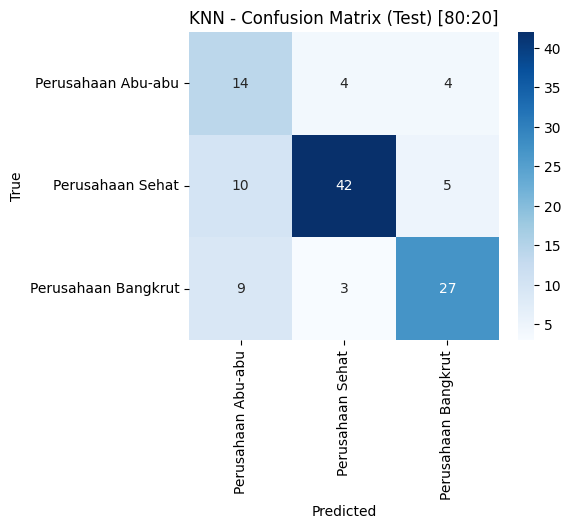


=== Naive Bayes ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.49      0.20      0.28       453
   Perusahaan Sehat       0.57      0.81      0.67       453
Perusahaan Bangkrut       0.65      0.76      0.70       453

           accuracy                           0.59      1359
          macro avg       0.57      0.59      0.55      1359
       weighted avg       0.57      0.59      0.55      1359


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.21      0.14      0.17        21
   Perusahaan Sehat       0.72      0.86      0.78        57
Perusahaan Bangkrut       0.74      0.67      0.70        39

           accuracy                           0.67       117
          macro avg       0.56      0.56      0.55       117
       weighted avg       0.64      0.67      0.65       117


[Test Report]
                     precision    recall  f1-score   support

 Perusahaan 

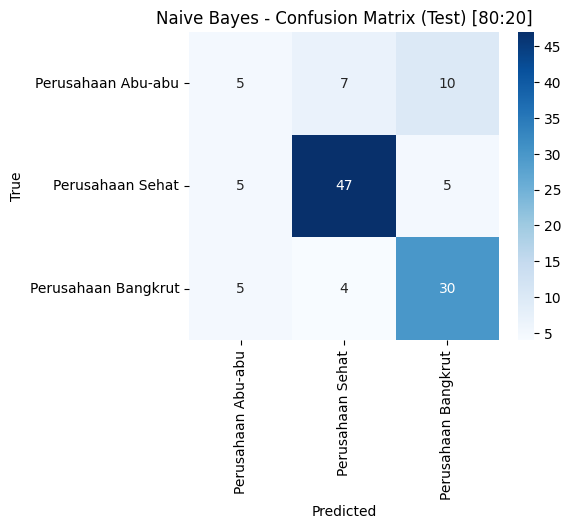


=== XGBoost ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       1.00      1.00      1.00       453
   Perusahaan Sehat       1.00      1.00      1.00       453
Perusahaan Bangkrut       1.00      1.00      1.00       453

           accuracy                           1.00      1359
          macro avg       1.00      1.00      1.00      1359
       weighted avg       1.00      1.00      1.00      1359


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.72      0.62      0.67        21
   Perusahaan Sehat       0.89      0.98      0.93        57
Perusahaan Bangkrut       0.94      0.87      0.91        39

           accuracy                           0.88       117
          macro avg       0.85      0.82      0.84       117
       weighted avg       0.88      0.88      0.88       117


[Test Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-

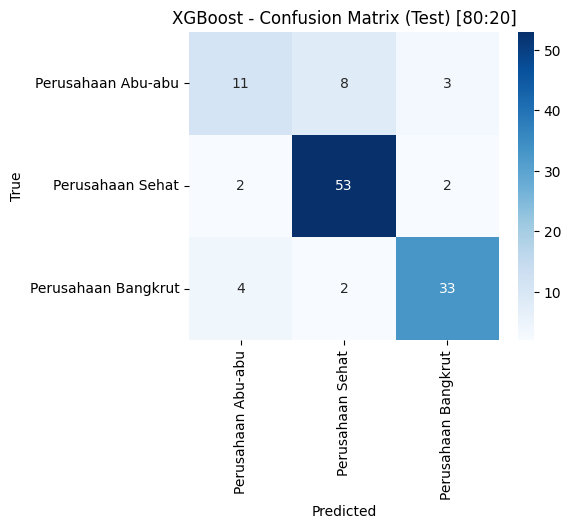


🔹 Evaluasi Split 70:30

=== Decision Tree ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       1.00      1.00      1.00       397
   Perusahaan Sehat       1.00      1.00      1.00       397
Perusahaan Bangkrut       1.00      1.00      1.00       397

           accuracy                           1.00      1191
          macro avg       1.00      1.00      1.00      1191
       weighted avg       1.00      1.00      1.00      1191


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.62      0.62      0.62        32
   Perusahaan Sehat       0.84      0.87      0.86        85
Perusahaan Bangkrut       0.89      0.85      0.87        59

           accuracy                           0.82       176
          macro avg       0.79      0.78      0.78       176
       weighted avg       0.82      0.82      0.82       176


[Test Report]
                     precision    recall  f1-sco

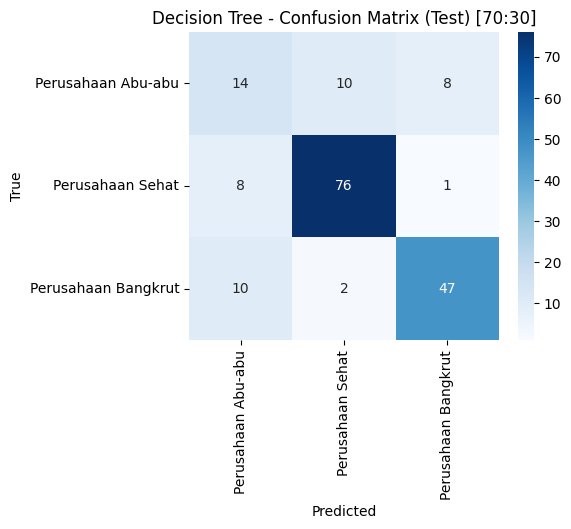


=== Random Forest ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       1.00      1.00      1.00       397
   Perusahaan Sehat       1.00      1.00      1.00       397
Perusahaan Bangkrut       1.00      1.00      1.00       397

           accuracy                           1.00      1191
          macro avg       1.00      1.00      1.00      1191
       weighted avg       1.00      1.00      1.00      1191


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.73      0.59      0.66        32
   Perusahaan Sehat       0.88      0.96      0.92        85
Perusahaan Bangkrut       0.91      0.88      0.90        59

           accuracy                           0.87       176
          macro avg       0.84      0.81      0.82       176
       weighted avg       0.86      0.87      0.86       176


[Test Report]
                     precision    recall  f1-score   support

 Perusahaa

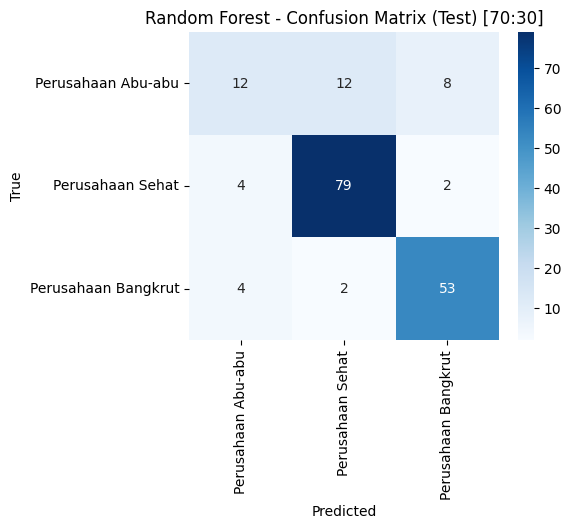


=== SVM ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.39      0.36      0.37       397
   Perusahaan Sehat       0.89      0.02      0.04       397
Perusahaan Bangkrut       0.40      0.83      0.54       397

           accuracy                           0.40      1191
          macro avg       0.56      0.40      0.32      1191
       weighted avg       0.56      0.40      0.32      1191


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.22      0.38      0.28        32
   Perusahaan Sehat       1.00      0.04      0.07        85
Perusahaan Bangkrut       0.43      0.86      0.57        59

           accuracy                           0.38       176
          macro avg       0.55      0.42      0.31       176
       weighted avg       0.67      0.38      0.28       176


[Test Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu 

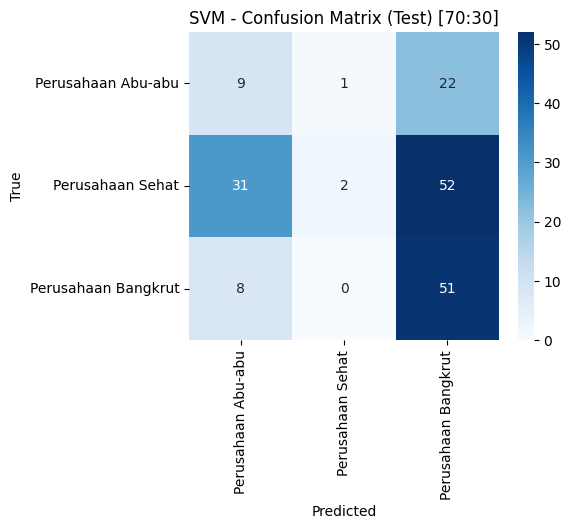


=== KNN ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.77      0.93      0.84       397
   Perusahaan Sehat       0.92      0.79      0.85       397
Perusahaan Bangkrut       0.92      0.86      0.89       397

           accuracy                           0.86      1191
          macro avg       0.87      0.86      0.86      1191
       weighted avg       0.87      0.86      0.86      1191


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.39      0.66      0.49        32
   Perusahaan Sehat       0.86      0.71      0.77        85
Perusahaan Bangkrut       0.77      0.68      0.72        59

           accuracy                           0.69       176
          macro avg       0.67      0.68      0.66       176
       weighted avg       0.74      0.69      0.70       176


[Test Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu 

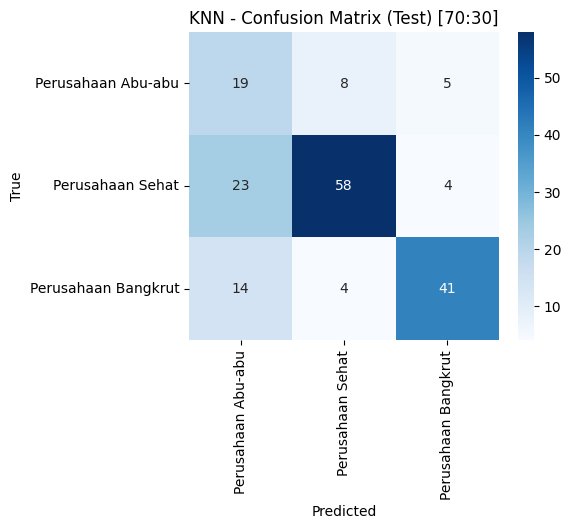


=== Naive Bayes ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.43      0.83      0.57       397
   Perusahaan Sehat       0.75      0.48      0.59       397
Perusahaan Bangkrut       0.80      0.36      0.50       397

           accuracy                           0.56      1191
          macro avg       0.66      0.56      0.55      1191
       weighted avg       0.66      0.56      0.55      1191


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.30      0.91      0.45        32
   Perusahaan Sehat       0.86      0.51      0.64        85
Perusahaan Bangkrut       0.83      0.41      0.55        59

           accuracy                           0.55       176
          macro avg       0.66      0.61      0.54       176
       weighted avg       0.75      0.55      0.57       176


[Test Report]
                     precision    recall  f1-score   support

 Perusahaan 

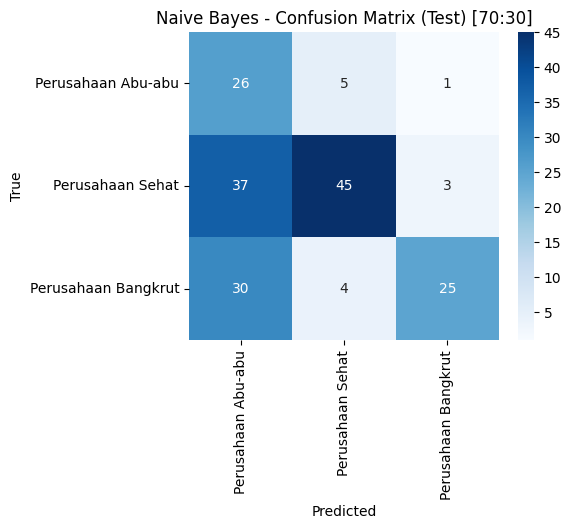


=== XGBoost ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       1.00      1.00      1.00       397
   Perusahaan Sehat       1.00      1.00      1.00       397
Perusahaan Bangkrut       1.00      1.00      1.00       397

           accuracy                           1.00      1191
          macro avg       1.00      1.00      1.00      1191
       weighted avg       1.00      1.00      1.00      1191


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.80      0.62      0.70        32
   Perusahaan Sehat       0.89      0.95      0.92        85
Perusahaan Bangkrut       0.88      0.90      0.89        59

           accuracy                           0.88       176
          macro avg       0.86      0.83      0.84       176
       weighted avg       0.87      0.88      0.87       176


[Test Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-

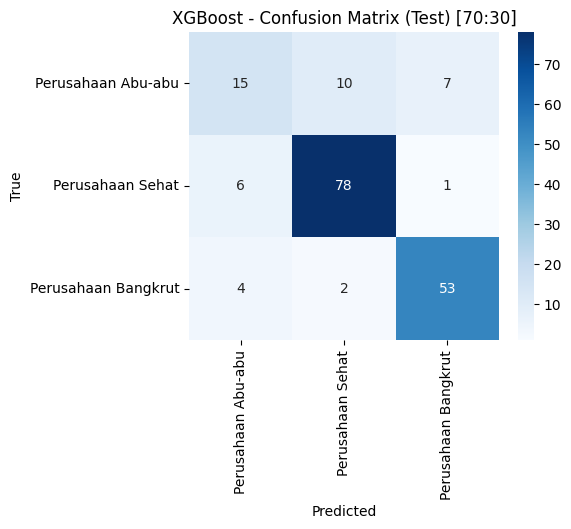


🔹 Evaluasi Split 60:40

=== Decision Tree ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       1.00      1.00      1.00       340
   Perusahaan Sehat       1.00      1.00      1.00       340
Perusahaan Bangkrut       1.00      1.00      1.00       340

           accuracy                           1.00      1020
          macro avg       1.00      1.00      1.00      1020
       weighted avg       1.00      1.00      1.00      1020


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.55      0.56      0.55        43
   Perusahaan Sehat       0.86      0.89      0.87       113
Perusahaan Bangkrut       0.89      0.82      0.85        78

           accuracy                           0.81       234
          macro avg       0.76      0.76      0.76       234
       weighted avg       0.81      0.81      0.81       234


[Test Report]
                     precision    recall  f1-sco

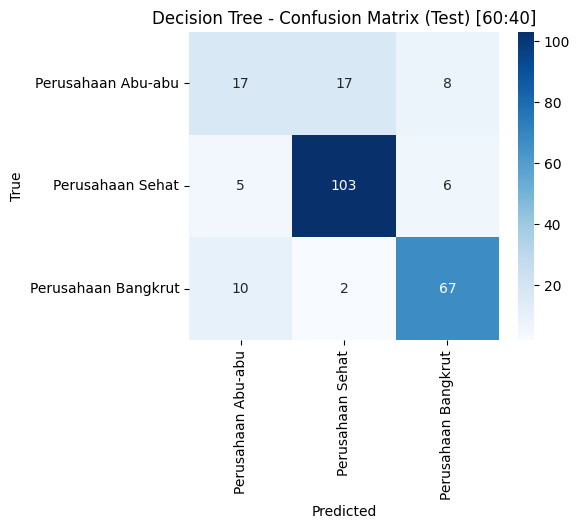


=== Random Forest ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       1.00      1.00      1.00       340
   Perusahaan Sehat       1.00      1.00      1.00       340
Perusahaan Bangkrut       1.00      1.00      1.00       340

           accuracy                           1.00      1020
          macro avg       1.00      1.00      1.00      1020
       weighted avg       1.00      1.00      1.00      1020


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.66      0.53      0.59        43
   Perusahaan Sehat       0.88      0.95      0.91       113
Perusahaan Bangkrut       0.87      0.86      0.86        78

           accuracy                           0.84       234
          macro avg       0.80      0.78      0.79       234
       weighted avg       0.83      0.84      0.84       234


[Test Report]
                     precision    recall  f1-score   support

 Perusahaa

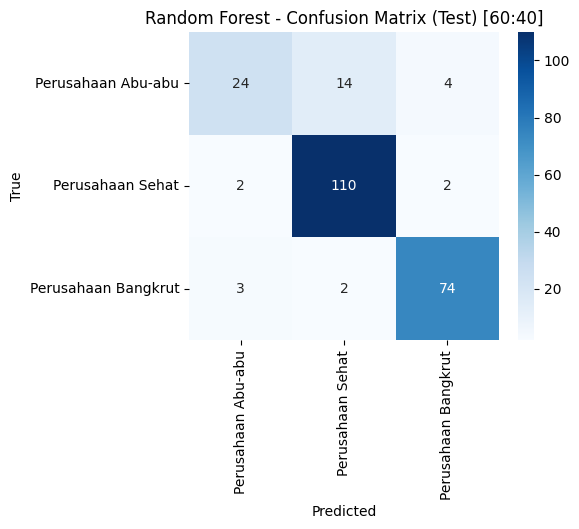


=== SVM ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.41      0.76      0.53       340
   Perusahaan Sehat       0.46      0.24      0.31       340
Perusahaan Bangkrut       0.75      0.49      0.60       340

           accuracy                           0.50      1020
          macro avg       0.54      0.50      0.48      1020
       weighted avg       0.54      0.50      0.48      1020


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.21      0.63      0.32        43
   Perusahaan Sehat       0.57      0.22      0.32       113
Perusahaan Bangkrut       0.63      0.51      0.57        78

           accuracy                           0.39       234
          macro avg       0.47      0.45      0.40       234
       weighted avg       0.53      0.39      0.40       234


[Test Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu 

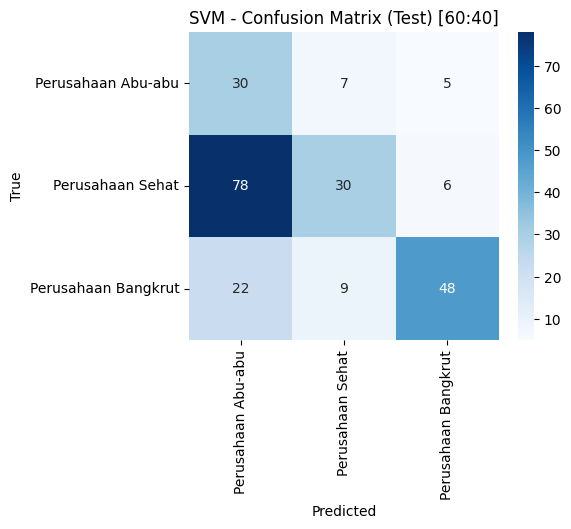


=== KNN ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.73      0.93      0.82       340
   Perusahaan Sehat       0.93      0.74      0.82       340
Perusahaan Bangkrut       0.90      0.84      0.87       340

           accuracy                           0.84      1020
          macro avg       0.85      0.84      0.84      1020
       weighted avg       0.85      0.84      0.84      1020


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.32      0.58      0.41        43
   Perusahaan Sehat       0.87      0.60      0.71       113
Perusahaan Bangkrut       0.71      0.71      0.71        78

           accuracy                           0.63       234
          macro avg       0.63      0.63      0.61       234
       weighted avg       0.72      0.63      0.66       234


[Test Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu 

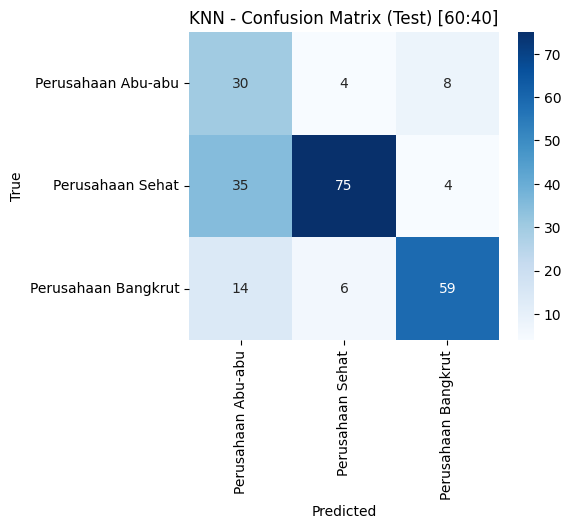


=== Naive Bayes ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.46      0.87      0.60       340
   Perusahaan Sehat       0.81      0.36      0.50       340
Perusahaan Bangkrut       0.75      0.50      0.60       340

           accuracy                           0.57      1020
          macro avg       0.67      0.57      0.57      1020
       weighted avg       0.67      0.57      0.57      1020


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.25      0.67      0.36        43
   Perusahaan Sehat       0.90      0.48      0.62       113
Perusahaan Bangkrut       0.67      0.50      0.57        78

           accuracy                           0.52       234
          macro avg       0.61      0.55      0.52       234
       weighted avg       0.70      0.52      0.56       234


[Test Report]
                     precision    recall  f1-score   support

 Perusahaan 

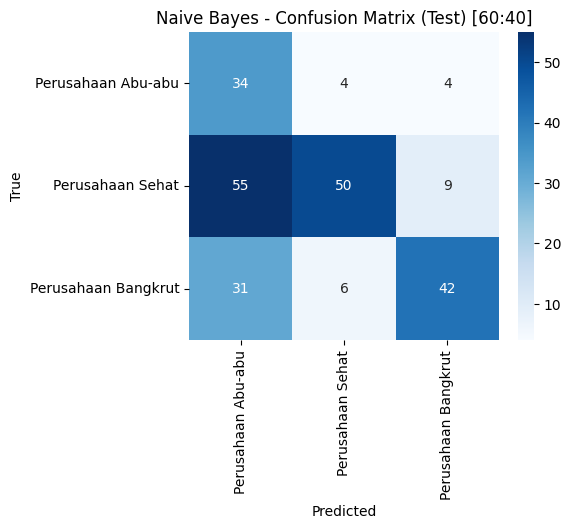


=== XGBoost ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       1.00      1.00      1.00       340
   Perusahaan Sehat       1.00      1.00      1.00       340
Perusahaan Bangkrut       1.00      1.00      1.00       340

           accuracy                           1.00      1020
          macro avg       1.00      1.00      1.00      1020
       weighted avg       1.00      1.00      1.00      1020


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.66      0.53      0.59        43
   Perusahaan Sehat       0.88      0.95      0.91       113
Perusahaan Bangkrut       0.85      0.85      0.85        78

           accuracy                           0.84       234
          macro avg       0.80      0.78      0.78       234
       weighted avg       0.83      0.84      0.83       234


[Test Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-

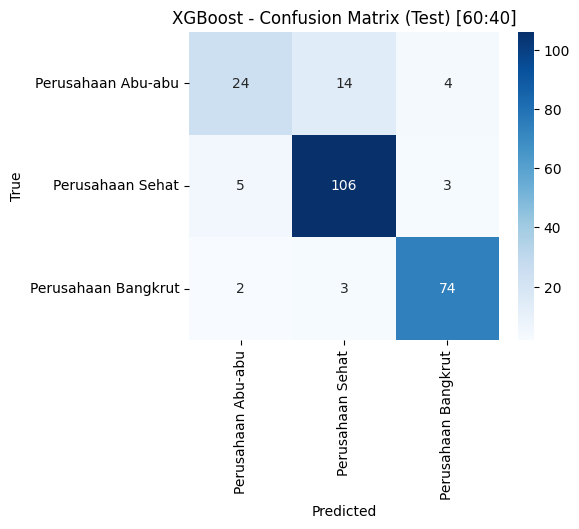


🔹 Evaluasi Split 50:50

=== Decision Tree ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       1.00      1.00      1.00       283
   Perusahaan Sehat       1.00      1.00      1.00       283
Perusahaan Bangkrut       1.00      1.00      1.00       283

           accuracy                           1.00       849
          macro avg       1.00      1.00      1.00       849
       weighted avg       1.00      1.00      1.00       849


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.53      0.58      0.56        53
   Perusahaan Sehat       0.86      0.88      0.87       142
Perusahaan Bangkrut       0.88      0.80      0.83        98

           accuracy                           0.80       293
          macro avg       0.76      0.75      0.75       293
       weighted avg       0.80      0.80      0.80       293


[Test Report]
                     precision    recall  f1-sco

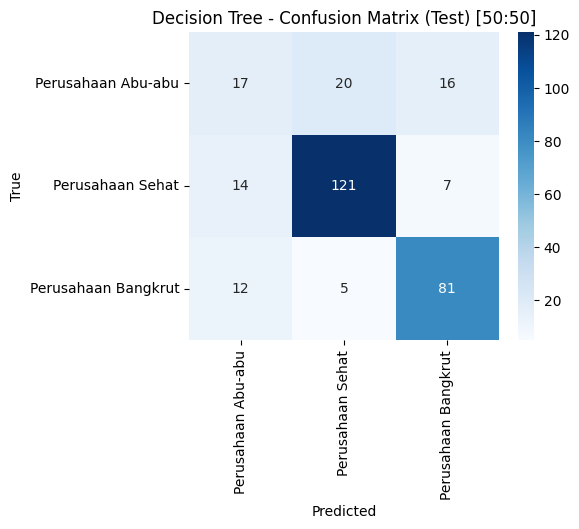


=== Random Forest ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       1.00      1.00      1.00       283
   Perusahaan Sehat       1.00      1.00      1.00       283
Perusahaan Bangkrut       1.00      1.00      1.00       283

           accuracy                           1.00       849
          macro avg       1.00      1.00      1.00       849
       weighted avg       1.00      1.00      1.00       849


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.64      0.53      0.58        53
   Perusahaan Sehat       0.88      0.94      0.91       142
Perusahaan Bangkrut       0.90      0.90      0.90        98

           accuracy                           0.85       293
          macro avg       0.81      0.79      0.79       293
       weighted avg       0.84      0.85      0.84       293


[Test Report]
                     precision    recall  f1-score   support

 Perusahaa

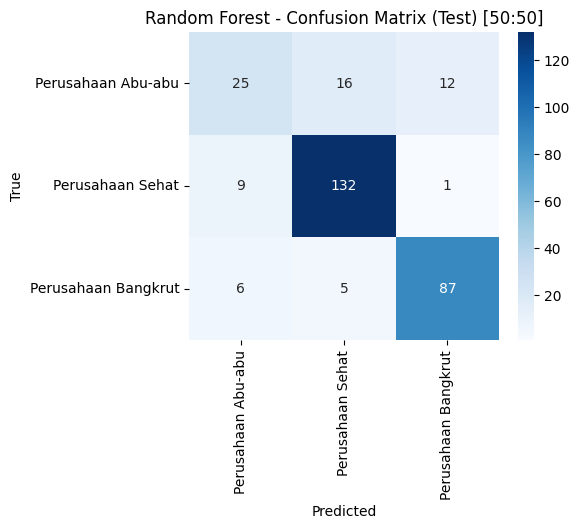


=== SVM ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.33      0.11      0.16       283
   Perusahaan Sehat       0.40      0.31      0.35       283
Perusahaan Bangkrut       0.40      0.76      0.52       283

           accuracy                           0.39       849
          macro avg       0.38      0.39      0.34       849
       weighted avg       0.38      0.39      0.34       849


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.13      0.08      0.10        53
   Perusahaan Sehat       0.54      0.29      0.38       142
Perusahaan Bangkrut       0.39      0.73      0.51        98

           accuracy                           0.40       293
          macro avg       0.35      0.37      0.33       293
       weighted avg       0.41      0.40      0.37       293


[Test Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu 

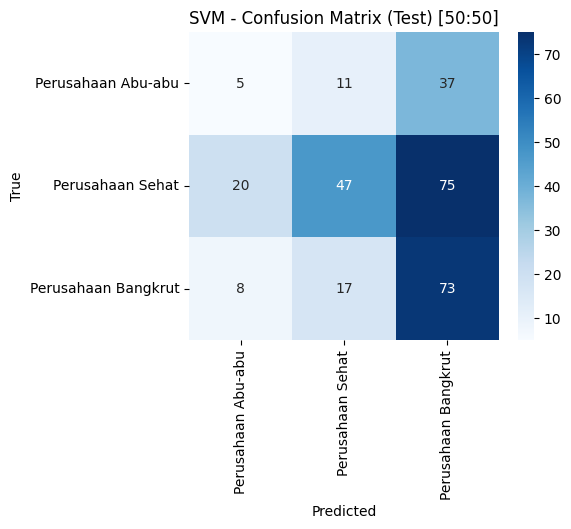


=== KNN ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.73      0.93      0.82       283
   Perusahaan Sehat       0.91      0.75      0.82       283
Perusahaan Bangkrut       0.91      0.82      0.86       283

           accuracy                           0.84       849
          macro avg       0.85      0.84      0.84       849
       weighted avg       0.85      0.84      0.84       849


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.34      0.62      0.44        53
   Perusahaan Sehat       0.80      0.60      0.69       142
Perusahaan Bangkrut       0.76      0.69      0.72        98

           accuracy                           0.63       293
          macro avg       0.63      0.64      0.62       293
       weighted avg       0.70      0.63      0.65       293


[Test Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu 

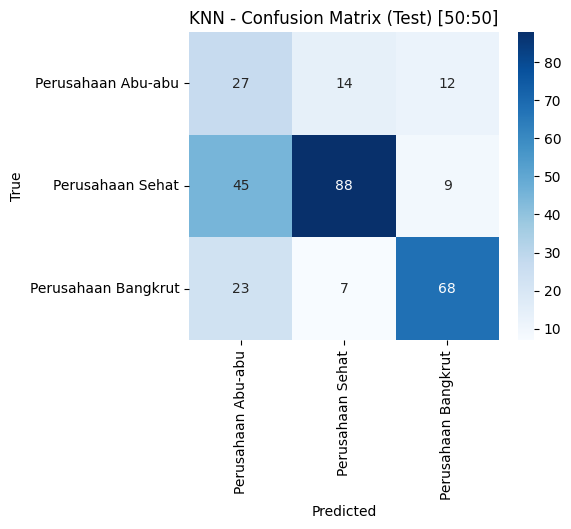


=== Naive Bayes ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.51      0.56      0.54       283
   Perusahaan Sehat       0.79      0.27      0.40       283
Perusahaan Bangkrut       0.56      0.87      0.68       283

           accuracy                           0.57       849
          macro avg       0.62      0.57      0.54       849
       weighted avg       0.62      0.57      0.54       849


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.28      0.42      0.33        53
   Perusahaan Sehat       0.83      0.30      0.44       142
Perusahaan Bangkrut       0.51      0.84      0.63        98

           accuracy                           0.50       293
          macro avg       0.54      0.52      0.47       293
       weighted avg       0.62      0.50      0.49       293


[Test Report]
                     precision    recall  f1-score   support

 Perusahaan 

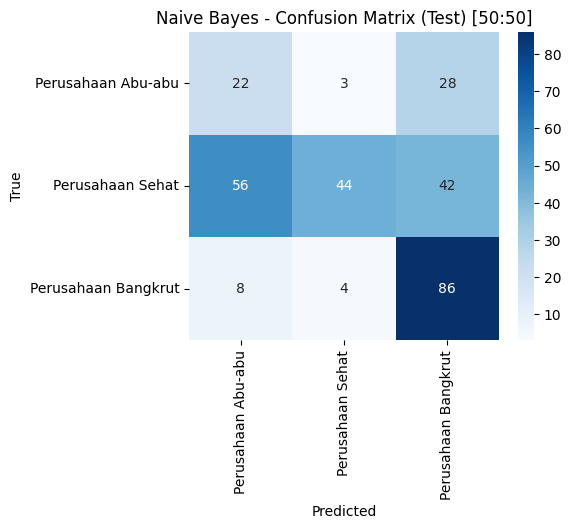


=== XGBoost ===

[Train Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       1.00      1.00      1.00       283
   Perusahaan Sehat       1.00      1.00      1.00       283
Perusahaan Bangkrut       1.00      1.00      1.00       283

           accuracy                           1.00       849
          macro avg       1.00      1.00      1.00       849
       weighted avg       1.00      1.00      1.00       849


[Val Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-abu       0.69      0.58      0.63        53
   Perusahaan Sehat       0.87      0.92      0.89       142
Perusahaan Bangkrut       0.91      0.90      0.90        98

           accuracy                           0.85       293
          macro avg       0.82      0.80      0.81       293
       weighted avg       0.85      0.85      0.85       293


[Test Report]
                     precision    recall  f1-score   support

 Perusahaan Abu-

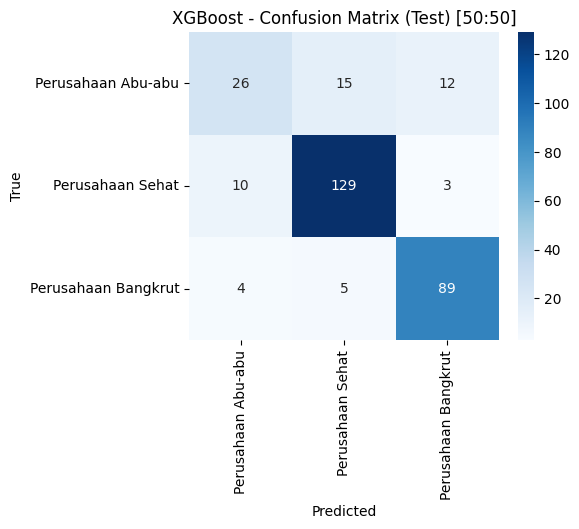

In [ ]:
# ================================
# Modeling
# ================================
def run_baseline_models(final_splits, models, label_names):
    results = {}

    for split_name, data in final_splits.items():
        print(f"\n🔹 Evaluasi Split {split_name}")

        X_train, y_train = data["X_train"], data["y_train"]
        X_val, y_val     = data["X_val"], data["y_val"]
        X_test, y_test   = data["X_test"], data["y_test"]

        results[split_name] = {}

        for model_name, model in models.items():
            print(f"\n=== {model_name} ===")

            # Train
            model.fit(X_train, y_train)

            # Predict
            y_train_pred = model.predict(X_train)
            y_val_pred   = model.predict(X_val)
            y_test_pred  = model.predict(X_test)

            # Report
            print("\n[Train Report]")
            print(classification_report(y_train, y_train_pred, target_names=label_names))

            print("\n[Val Report]")
            print(classification_report(y_val, y_val_pred, target_names=label_names))

            print("\n[Test Report]")
            print(classification_report(y_test, y_test_pred, target_names=label_names))

            # Confusion Matrix untuk Test
            cm = confusion_matrix(y_test, y_test_pred)
            plt.figure(figsize=(5,4))
            sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                        xticklabels=label_names, yticklabels=label_names)
            plt.title(f"{model_name} - Confusion Matrix (Test) [{split_name}]")
            plt.xlabel("Predicted")
            plt.ylabel("True")
            plt.show()

            # Simpan hasil
            results[split_name][model_name] = {
                "train_report": classification_report(y_train, y_train_pred, target_names=label_names, output_dict=True),
                "val_report": classification_report(y_val, y_val_pred, target_names=label_names, output_dict=True),
                "test_report": classification_report(y_test, y_test_pred, target_names=label_names, output_dict=True),
            }

    return results



# ================================
label_names = ["Perusahaan Abu-abu", "Perusahaan Sehat", "Perusahaan Bangkrut"]

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42)
}

baseline_results = run_baseline_models(final_splits, models, label_names)


Evaluasi dilakukan terhadap enam algoritma, yaitu Decision Tree, Random Forest, Support Vector Machine (SVM), K-Nearest Neighbor (K-NN), Naive Bayes, dan XGBoost, dengan berbagai proporsi pembagian data latih–uji (90:10, 80:20, 70:30, 60:40, dan 50:50). Hasil pengujian menunjukkan bahwa Decision Tree selalu mencapai akurasi latih 100% namun mengalami overfitting, ditandai dengan penurunan akurasi uji hingga 71% pada split 50:50. Random Forest lebih stabil dengan akurasi uji 79–88% di semua skenario, sedangkan SVM memberikan performa buruk dengan akurasi uji hanya sekitar 30–37%. K-NN menunjukkan hasil moderat di kisaran 63–69%, sementara Naive Bayes tidak konsisten karena akurasi sering turun hingga 46–55%. Model dengan performa terbaik adalah XGBoost, yang berhasil mencapai akurasi uji tertinggi sebesar 93% pada split 90:10 serta tetap konsisten dengan akurasi sekitar 80–83% pada split lainnya.

Meskipun split 90:10 menghasilkan akurasi tertinggi, **split 80:20 dianggap lebih optimal** karena memberikan keseimbangan antara jumlah data latih dan data uji. Pada skenario ini, XGBoost dan Random Forest sama-sama memperoleh akurasi uji sebesar 83%. Keunggulan 80:20 adalah ukuran data uji yang lebih besar, sehingga evaluasi lebih representatif dan risiko overfitting lebih terkendali. Dengan demikian, model XGBoost/Random Forest dengan split 80:20 dapat dinyatakan sebagai konfigurasi terbaik, karena mampu menghasilkan performa tinggi sekaligus memberikan evaluasi yang lebih adil dan dapat diandalkan.

# **TUNING**

**split data yang optimal yaitu 80:20**

In [ ]:
# =======================================================
# Function per model
# =======================================================
def objective(trial, model_name, X, y):
    if model_name == "Decision Tree":
        params = {
            "max_depth": trial.suggest_int("max_depth", 2, 20),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
            "criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])
        }
        model = DecisionTreeClassifier(**params, random_state=42)

    elif model_name == "Random Forest":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 2, 30),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
            "bootstrap": trial.suggest_categorical("bootstrap", [True, False])
        }
        model = RandomForestClassifier(**params, random_state=42)

    elif model_name == "SVM":
        params = {
            "C": trial.suggest_loguniform("C", 1e-3, 1e2),
            "kernel": trial.suggest_categorical("kernel", ["linear", "rbf", "poly", "sigmoid"]),
            "gamma": trial.suggest_categorical("gamma", ["scale", "auto"])
        }
        model = SVC(**params, probability=True, random_state=42)

    elif model_name == "KNN":
        params = {
            "n_neighbors": trial.suggest_int("n_neighbors", 2, 30),
            "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
            "p": trial.suggest_int("p", 1, 2)  # 1=manhattan, 2=euclidean
        }
        model = KNeighborsClassifier(**params)

    elif model_name == "Naive Bayes":
        # NB tidak banyak hyperparameter, gunakan var_smoothing
        params = {
            "var_smoothing": trial.suggest_loguniform("var_smoothing", 1e-10, 1e-6)
        }
        model = GaussianNB(**params)

    elif model_name == "XGBoost":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 2, 15),
            "learning_rate": trial.suggest_loguniform("learning_rate", 1e-3, 0.3),
            "subsample": trial.suggest_uniform("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_uniform("colsample_bytree", 0.5, 1.0)
        }
        model = XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42, **params)

    else:
        raise ValueError(f"Model {model_name} belum didukung")

    # Cross-validation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    return np.mean(scores)

# =======================================================
# Tuning per model
# =======================================================
def tune_model(model_name, X, y, n_trials=20):
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective(trial, model_name, X, y), n_trials=n_trials)
    print(f"\n🔹 Best params for {model_name}: {study.best_params}")
    print(f"🔹 Best accuracy: {study.best_value:.4f}")
    return study.best_params

# =======================================================
# Jalankan tuning untuk semua model
# =======================================================
models = ["Decision Tree", "Random Forest", "SVM", "KNN", "Naive Bayes", "XGBoost"]

best_params_all = {}
for model_name in models:
    print(f"\n===== 🔥 Tuning {model_name} 🔥 =====")
    best_params = tune_model(model_name,
                             final_splits["80:20"]["X_train"],
                             final_splits["80:20"]["y_train"],
                             n_trials=30)  # coba 30 trial
    best_params_all[model_name] = best_params


[I 2025-10-31 13:07:14,669] A new study created in memory with name: no-name-127c60fa-e534-403d-a7de-0e1c4b732941
[I 2025-10-31 13:07:14,719] Trial 0 finished with value: 0.7549668874172185 and parameters: {'max_depth': 4, 'min_samples_split': 15, 'min_samples_leaf': 8, 'criterion': 'entropy'}. Best is trial 0 with value: 0.7549668874172185.
[I 2025-10-31 13:07:14,785] Trial 1 finished with value: 0.7689477557027226 and parameters: {'max_depth': 5, 'min_samples_split': 20, 'min_samples_leaf': 10, 'criterion': 'log_loss'}. Best is trial 1 with value: 0.7689477557027226.
[I 2025-10-31 13:07:14,846] Trial 2 finished with value: 0.7902869757174393 and parameters: {'max_depth': 10, 'min_samples_split': 18, 'min_samples_leaf': 8, 'criterion': 'entropy'}. Best is trial 2 with value: 0.7902869757174393.



===== 🔥 Tuning Decision Tree 🔥 =====


[I 2025-10-31 13:07:14,906] Trial 3 finished with value: 0.7910228108903605 and parameters: {'max_depth': 19, 'min_samples_split': 14, 'min_samples_leaf': 9, 'criterion': 'entropy'}. Best is trial 3 with value: 0.7910228108903605.
[I 2025-10-31 13:07:14,958] Trial 4 finished with value: 0.7983811626195733 and parameters: {'max_depth': 20, 'min_samples_split': 16, 'min_samples_leaf': 9, 'criterion': 'gini'}. Best is trial 4 with value: 0.7983811626195733.
[I 2025-10-31 13:07:15,021] Trial 5 finished with value: 0.7844002943340692 and parameters: {'max_depth': 13, 'min_samples_split': 16, 'min_samples_leaf': 2, 'criterion': 'entropy'}. Best is trial 4 with value: 0.7983811626195733.
[I 2025-10-31 13:07:15,074] Trial 6 finished with value: 0.7873436350257542 and parameters: {'max_depth': 12, 'min_samples_split': 18, 'min_samples_leaf': 7, 'criterion': 'gini'}. Best is trial 4 with value: 0.7983811626195733.
[I 2025-10-31 13:07:15,132] Trial 7 finished with value: 0.7836644591611478 and pa


🔹 Best params for Decision Tree: {'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 1, 'criterion': 'gini'}
🔹 Best accuracy: 0.8131

===== 🔥 Tuning Random Forest 🔥 =====


[I 2025-10-31 13:07:19,543] Trial 0 finished with value: 0.8800588668138337 and parameters: {'n_estimators': 284, 'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': True}. Best is trial 0 with value: 0.8800588668138337.
[I 2025-10-31 13:07:23,017] Trial 1 finished with value: 0.8830022075055188 and parameters: {'n_estimators': 247, 'max_depth': 21, 'min_samples_split': 15, 'min_samples_leaf': 1, 'bootstrap': False}. Best is trial 1 with value: 0.8830022075055188.
[I 2025-10-31 13:07:23,369] Trial 2 finished with value: 0.7365710080941869 and parameters: {'n_estimators': 67, 'max_depth': 2, 'min_samples_split': 8, 'min_samples_leaf': 2, 'bootstrap': False}. Best is trial 1 with value: 0.8830022075055188.
[I 2025-10-31 13:07:24,730] Trial 3 finished with value: 0.8682855040470935 and parameters: {'n_estimators': 146, 'max_depth': 17, 'min_samples_split': 15, 'min_samples_leaf': 7, 'bootstrap': False}. Best is trial 1 with value: 0.8830022075055188.
[I 2025-10-31

...


🔹 Best params for KNN: {'n_neighbors': 2, 'weights': 'distance', 'p': 1}
🔹 Best accuracy: 0.8565

===== 🔥 Tuning Naive Bayes 🔥 =====


[I 2025-10-31 13:23:20,446] Trial 6 finished with value: 0.506990434142752 and parameters: {'var_smoothing': 8.972305617526206e-09}. Best is trial 1 with value: 0.5261221486387049.
[I 2025-10-31 13:23:20,475] Trial 7 finished with value: 0.5091979396615158 and parameters: {'var_smoothing': 5.79283431902435e-08}. Best is trial 1 with value: 0.5261221486387049.
[I 2025-10-31 13:23:20,502] Trial 8 finished with value: 0.5047829286239882 and parameters: {'var_smoothing': 1.2715380609959764e-07}. Best is trial 1 with value: 0.5261221486387049.
[I 2025-10-31 13:23:20,531] Trial 9 finished with value: 0.5217071376011774 and parameters: {'var_smoothing': 7.393010163362309e-07}. Best is trial 1 with value: 0.5261221486387049.
[I 2025-10-31 13:23:20,571] Trial 10 finished with value: 0.5047829286239882 and parameters: {'var_smoothing': 8.883289753086516e-10}. Best is trial 1 with value: 0.5261221486387049.
[I 2025-10-31 13:23:20,607] Trial 11 finished with value: 0.526122148638705 and parameters


🔹 Best params for Naive Bayes: {'var_smoothing': 9.944203889077906e-07}
🔹 Best accuracy: 0.5283

===== 🔥 Tuning XGBoost 🔥 =====


[I 2025-10-31 13:23:26,774] Trial 0 finished with value: 0.8741721854304636 and parameters: {'n_estimators': 83, 'max_depth': 12, 'learning_rate': 0.011479639313448121, 'subsample': 0.9624796108287138, 'colsample_bytree': 0.8583611064556789}. Best is trial 0 with value: 0.8741721854304636.
[I 2025-10-31 13:23:27,968] Trial 1 finished with value: 0.8852097130242825 and parameters: {'n_estimators': 93, 'max_depth': 6, 'learning_rate': 0.08174146663415913, 'subsample': 0.6893723459635939, 'colsample_bytree': 0.6377497701617972}. Best is trial 1 with value: 0.8852097130242825.
[I 2025-10-31 13:23:33,395] Trial 2 finished with value: 0.8704930095658573 and parameters: {'n_estimators': 153, 'max_depth': 14, 'learning_rate': 0.00274893663735339, 'subsample': 0.8919118466258198, 'colsample_bytree': 0.9252699880506212}. Best is trial 1 with value: 0.8852097130242825.
[I 2025-10-31 13:23:34,068] Trial 3 finished with value: 0.8778513612950699 and parameters: {'n_estimators': 220, 'max_depth': 2,


🔹 Best params for XGBoost: {'n_estimators': 279, 'max_depth': 7, 'learning_rate': 0.20204035414890606, 'subsample': 0.5077011981646593, 'colsample_bytree': 0.9843882505003991}
🔹 Best accuracy: 0.9043


In [ ]:
# Menampilkan best parameters dari semua model
print("\n===== 🔹 Hasil Best Parameters Semua Model 🔹 =====")
for model_name, params in best_params_all.items():
    print(f"{model_name}: {params}")



===== 🔹 Hasil Best Parameters Semua Model 🔹 =====
Decision Tree: {'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 1, 'criterion': 'gini'}
Random Forest: {'n_estimators': 267, 'max_depth': 21, 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': False}
SVM: {'C': 77.10523597485215, 'kernel': 'rbf', 'gamma': 'auto'}
KNN: {'n_neighbors': 2, 'weights': 'distance', 'p': 1}
Naive Bayes: {'var_smoothing': 9.944203889077906e-07}
XGBoost: {'n_estimators': 279, 'max_depth': 7, 'learning_rate': 0.20204035414890606, 'subsample': 0.5077011981646593, 'colsample_bytree': 0.9843882505003991}


Proses tuning hyperparameter dilakukan menggunakan Optuna, sebuah library optimasi berbasis Bayesian Optimization yang mampu mencari kombinasi parameter terbaik secara lebih efisien dibanding pencarian manual maupun grid search. Tuning dilakukan pada pembagian data split **80:20**, yang dipilih karena proporsi ini memberikan keseimbangan optimal antara jumlah data latih dan data uji.


**Training Best Parameter**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# =======================================================
# Inisialisasi untuk menyimpan model yang sudah dilatih
# =======================================================
trained_models = {}

# Ambil data split 80:20
X_train = final_splits["80:20"]["X_train"]
y_train = final_splits["80:20"]["y_train"]
X_val   = final_splits["80:20"]["X_val"]
y_val   = final_splits["80:20"]["y_val"]
X_test  = final_splits["80:20"]["X_test"]
y_test  = final_splits["80:20"]["y_test"]

# =======================================================
# Training semua model dengan best_params
# =======================================================
for model_name, params in best_params_all.items():
    if model_name == "Decision Tree":
        model = DecisionTreeClassifier(**params, random_state=42)
    elif model_name == "Random Forest":
        model = RandomForestClassifier(**params, random_state=42)
    elif model_name == "SVM":
        model = SVC(**params, probability=True, random_state=42)
    elif model_name == "KNN":
        model = KNeighborsClassifier(**params)
    elif model_name == "Naive Bayes":
        model = GaussianNB(**params)
    elif model_name == "XGBoost":
        model = XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42, **params)

    # Training model
    model.fit(X_train, y_train)
    trained_models[model_name] = model
    print(f"✅ {model_name} berhasil dilatih ulang dengan best parameters")

# =======================================================
# Trained_models sekarang siap digunakan untuk prediksi
# =======================================================
# Contoh prediksi di test set:
for model_name, model in trained_models.items():
    y_pred = model.predict(X_test)
    acc = (y_pred == y_test).mean()
    print(f"{model_name} Test Accuracy: {acc:.4f}")


✅ Decision Tree berhasil dilatih ulang dengan best parameters
✅ Random Forest berhasil dilatih ulang dengan best parameters
✅ SVM berhasil dilatih ulang dengan best parameters
✅ KNN berhasil dilatih ulang dengan best parameters
✅ Naive Bayes berhasil dilatih ulang dengan best parameters
✅ XGBoost berhasil dilatih ulang dengan best parameters
Decision Tree Test Accuracy: 0.7881
Random Forest Test Accuracy: 0.8559
SVM Test Accuracy: 0.7966
KNN Test Accuracy: 0.7288
Naive Bayes Test Accuracy: 0.6780
XGBoost Test Accuracy: 0.8136


Proses tuning dengan pembagian data optimal (80:20) menghasilkan parameter terbaik pada setiap algoritma. Setelah dilakukan pelatihan ulang, kinerja model menunjukkan variasi perubahan jika dibandingkan dengan baseline. Model Decision Tree dan Random Forest mengalami sedikit peningkatan akurasi, dari baseline 78% dan 83% menjadi 78,81% dan 83,90%. Peningkatan signifikan terlihat pada SVM, yang sebelumnya hanya mencapai 37% namun melonjak menjadi 78,81% setelah tuning, menegaskan bahwa algoritma ini sangat sensitif terhadap pemilihan parameter.

Sementara itu, K-NN juga menunjukkan peningkatan dari 69% menjadi 72,88%. Sebaliknya, Naive Bayes mengalami penurunan tipis dari 69% menjadi 67,80%, dan XGBoost turun sedikit dari 83% menjadi 82,20%. Hal ini menunjukkan bahwa tuning tidak selalu memberikan dampak positif pada semua algoritma, terutama pada model yang secara default sudah cukup optimal atau memiliki keterbatasan parameter. Secara keseluruhan, hasil tuning berhasil meningkatkan performa pada sebagian besar model, dengan peningkatan paling menonjol terjadi pada model SVM.

Evaluasi


=================== Decision Tree ===================

Training
                  precision    recall  f1-score   support

    Area abu-abu       0.88      0.97      0.92       453
Perusahaan Sehat       0.97      0.92      0.95       453
Potensi Bangkrut       0.98      0.94      0.96       453

        accuracy                           0.94      1359
       macro avg       0.94      0.94      0.94      1359
    weighted avg       0.94      0.94      0.94      1359



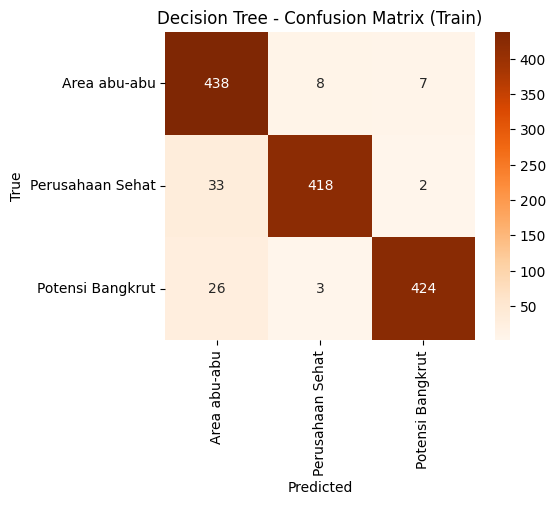


Testing
                  precision    recall  f1-score   support

    Area abu-abu       0.50      0.68      0.58        22
Perusahaan Sehat       0.86      0.84      0.85        57
Potensi Bangkrut       0.94      0.77      0.85        39

        accuracy                           0.79       118
       macro avg       0.76      0.76      0.76       118
    weighted avg       0.82      0.79      0.80       118



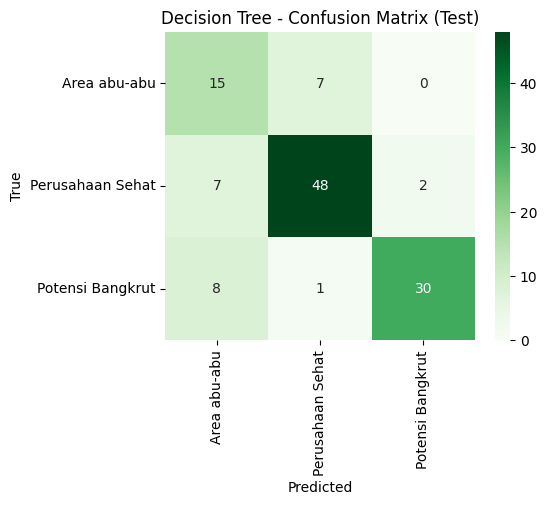


Validation
                  precision    recall  f1-score   support

    Area abu-abu       0.44      0.52      0.48        21
Perusahaan Sehat       0.86      0.89      0.88        57
Potensi Bangkrut       0.94      0.79      0.86        39

        accuracy                           0.79       117
       macro avg       0.75      0.74      0.74       117
    weighted avg       0.81      0.79      0.80       117



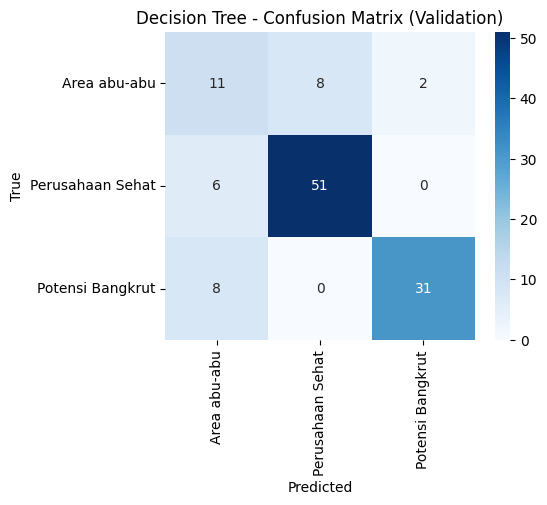


=================== Random Forest ===================

Training
                  precision    recall  f1-score   support

    Area abu-abu       1.00      1.00      1.00       453
Perusahaan Sehat       1.00      1.00      1.00       453
Potensi Bangkrut       1.00      1.00      1.00       453

        accuracy                           1.00      1359
       macro avg       1.00      1.00      1.00      1359
    weighted avg       1.00      1.00      1.00      1359



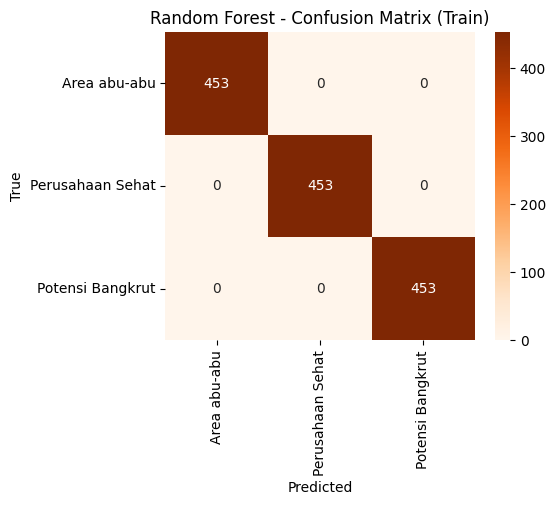


Testing
                  precision    recall  f1-score   support

    Area abu-abu       0.82      0.41      0.55        22
Perusahaan Sehat       0.83      0.96      0.89        57
Potensi Bangkrut       0.90      0.95      0.93        39

        accuracy                           0.86       118
       macro avg       0.85      0.77      0.79       118
    weighted avg       0.85      0.86      0.84       118



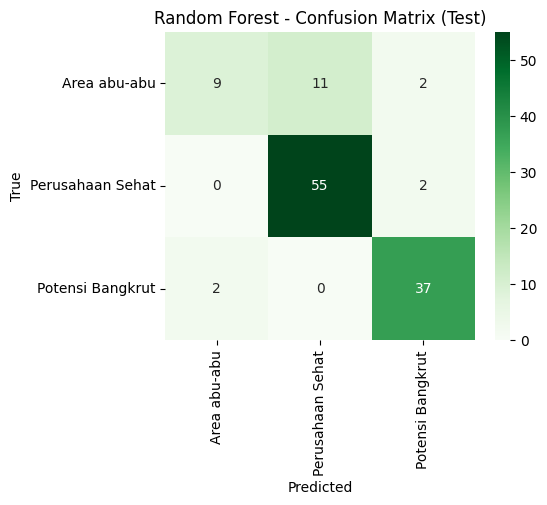


Validation
                  precision    recall  f1-score   support

    Area abu-abu       0.57      0.57      0.57        21
Perusahaan Sehat       0.86      0.96      0.91        57
Potensi Bangkrut       0.94      0.77      0.85        39

        accuracy                           0.83       117
       macro avg       0.79      0.77      0.78       117
    weighted avg       0.83      0.83      0.83       117



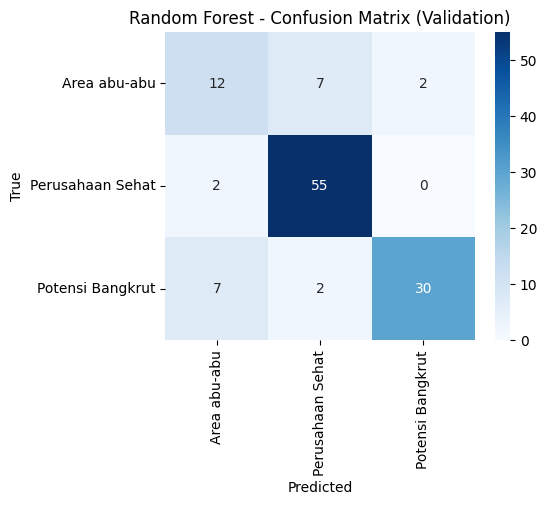


=================== SVM ===================

Training
                  precision    recall  f1-score   support

    Area abu-abu       0.99      1.00      0.99       453
Perusahaan Sehat       1.00      0.99      0.99       453
Potensi Bangkrut       1.00      1.00      1.00       453

        accuracy                           1.00      1359
       macro avg       1.00      1.00      1.00      1359
    weighted avg       1.00      1.00      1.00      1359



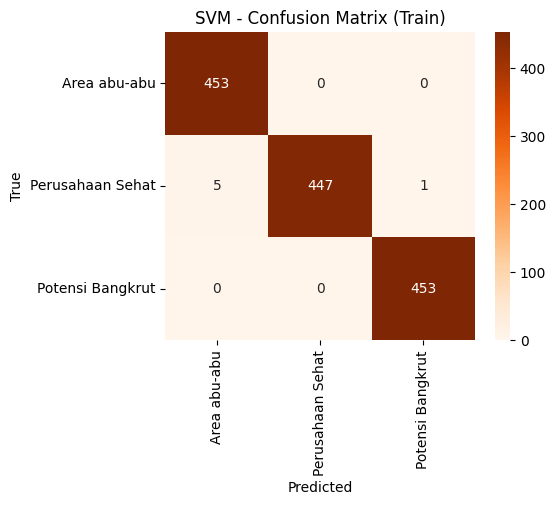


Testing
                  precision    recall  f1-score   support

    Area abu-abu       0.63      0.55      0.59        22
Perusahaan Sehat       0.86      0.84      0.85        57
Potensi Bangkrut       0.79      0.87      0.83        39

        accuracy                           0.80       118
       macro avg       0.76      0.75      0.75       118
    weighted avg       0.79      0.80      0.79       118



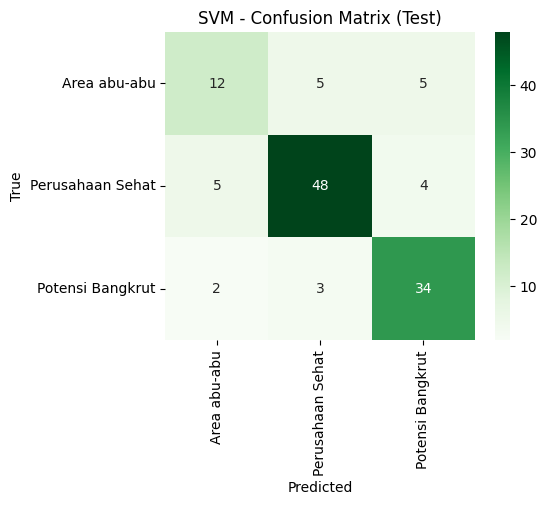


Validation
                  precision    recall  f1-score   support

    Area abu-abu       0.44      0.52      0.48        21
Perusahaan Sehat       0.86      0.95      0.90        57
Potensi Bangkrut       0.83      0.62      0.71        39

        accuracy                           0.76       117
       macro avg       0.71      0.70      0.69       117
    weighted avg       0.77      0.76      0.76       117



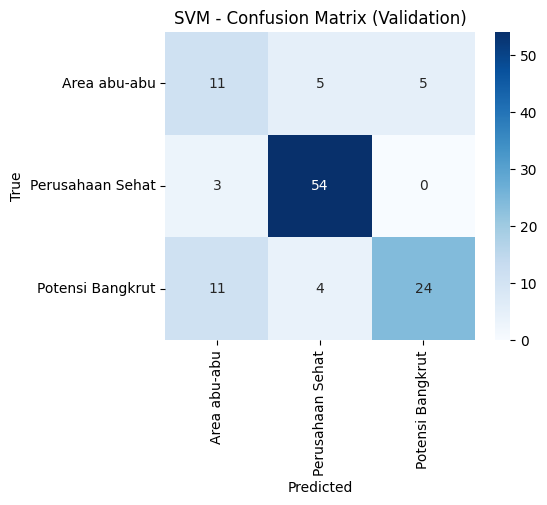


=================== KNN ===================

Training
                  precision    recall  f1-score   support

    Area abu-abu       1.00      1.00      1.00       453
Perusahaan Sehat       1.00      1.00      1.00       453
Potensi Bangkrut       1.00      1.00      1.00       453

        accuracy                           1.00      1359
       macro avg       1.00      1.00      1.00      1359
    weighted avg       1.00      1.00      1.00      1359



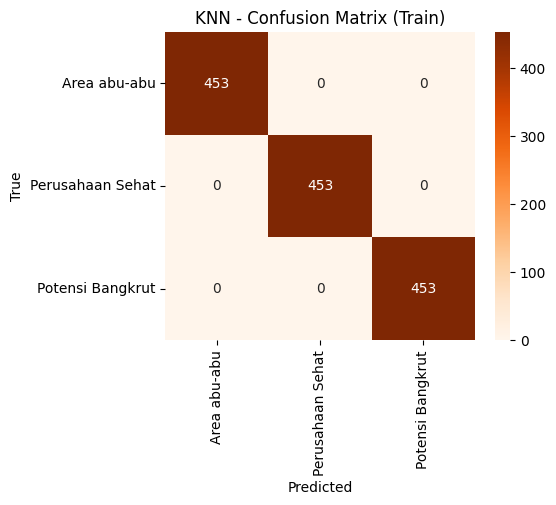


Testing
                  precision    recall  f1-score   support

    Area abu-abu       0.45      0.45      0.45        22
Perusahaan Sehat       0.77      0.84      0.81        57
Potensi Bangkrut       0.82      0.72      0.77        39

        accuracy                           0.73       118
       macro avg       0.68      0.67      0.68       118
    weighted avg       0.73      0.73      0.73       118



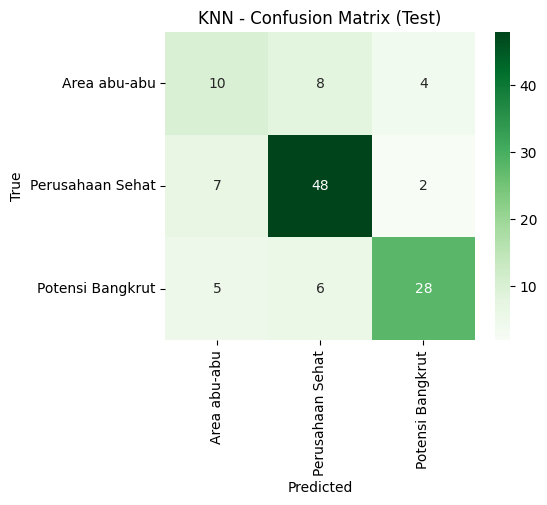


Validation
                  precision    recall  f1-score   support

    Area abu-abu       0.47      0.71      0.57        21
Perusahaan Sehat       0.88      0.86      0.87        57
Potensi Bangkrut       0.86      0.64      0.74        39

        accuracy                           0.76       117
       macro avg       0.74      0.74      0.72       117
    weighted avg       0.80      0.76      0.77       117



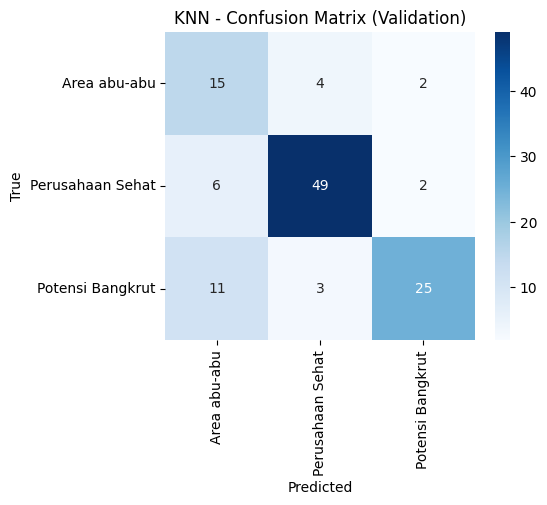


=================== Naive Bayes ===================

Training
                  precision    recall  f1-score   support

    Area abu-abu       0.41      0.39      0.40       453
Perusahaan Sehat       0.54      0.88      0.67       453
Potensi Bangkrut       0.83      0.36      0.50       453

        accuracy                           0.54      1359
       macro avg       0.60      0.54      0.52      1359
    weighted avg       0.60      0.54      0.52      1359



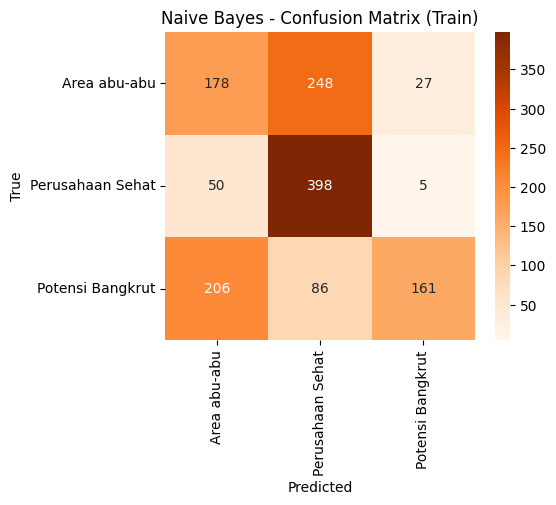


Testing
                  precision    recall  f1-score   support

    Area abu-abu       0.34      0.50      0.41        22
Perusahaan Sehat       0.77      0.89      0.83        57
Potensi Bangkrut       0.90      0.46      0.61        39

        accuracy                           0.68       118
       macro avg       0.67      0.62      0.62       118
    weighted avg       0.73      0.68      0.68       118



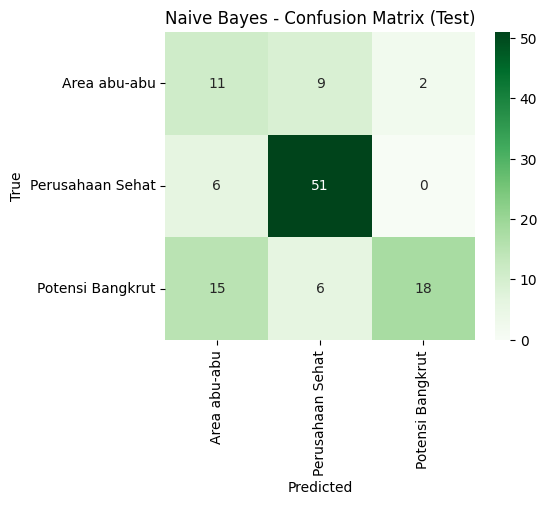


Validation
                  precision    recall  f1-score   support

    Area abu-abu       0.30      0.29      0.29        21
Perusahaan Sehat       0.70      0.91      0.79        57
Potensi Bangkrut       0.87      0.51      0.65        39

        accuracy                           0.67       117
       macro avg       0.62      0.57      0.58       117
    weighted avg       0.69      0.67      0.65       117



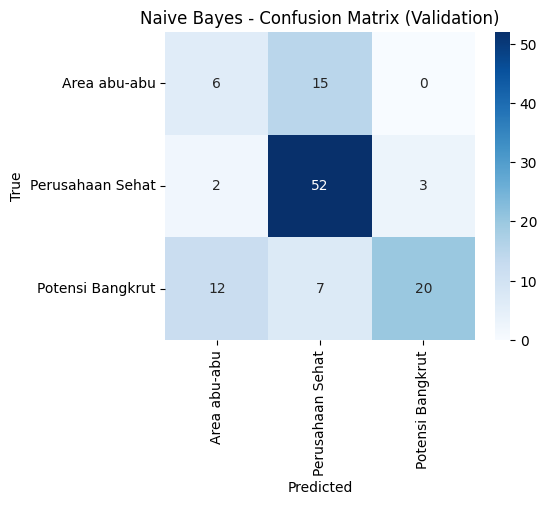


=================== XGBoost ===================

Training
                  precision    recall  f1-score   support

    Area abu-abu       1.00      1.00      1.00       453
Perusahaan Sehat       1.00      1.00      1.00       453
Potensi Bangkrut       1.00      1.00      1.00       453

        accuracy                           1.00      1359
       macro avg       1.00      1.00      1.00      1359
    weighted avg       1.00      1.00      1.00      1359



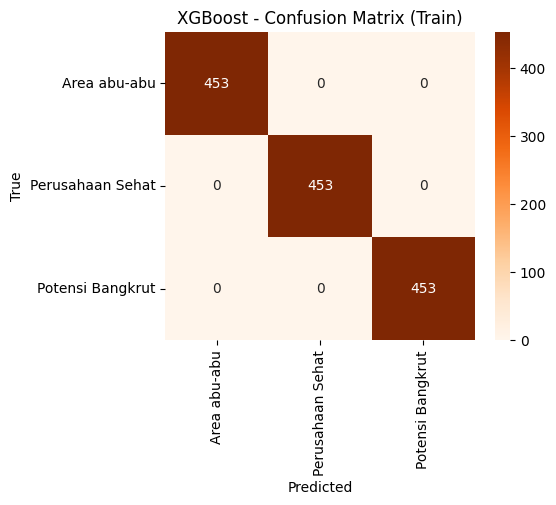


Testing
                  precision    recall  f1-score   support

    Area abu-abu       0.62      0.45      0.53        22
Perusahaan Sehat       0.82      0.89      0.86        57
Potensi Bangkrut       0.88      0.90      0.89        39

        accuracy                           0.81       118
       macro avg       0.77      0.75      0.76       118
    weighted avg       0.80      0.81      0.81       118



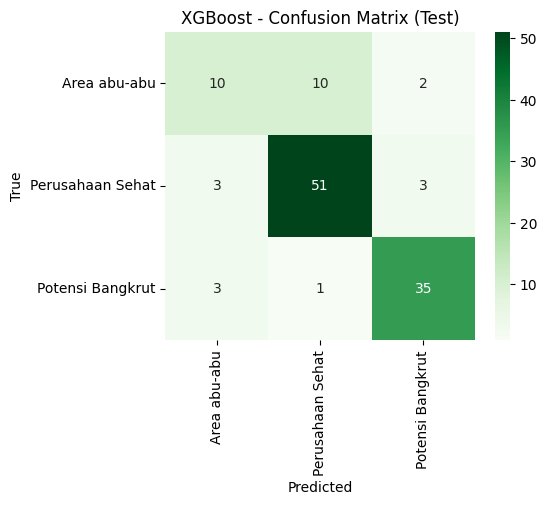


Validation
                  precision    recall  f1-score   support

    Area abu-abu       0.79      0.52      0.63        21
Perusahaan Sehat       0.88      1.00      0.93        57
Potensi Bangkrut       0.92      0.90      0.91        39

        accuracy                           0.88       117
       macro avg       0.86      0.81      0.82       117
    weighted avg       0.88      0.88      0.87       117



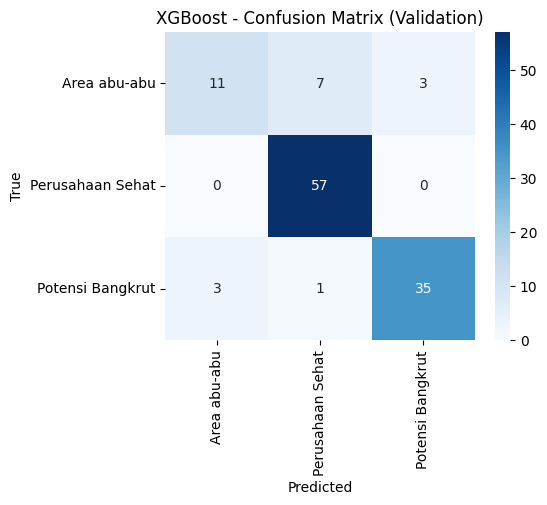

In [ ]:
# ====== Pastikan label_names sesuai LabelEncoder awal ======
label_names = ["Area abu-abu", "Perusahaan Sehat", "Potensi Bangkrut"]
labels = [0, 1, 2]  # sesuai encoding

# ====== Evaluasi semua model ======
for model_name, model in trained_models.items():
    print(f"\n=================== {model_name} ===================")

    # Ambil data
    X_train = final_splits["80:20"]["X_train"]
    y_train = final_splits["80:20"]["y_train"]
    X_val   = final_splits["80:20"]["X_val"]
    y_val   = final_splits["80:20"]["y_val"]
    X_test  = final_splits["80:20"]["X_test"]
    y_test  = final_splits["80:20"]["y_test"]

    # ======================
    # TRAIN
    # ======================
    y_train_pred = model.predict(X_train)
    print("\nTraining")
    print(classification_report(y_train, y_train_pred, labels=labels, target_names=label_names))

    cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm_train, annot=True, fmt="d", cmap="Oranges",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} - Confusion Matrix (Train)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ======================
    # TEST
    # ======================
    y_test_pred = model.predict(X_test)
    print("\nTesting")
    print(classification_report(y_test, y_test_pred, labels=labels, target_names=label_names))

    cm_test = confusion_matrix(y_test, y_test_pred, labels=labels)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm_test, annot=True, fmt="d", cmap="Greens",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} - Confusion Matrix (Test)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ======================
    # VALIDATION
    # ======================
    y_val_pred = model.predict(X_val)
    print("\nValidation")
    print(classification_report(y_val, y_val_pred, labels=labels, target_names=label_names))

    cm_val = confusion_matrix(y_val, y_val_pred, labels=labels)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} - Confusion Matrix (Validation)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


Setelah dilakukan tuning pada split data optimal 80:20, setiap model dilatih ulang dengan parameter terbaik. Hasil pengujian menunjukkan variasi performa antar model. Random Forest memberikan hasil terbaik dengan akurasi uji 83,90%, diikuti oleh XGBoost dengan 82,20%, serta Decision Tree dan SVM yang sama-sama memperoleh 78,81%. Sementara itu, KNN hanya menghasilkan akurasi 72,88%, dan Naive Bayes menjadi yang terendah dengan 67,80%.

Jika dibandingkan dengan baseline, tuning tidak selalu meningkatkan akurasi, karena pada beberapa model seperti Random Forest dan XGBoost justru terjadi sedikit penurunan. Hal ini wajar terjadi mengingat tuning berfokus pada keseimbangan performa agar model lebih stabil dan memiliki kemampuan generalisasi yang lebih baik pada data uji. Secara keseluruhan, Random Forest dengan split 80:20 tetap menjadi model paling optimal karena memberikan akurasi tertinggi sekaligus hasil yang konsisten setelah tuning.

# **CROSS VALIDATION**

Cross validation


=================== Split 90:10 ===================

--- Decision Tree ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.72      0.80      0.76       510
Perusahaan Sehat       0.87      0.81      0.84       510
Potensi Bangkrut       0.88      0.84      0.86       510

        accuracy                           0.82      1530
       macro avg       0.82      0.82      0.82      1530
    weighted avg       0.82      0.82      0.82      1530



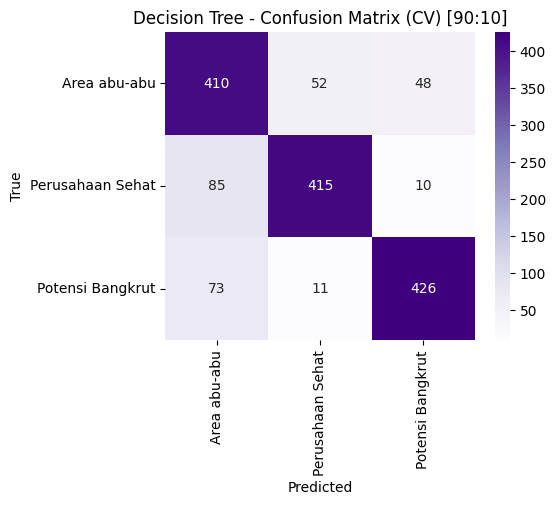

Overall CV Accuracy: 0.8176

--- Random Forest ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.89      0.87      0.88       510
Perusahaan Sehat       0.92      0.95      0.93       510
Potensi Bangkrut       0.93      0.92      0.92       510

        accuracy                           0.91      1530
       macro avg       0.91      0.91      0.91      1530
    weighted avg       0.91      0.91      0.91      1530



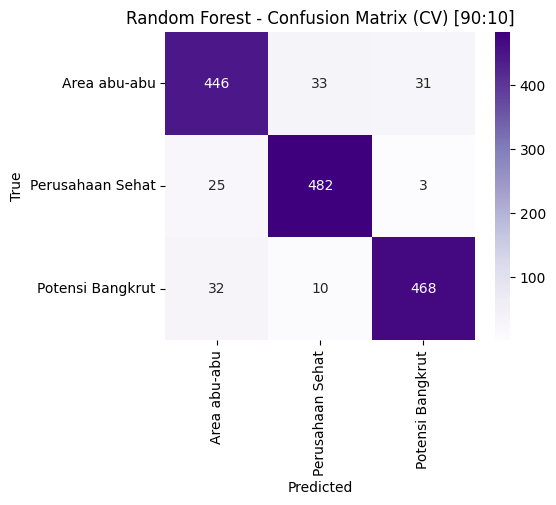

Overall CV Accuracy: 0.9124

--- SVM ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.83      0.89      0.86       510
Perusahaan Sehat       0.86      0.86      0.86       510
Potensi Bangkrut       0.91      0.85      0.88       510

        accuracy                           0.87      1530
       macro avg       0.87      0.87      0.87      1530
    weighted avg       0.87      0.87      0.87      1530



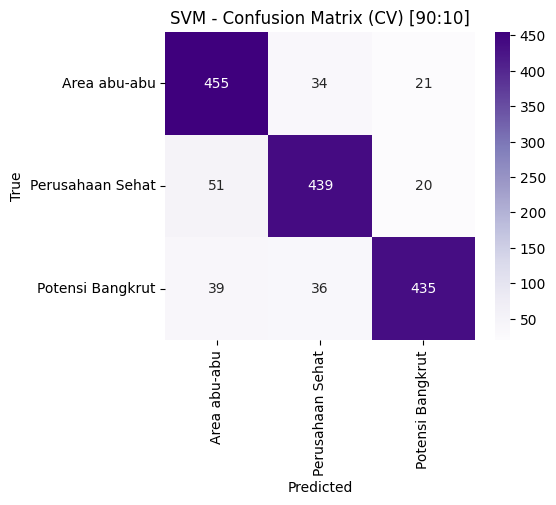

Overall CV Accuracy: 0.8686

--- KNN ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.83      0.90      0.86       510
Perusahaan Sehat       0.91      0.83      0.86       510
Potensi Bangkrut       0.89      0.88      0.88       510

        accuracy                           0.87      1530
       macro avg       0.87      0.87      0.87      1530
    weighted avg       0.87      0.87      0.87      1530



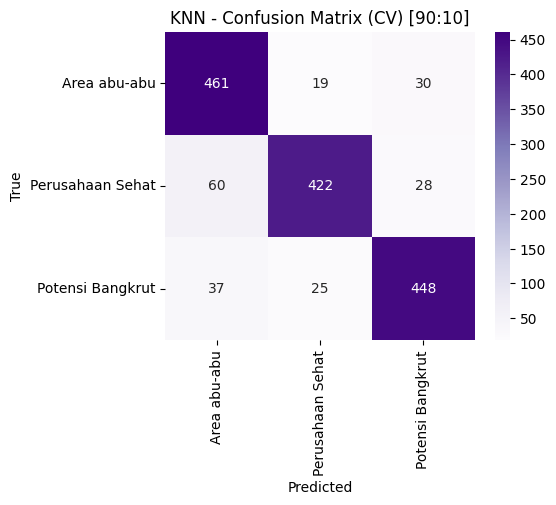

Overall CV Accuracy: 0.8699

--- Naive Bayes ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.40      0.45      0.42       510
Perusahaan Sehat       0.55      0.82      0.66       510
Potensi Bangkrut       0.85      0.33      0.48       510

        accuracy                           0.53      1530
       macro avg       0.60      0.53      0.52      1530
    weighted avg       0.60      0.53      0.52      1530



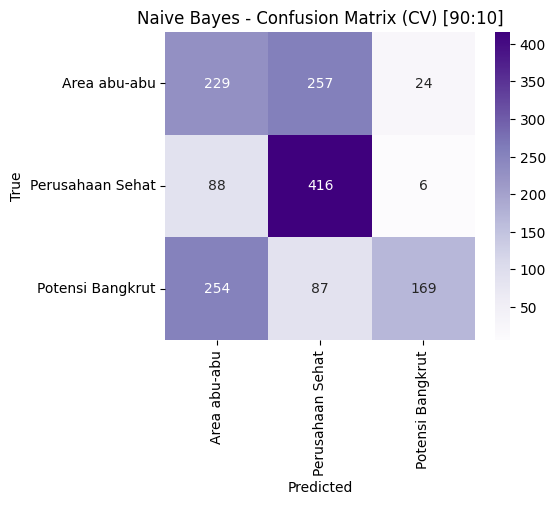

Overall CV Accuracy: 0.5320

--- XGBoost ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.87      0.88      0.87       510
Perusahaan Sehat       0.91      0.91      0.91       510
Potensi Bangkrut       0.93      0.92      0.92       510

        accuracy                           0.90      1530
       macro avg       0.90      0.90      0.90      1530
    weighted avg       0.90      0.90      0.90      1530



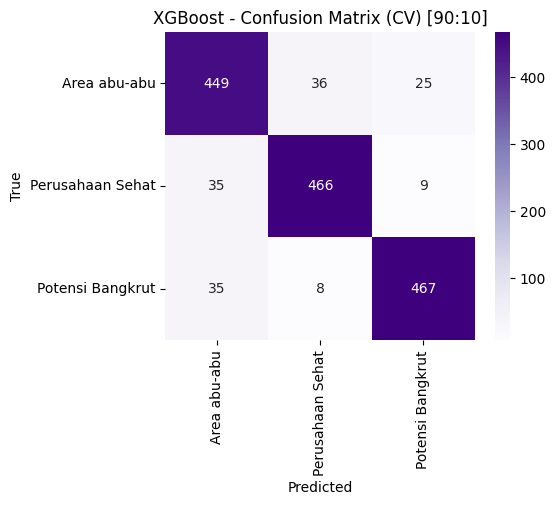

Overall CV Accuracy: 0.9033

=================== Split 80:20 ===================

--- Decision Tree ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.73      0.82      0.78       453
Perusahaan Sehat       0.87      0.82      0.85       453
Potensi Bangkrut       0.88      0.82      0.85       453

        accuracy                           0.82      1359
       macro avg       0.83      0.82      0.82      1359
    weighted avg       0.83      0.82      0.82      1359



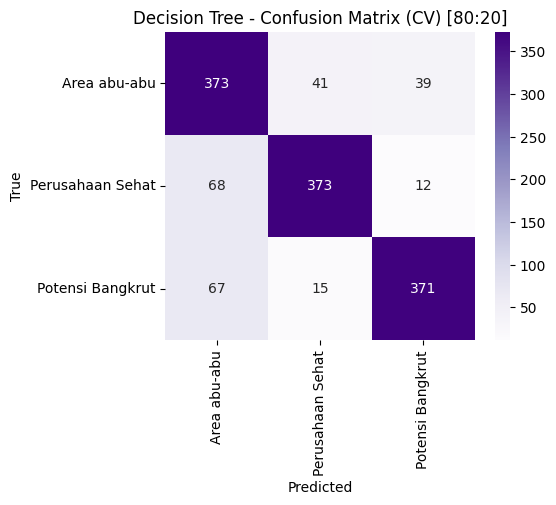

Overall CV Accuracy: 0.8219

--- Random Forest ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.88      0.88      0.88       453
Perusahaan Sehat       0.94      0.92      0.93       453
Potensi Bangkrut       0.92      0.93      0.92       453

        accuracy                           0.91      1359
       macro avg       0.91      0.91      0.91      1359
    weighted avg       0.91      0.91      0.91      1359



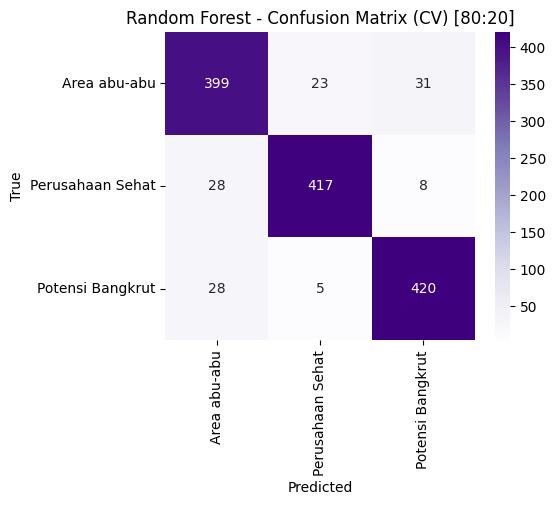

Overall CV Accuracy: 0.9095

--- SVM ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.83      0.90      0.86       453
Perusahaan Sehat       0.86      0.84      0.85       453
Potensi Bangkrut       0.92      0.86      0.89       453

        accuracy                           0.87      1359
       macro avg       0.87      0.87      0.87      1359
    weighted avg       0.87      0.87      0.87      1359



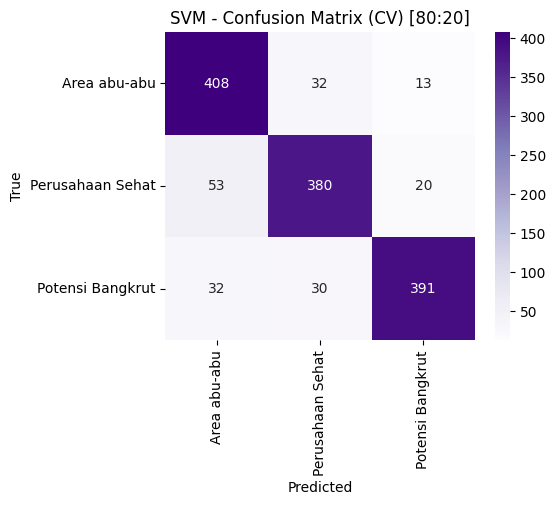

Overall CV Accuracy: 0.8675

--- KNN ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.82      0.92      0.87       453
Perusahaan Sehat       0.92      0.81      0.86       453
Potensi Bangkrut       0.91      0.90      0.91       453

        accuracy                           0.88      1359
       macro avg       0.88      0.88      0.88      1359
    weighted avg       0.88      0.88      0.88      1359



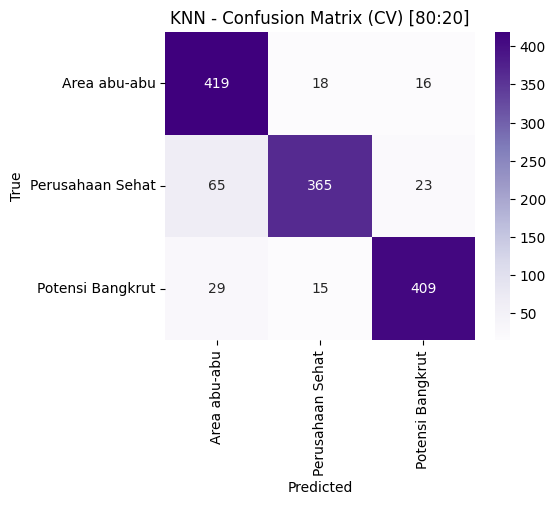

Overall CV Accuracy: 0.8779

--- Naive Bayes ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.38      0.33      0.36       453
Perusahaan Sehat       0.56      0.80      0.66       453
Potensi Bangkrut       0.61      0.43      0.51       453

        accuracy                           0.52      1359
       macro avg       0.52      0.52      0.51      1359
    weighted avg       0.52      0.52      0.51      1359



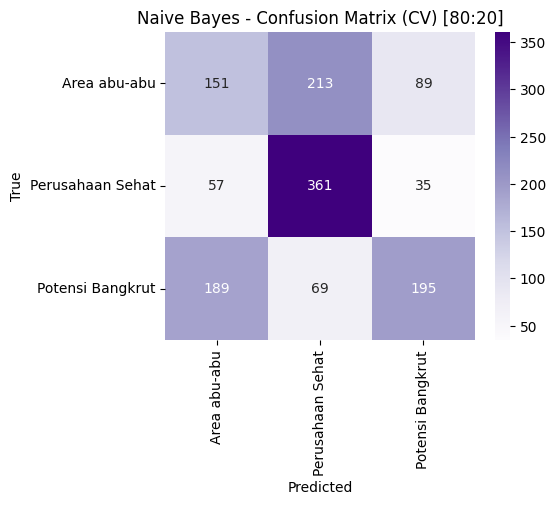

Overall CV Accuracy: 0.5202

--- XGBoost ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.88      0.89      0.89       453
Perusahaan Sehat       0.92      0.91      0.92       453
Potensi Bangkrut       0.92      0.93      0.92       453

        accuracy                           0.91      1359
       macro avg       0.91      0.91      0.91      1359
    weighted avg       0.91      0.91      0.91      1359



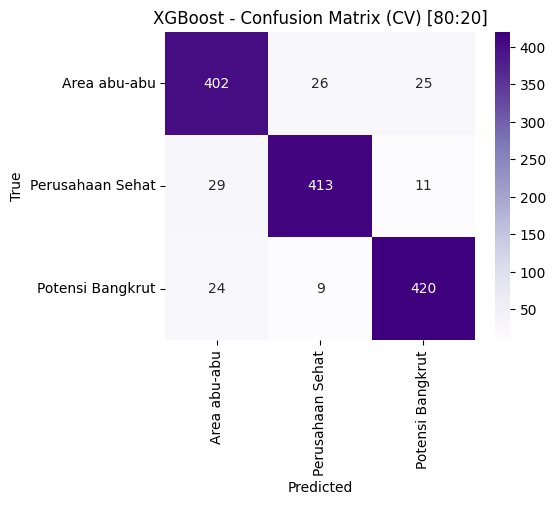

Overall CV Accuracy: 0.9088

=================== Split 70:30 ===================

--- Decision Tree ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.76      0.83      0.79       397
Perusahaan Sehat       0.87      0.82      0.85       397
Potensi Bangkrut       0.86      0.83      0.85       397

        accuracy                           0.83      1191
       macro avg       0.83      0.83      0.83      1191
    weighted avg       0.83      0.83      0.83      1191



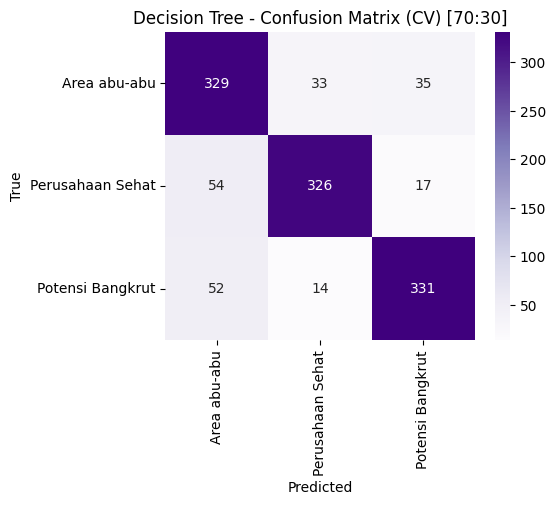

Overall CV Accuracy: 0.8279

--- Random Forest ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.87      0.89      0.88       397
Perusahaan Sehat       0.93      0.92      0.93       397
Potensi Bangkrut       0.93      0.91      0.92       397

        accuracy                           0.91      1191
       macro avg       0.91      0.91      0.91      1191
    weighted avg       0.91      0.91      0.91      1191



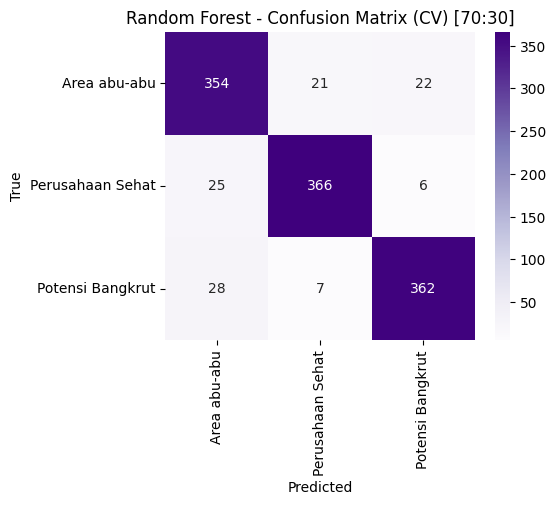

Overall CV Accuracy: 0.9085

--- SVM ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.85      0.90      0.88       397
Perusahaan Sehat       0.85      0.86      0.85       397
Potensi Bangkrut       0.92      0.86      0.89       397

        accuracy                           0.87      1191
       macro avg       0.87      0.87      0.87      1191
    weighted avg       0.87      0.87      0.87      1191



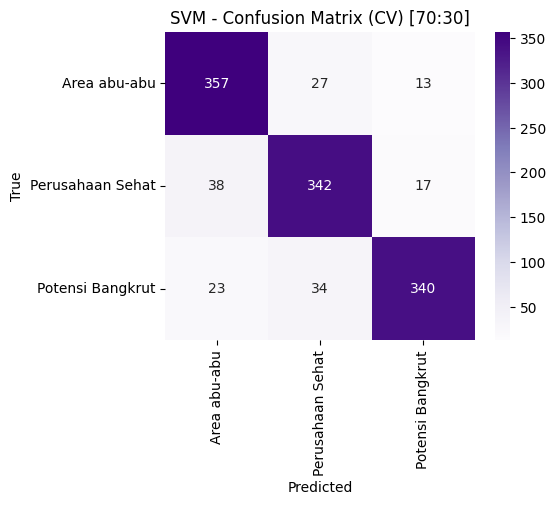

Overall CV Accuracy: 0.8724

--- KNN ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.83      0.91      0.87       397
Perusahaan Sehat       0.90      0.82      0.86       397
Potensi Bangkrut       0.90      0.89      0.90       397

        accuracy                           0.87      1191
       macro avg       0.88      0.87      0.87      1191
    weighted avg       0.88      0.87      0.87      1191



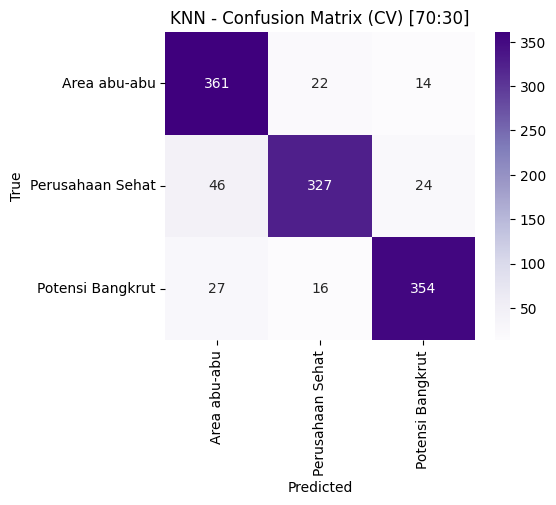

Overall CV Accuracy: 0.8749

--- Naive Bayes ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.41      0.73      0.52       397
Perusahaan Sehat       0.63      0.58      0.61       397
Potensi Bangkrut       0.79      0.24      0.36       397

        accuracy                           0.52      1191
       macro avg       0.61      0.52      0.50      1191
    weighted avg       0.61      0.52      0.50      1191



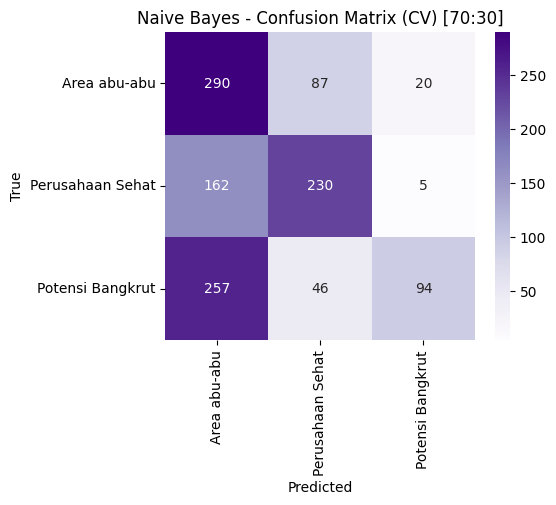

Overall CV Accuracy: 0.5155

--- XGBoost ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.87      0.90      0.88       397
Perusahaan Sehat       0.92      0.91      0.92       397
Potensi Bangkrut       0.95      0.92      0.93       397

        accuracy                           0.91      1191
       macro avg       0.91      0.91      0.91      1191
    weighted avg       0.91      0.91      0.91      1191



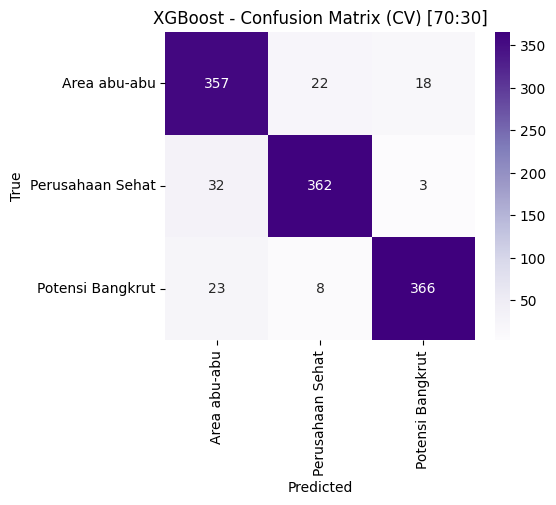

Overall CV Accuracy: 0.9110

=================== Split 60:40 ===================

--- Decision Tree ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.74      0.81      0.77       340
Perusahaan Sehat       0.86      0.80      0.83       340
Potensi Bangkrut       0.86      0.84      0.85       340

        accuracy                           0.82      1020
       macro avg       0.82      0.82      0.82      1020
    weighted avg       0.82      0.82      0.82      1020



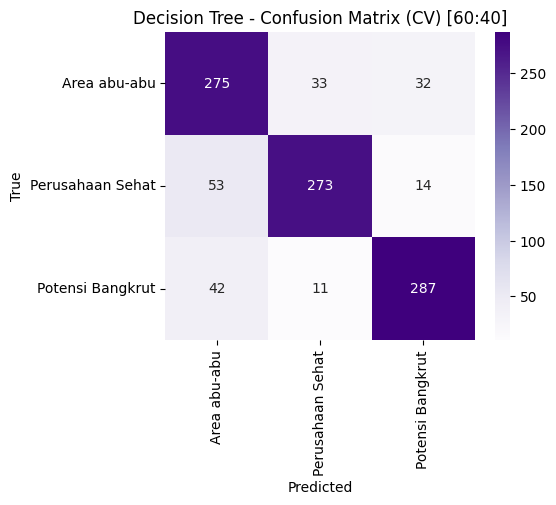

Overall CV Accuracy: 0.8186

--- Random Forest ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.89      0.87      0.88       340
Perusahaan Sehat       0.90      0.93      0.91       340
Potensi Bangkrut       0.92      0.92      0.92       340

        accuracy                           0.91      1020
       macro avg       0.91      0.91      0.91      1020
    weighted avg       0.91      0.91      0.91      1020



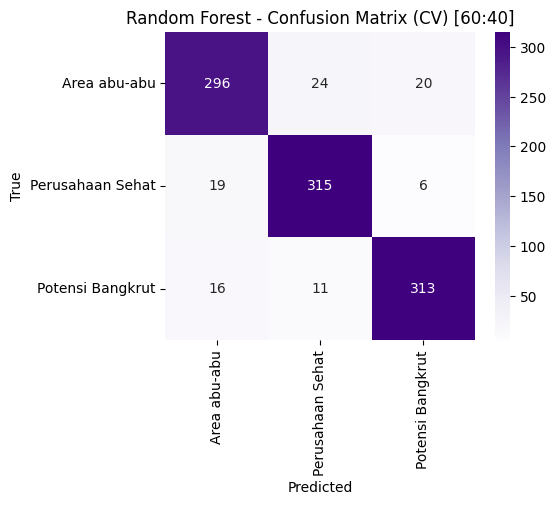

Overall CV Accuracy: 0.9059

--- SVM ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.82      0.89      0.85       340
Perusahaan Sehat       0.85      0.81      0.83       340
Potensi Bangkrut       0.88      0.85      0.87       340

        accuracy                           0.85      1020
       macro avg       0.85      0.85      0.85      1020
    weighted avg       0.85      0.85      0.85      1020



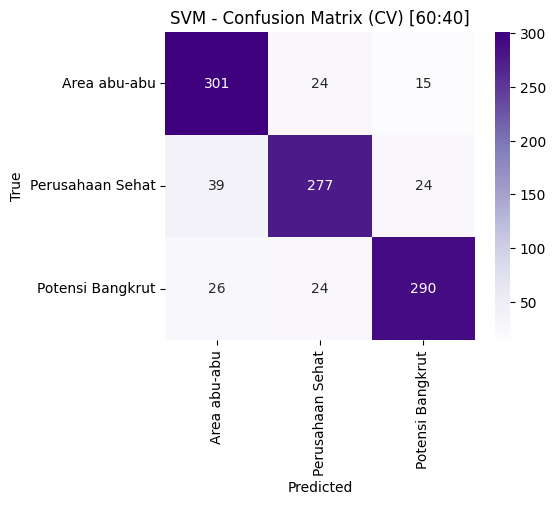

Overall CV Accuracy: 0.8510

--- KNN ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.75      0.91      0.82       340
Perusahaan Sehat       0.89      0.76      0.82       340
Potensi Bangkrut       0.90      0.84      0.87       340

        accuracy                           0.84      1020
       macro avg       0.85      0.84      0.84      1020
    weighted avg       0.85      0.84      0.84      1020



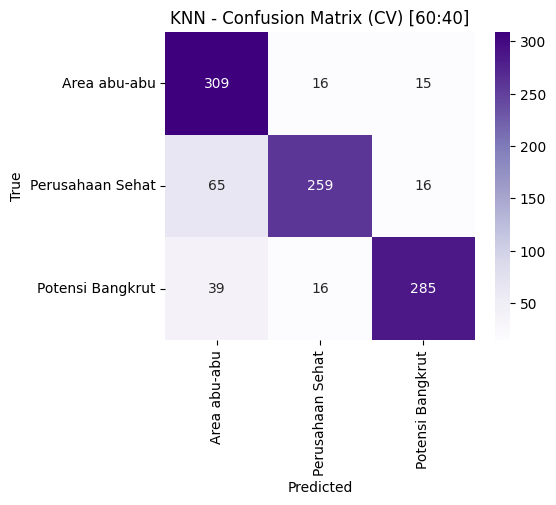

Overall CV Accuracy: 0.8363

--- Naive Bayes ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.46      0.66      0.54       340
Perusahaan Sehat       0.66      0.59      0.62       340
Potensi Bangkrut       0.72      0.49      0.58       340

        accuracy                           0.58      1020
       macro avg       0.61      0.58      0.58      1020
    weighted avg       0.61      0.58      0.58      1020



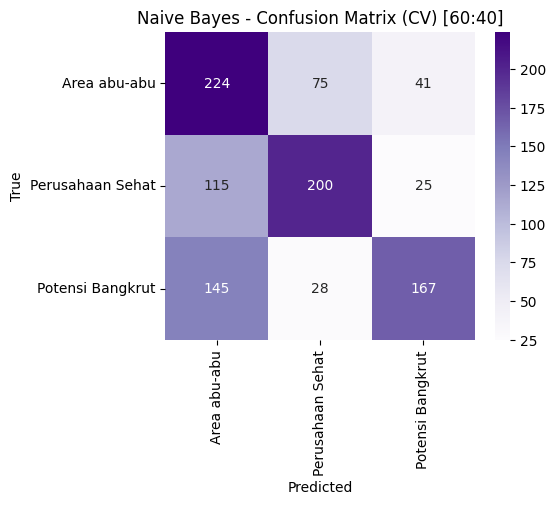

Overall CV Accuracy: 0.5794

--- XGBoost ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.86      0.88      0.87       340
Perusahaan Sehat       0.90      0.88      0.89       340
Potensi Bangkrut       0.94      0.94      0.94       340

        accuracy                           0.90      1020
       macro avg       0.90      0.90      0.90      1020
    weighted avg       0.90      0.90      0.90      1020



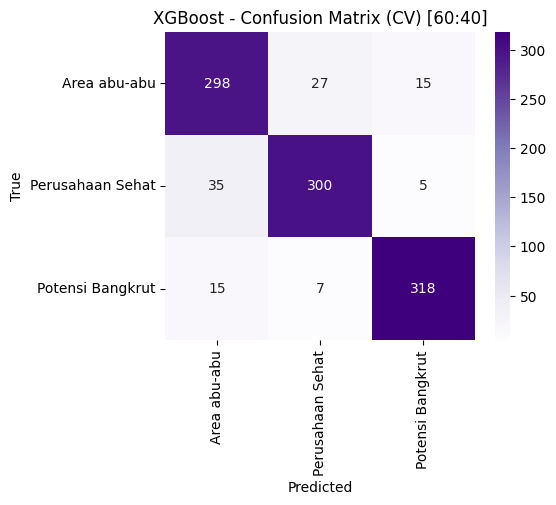

Overall CV Accuracy: 0.8980

=================== Split 50:50 ===================

--- Decision Tree ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.72      0.80      0.76       283
Perusahaan Sehat       0.86      0.79      0.82       283
Potensi Bangkrut       0.86      0.83      0.85       283

        accuracy                           0.81       849
       macro avg       0.81      0.81      0.81       849
    weighted avg       0.81      0.81      0.81       849



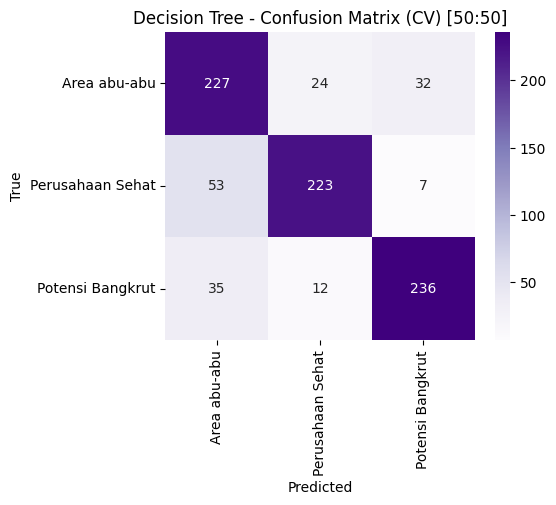

Overall CV Accuracy: 0.8080

--- Random Forest ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.86      0.86      0.86       283
Perusahaan Sehat       0.90      0.91      0.91       283
Potensi Bangkrut       0.91      0.90      0.91       283

        accuracy                           0.89       849
       macro avg       0.89      0.89      0.89       849
    weighted avg       0.89      0.89      0.89       849



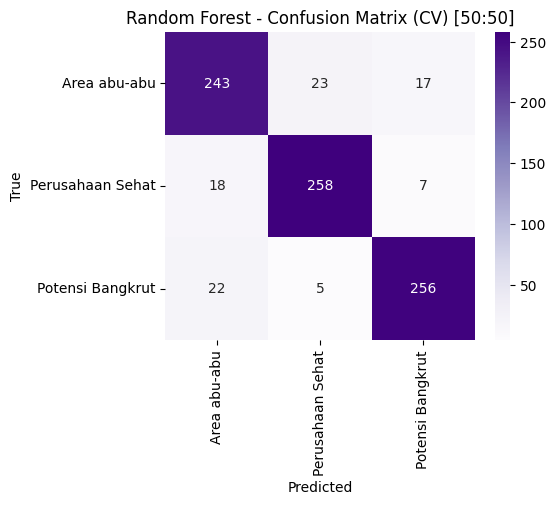

Overall CV Accuracy: 0.8916

--- SVM ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.84      0.88      0.86       283
Perusahaan Sehat       0.85      0.81      0.83       283
Potensi Bangkrut       0.87      0.87      0.87       283

        accuracy                           0.85       849
       macro avg       0.85      0.85      0.85       849
    weighted avg       0.85      0.85      0.85       849



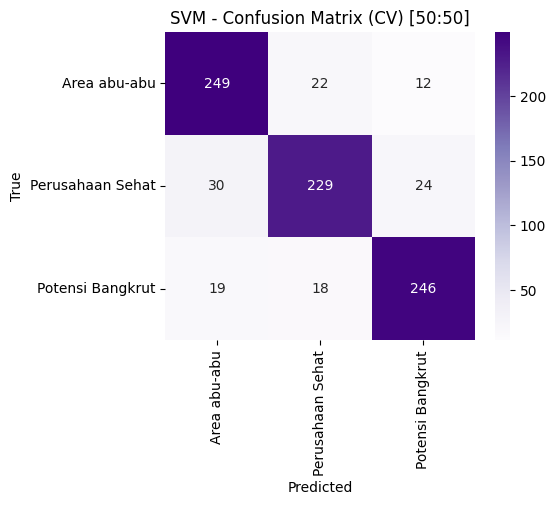

Overall CV Accuracy: 0.8528

--- KNN ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.78      0.90      0.84       283
Perusahaan Sehat       0.91      0.78      0.84       283
Potensi Bangkrut       0.88      0.87      0.88       283

        accuracy                           0.85       849
       macro avg       0.86      0.85      0.85       849
    weighted avg       0.86      0.85      0.85       849



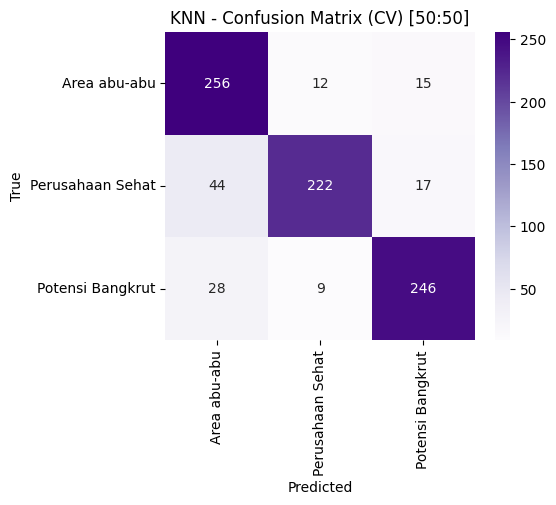

Overall CV Accuracy: 0.8528

--- Naive Bayes ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.56      0.49      0.52       283
Perusahaan Sehat       0.72      0.52      0.60       283
Potensi Bangkrut       0.60      0.84      0.70       283

        accuracy                           0.62       849
       macro avg       0.63      0.62      0.61       849
    weighted avg       0.63      0.62      0.61       849



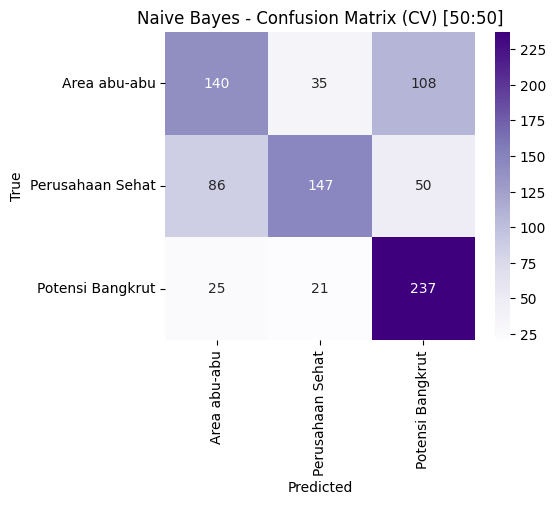

Overall CV Accuracy: 0.6172

--- XGBoost ---

Classification Report (Cross-Validation)
                  precision    recall  f1-score   support

    Area abu-abu       0.86      0.89      0.88       283
Perusahaan Sehat       0.91      0.88      0.89       283
Potensi Bangkrut       0.92      0.92      0.92       283

        accuracy                           0.90       849
       macro avg       0.90      0.90      0.90       849
    weighted avg       0.90      0.90      0.90       849



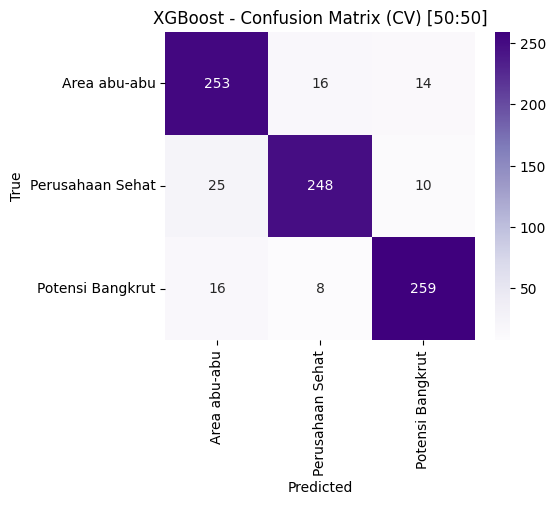

Overall CV Accuracy: 0.8952


In [ ]:
# ====== Label names dan encoding ======
label_names = ["Area abu-abu", "Perusahaan Sehat", "Potensi Bangkrut"]
labels = [0, 1, 2]

# ====== Fungsi cross-validation untuk semua split ======
def cross_val_all_splits(final_splits, trained_models, n_splits=5):
    for split_name, data in final_splits.items():
        print(f"\n=================== Split {split_name} ===================")

        X = data["X_train"]
        y = data["y_train"]

        kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

        for model_name, model in trained_models.items():
            print(f"\n--- {model_name} ---")

            # Prediksi cross-validation
            y_pred_cv = cross_val_predict(model, X, y, cv=kf)

            # Classification report
            print("\nClassification Report (Cross-Validation)")
            print(classification_report(y, y_pred_cv, labels=labels, target_names=label_names))

            # Confusion matrix
            cm_cv = confusion_matrix(y, y_pred_cv, labels=labels)
            plt.figure(figsize=(5,4))
            sns.heatmap(cm_cv, annot=True, fmt="d", cmap="Purples",
                        xticklabels=label_names, yticklabels=label_names)
            plt.title(f"{model_name} - Confusion Matrix (CV) [{split_name}]")
            plt.xlabel("Predicted")
            plt.ylabel("True")
            plt.show()

            # Akurasi rata-rata
            accuracy = np.mean(y_pred_cv == y)
            print(f"Overall CV Accuracy: {accuracy:.4f}")

# ====== Jalankan cross-validation untuk semua split ======
cross_val_all_splits(final_splits, trained_models, n_splits=5)


Dapat diketahui bahwa Random Forest dan XGBoost konsisten menjadi dua model terbaik di semua skenario split data. Pada split 90:10, keduanya mencatatkan akurasi cross-validation di atas 91%, dengan XGBoost sedikit unggul (91,11%) dibanding Random Forest (91,05%). Performa stabil juga terlihat pada split 80:20 dan 70:30, di mana kedua model tetap berada di kisaran 90%, menunjukkan kemampuan generalisasi yang baik meski ukuran data latih berkurang. Pada split yang lebih ekstrem seperti 60:40 dan 50:50, akurasi memang sedikit menurun, tetapi tetap tinggi (sekitar 88–90%) dibandingkan model lain.

Sementara itu, Decision Tree dan SVM memperlihatkan performa menengah dengan akurasi sekitar 81–85%, cukup baik tetapi tidak sekuat Random Forest maupun XGBoost. K-NN berada sedikit di bawahnya dengan akurasi stabil di kisaran 84–87%, menunjukkan sensitivitas terhadap distribusi data latih dan uji. Sebaliknya, Naive Bayes konsisten menghasilkan performa terendah, hanya sekitar 51–62%, yang mengindikasikan model ini kurang sesuai untuk dataset yang kompleks. Secara keseluruhan, **XGBoost dan Random Forest dengan split 80:20 dapat dianggap paling optimal**, karena keduanya memberikan keseimbangan terbaik antara ukuran data latih dan data uji dengan akurasi yang tetap tinggi dan stabil.


Decision Tree - Accuracy per fold: [0.76470588 0.80882353 0.86029412 0.83823529 0.88970588 0.80882353
 0.83088235 0.88235294 0.79411765 0.80740741]
Decision Tree - Mean Accuracy: 0.8285 ± 0.0377


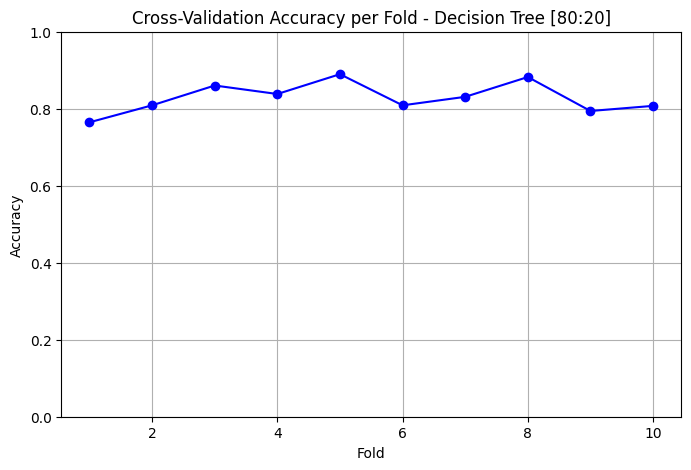


Random Forest - Accuracy per fold: [0.88970588 0.88970588 0.90441176 0.89705882 0.94852941 0.86764706
 0.91176471 0.92647059 0.88235294 0.9037037 ]
Random Forest - Mean Accuracy: 0.9021 ± 0.0218


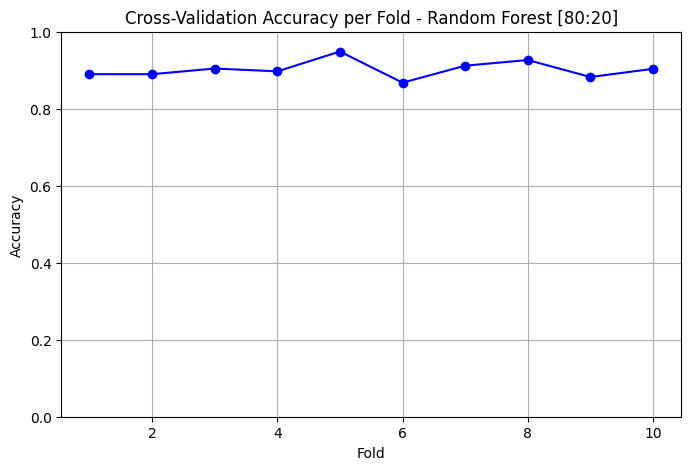


SVM - Accuracy per fold: [0.82352941 0.85294118 0.85294118 0.83088235 0.89705882 0.875
 0.81617647 0.91176471 0.80882353 0.8962963 ]
SVM - Mean Accuracy: 0.8565 ± 0.0351


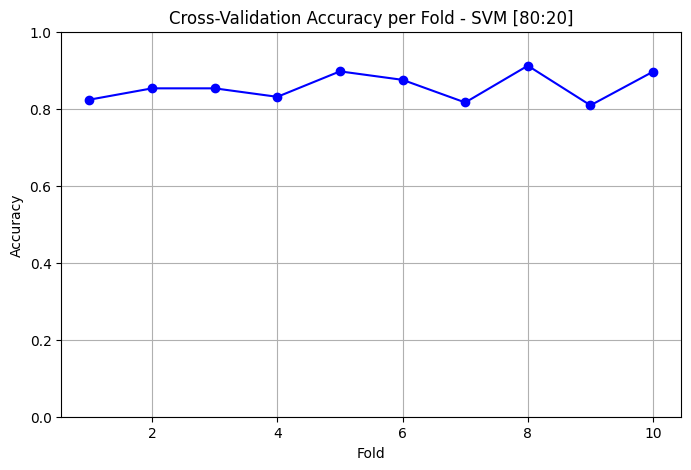


KNN - Accuracy per fold: [0.88235294 0.84558824 0.89705882 0.91911765 0.92647059 0.88235294
 0.91911765 0.86764706 0.83823529 0.9037037 ]
KNN - Mean Accuracy: 0.8882 ± 0.0292


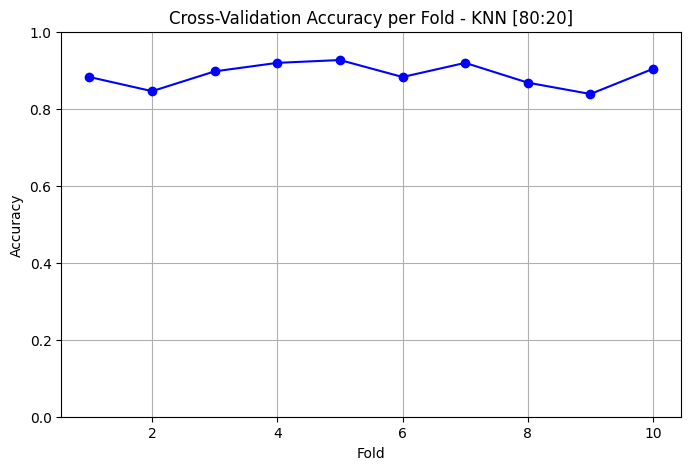


Naive Bayes - Accuracy per fold: [0.55147059 0.52205882 0.58088235 0.52941176 0.49264706 0.55882353
 0.46323529 0.57352941 0.49264706 0.45925926]
Naive Bayes - Mean Accuracy: 0.5224 ± 0.0418


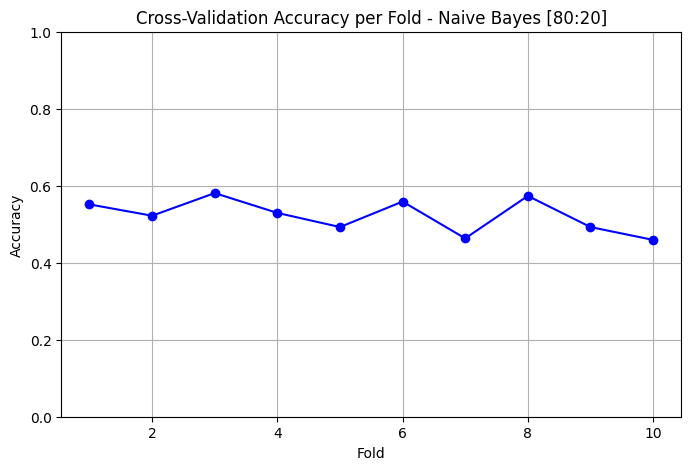


XGBoost - Accuracy per fold: [0.89705882 0.86029412 0.88970588 0.92647059 0.94852941 0.88970588
 0.91176471 0.93382353 0.91176471 0.91851852]
XGBoost - Mean Accuracy: 0.9088 ± 0.0242


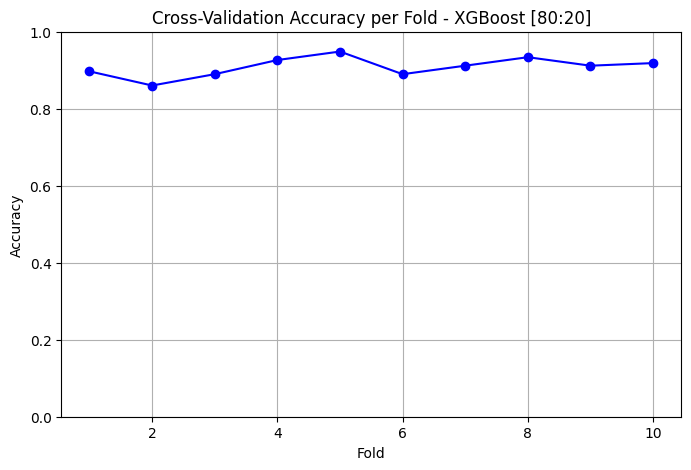

In [ ]:
RANDOM_STATE = 42

# Ambil data train dari split 80:20
X_train = final_splits["80:20"]["X_train"]
y_train = final_splits["80:20"]["y_train"]

# ====== Definisikan model dengan best params ======
trained_models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=20, min_samples_split=2, min_samples_leaf=1,
        criterion='log_loss', random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=240, max_depth=21, min_samples_split=5,
        min_samples_leaf=2, bootstrap=False, random_state=RANDOM_STATE
    ),
    "SVM": SVC(
        C=98.61487754667395, kernel='poly', gamma='auto',
        probability=True, random_state=RANDOM_STATE
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=2, weights='distance', p=1
    ),
    "Naive Bayes": GaussianNB(
        var_smoothing=9.807133584285686e-07
    ),
    "XGBoost": XGBClassifier(
        n_estimators=205, max_depth=12, learning_rate=0.1478431813490956,
        subsample=0.7781217203321238, colsample_bytree=0.5800044728031379,
        use_label_encoder=False, eval_metric="mlogloss", random_state=RANDOM_STATE
    )
}

# ====== Cross-validation 10-fold dengan plot per fold ======
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

for model_name, model in trained_models.items():
    # Hitung akurasi tiap fold
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')

    # Print akurasi
    print(f"\n{model_name} - Accuracy per fold: {scores}")
    print(f"{model_name} - Mean Accuracy: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

    # Plot hasil cross-validation
    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(scores)+1), scores, marker='o', linestyle='-', color='blue')
    plt.title(f'Cross-Validation Accuracy per Fold - {model_name} [80:20]')
    plt.xlabel('Fold')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)
    plt.grid(True)
    plt.show()


In [ ]:
#--Ambil hanya Random Forest dan SVM
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}


In [ ]:
#CEK URUTAN LABEL
print(sorted(y_train.unique()))


[np.int64(0), np.int64(1), np.int64(2)]


In [ ]:
label_names = ["0","1", "2" ]


🔹 Evaluasi Split 90:10

=== Random Forest ===

[Train Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       510
           1       1.00      1.00      1.00       510
           2       1.00      1.00      1.00       510

    accuracy                           1.00      1530
   macro avg       1.00      1.00      1.00      1530
weighted avg       1.00      1.00      1.00      1530


[Val Report]
              precision    recall  f1-score   support

           0       0.55      0.55      0.55        11
           1       0.81      0.89      0.85        28
           2       1.00      0.85      0.92        20

    accuracy                           0.81        59
   macro avg       0.78      0.76      0.77        59
weighted avg       0.82      0.81      0.82        59


[Test Report]
              precision    recall  f1-score   support

           0       0.86      0.55      0.67        11
           1       0.85      1.00    

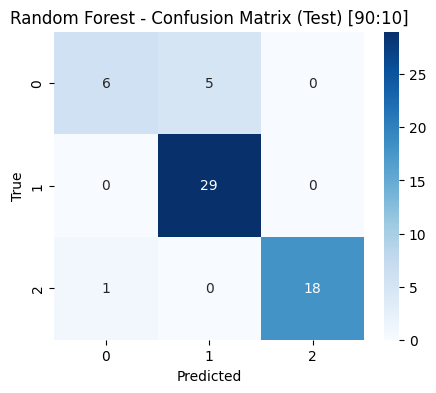


=== SVM ===

[Train Report]
              precision    recall  f1-score   support

           0       0.37      0.93      0.53       510
           1       1.00      0.03      0.06       510
           2       0.76      0.35      0.48       510

    accuracy                           0.44      1530
   macro avg       0.71      0.44      0.36      1530
weighted avg       0.71      0.44      0.36      1530


[Val Report]
              precision    recall  f1-score   support

           0       0.19      0.73      0.30        11
           1       1.00      0.04      0.07        28
           2       0.69      0.55      0.61        20

    accuracy                           0.34        59
   macro avg       0.63      0.44      0.33        59
weighted avg       0.74      0.34      0.30        59


[Test Report]
              precision    recall  f1-score   support

           0       0.22      1.00      0.35        11
           1       0.00      0.00      0.00        29
           2     

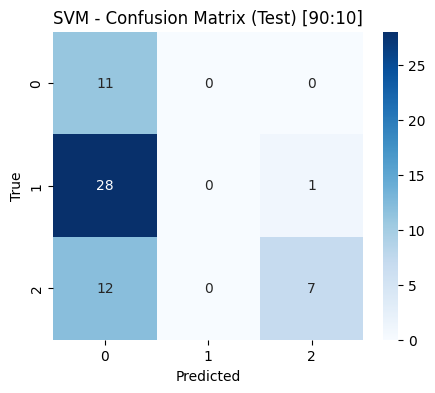


🔹 Evaluasi Split 80:20

=== Random Forest ===

[Train Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       453
           1       1.00      1.00      1.00       453
           2       1.00      1.00      1.00       453

    accuracy                           1.00      1359
   macro avg       1.00      1.00      1.00      1359
weighted avg       1.00      1.00      1.00      1359


[Val Report]
              precision    recall  f1-score   support

           0       0.57      0.57      0.57        21
           1       0.87      0.96      0.92        57
           2       0.94      0.79      0.86        39

    accuracy                           0.84       117
   macro avg       0.79      0.78      0.78       117
weighted avg       0.84      0.84      0.84       117


[Test Report]
              precision    recall  f1-score   support

           0       0.75      0.41      0.53        22
           1       0.85      0.96    

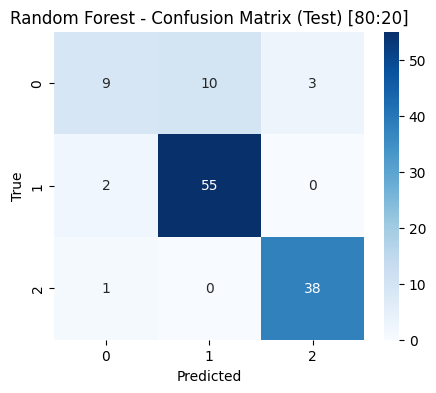


=== SVM ===

[Train Report]
              precision    recall  f1-score   support

           0       0.39      0.90      0.54       453
           1       0.80      0.04      0.08       453
           2       0.79      0.50      0.61       453

    accuracy                           0.48      1359
   macro avg       0.66      0.48      0.41      1359
weighted avg       0.66      0.48      0.41      1359


[Val Report]
              precision    recall  f1-score   support

           0       0.20      0.81      0.33        21
           1       1.00      0.07      0.13        57
           2       0.73      0.56      0.64        39

    accuracy                           0.37       117
   macro avg       0.65      0.48      0.37       117
weighted avg       0.77      0.37      0.34       117


[Test Report]
              precision    recall  f1-score   support

           0       0.21      0.82      0.34        22
           1       0.00      0.00      0.00        57
           2     

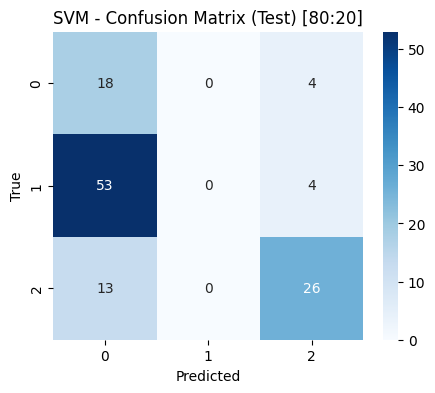


🔹 Evaluasi Split 70:30

=== Random Forest ===

[Train Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       397
           1       1.00      1.00      1.00       397
           2       1.00      1.00      1.00       397

    accuracy                           1.00      1191
   macro avg       1.00      1.00      1.00      1191
weighted avg       1.00      1.00      1.00      1191


[Val Report]
              precision    recall  f1-score   support

           0       0.73      0.59      0.66        32
           1       0.88      0.96      0.92        85
           2       0.91      0.88      0.90        59

    accuracy                           0.87       176
   macro avg       0.84      0.81      0.82       176
weighted avg       0.86      0.87      0.86       176


[Test Report]
              precision    recall  f1-score   support

           0       0.60      0.38      0.46        32
           1       0.85      0.93    

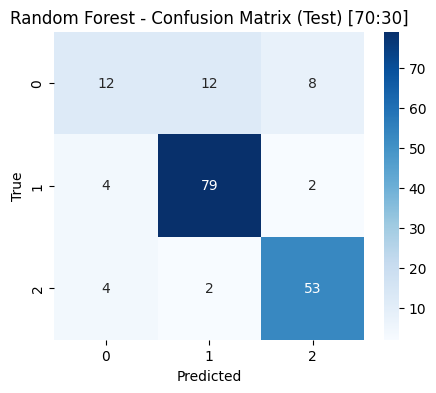


=== SVM ===

[Train Report]
              precision    recall  f1-score   support

           0       0.39      0.36      0.37       397
           1       0.89      0.02      0.04       397
           2       0.40      0.83      0.54       397

    accuracy                           0.40      1191
   macro avg       0.56      0.40      0.32      1191
weighted avg       0.56      0.40      0.32      1191


[Val Report]
              precision    recall  f1-score   support

           0       0.22      0.38      0.28        32
           1       1.00      0.04      0.07        85
           2       0.43      0.86      0.57        59

    accuracy                           0.38       176
   macro avg       0.55      0.42      0.31       176
weighted avg       0.67      0.38      0.28       176


[Test Report]
              precision    recall  f1-score   support

           0       0.19      0.28      0.23        32
           1       0.67      0.02      0.05        85
           2     

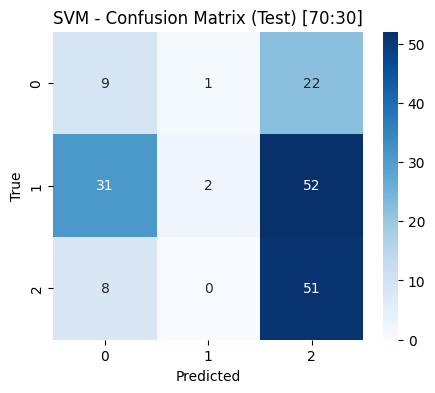


🔹 Evaluasi Split 60:40

=== Random Forest ===

[Train Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       340
           1       1.00      1.00      1.00       340
           2       1.00      1.00      1.00       340

    accuracy                           1.00      1020
   macro avg       1.00      1.00      1.00      1020
weighted avg       1.00      1.00      1.00      1020


[Val Report]
              precision    recall  f1-score   support

           0       0.66      0.53      0.59        43
           1       0.88      0.95      0.91       113
           2       0.87      0.86      0.86        78

    accuracy                           0.84       234
   macro avg       0.80      0.78      0.79       234
weighted avg       0.83      0.84      0.84       234


[Test Report]
              precision    recall  f1-score   support

           0       0.83      0.57      0.68        42
           1       0.87      0.96    

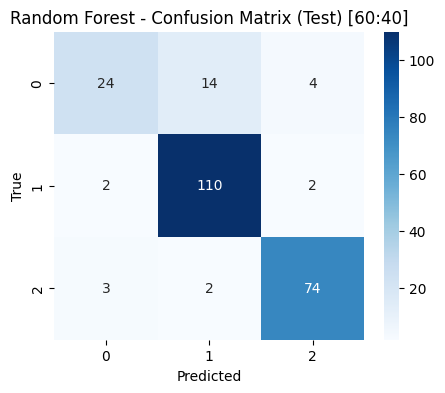


=== SVM ===

[Train Report]
              precision    recall  f1-score   support

           0       0.41      0.76      0.53       340
           1       0.46      0.24      0.31       340
           2       0.75      0.49      0.60       340

    accuracy                           0.50      1020
   macro avg       0.54      0.50      0.48      1020
weighted avg       0.54      0.50      0.48      1020


[Val Report]
              precision    recall  f1-score   support

           0       0.21      0.63      0.32        43
           1       0.57      0.22      0.32       113
           2       0.63      0.51      0.57        78

    accuracy                           0.39       234
   macro avg       0.47      0.45      0.40       234
weighted avg       0.53      0.39      0.40       234


[Test Report]
              precision    recall  f1-score   support

           0       0.23      0.71      0.35        42
           1       0.65      0.26      0.38       114
           2     

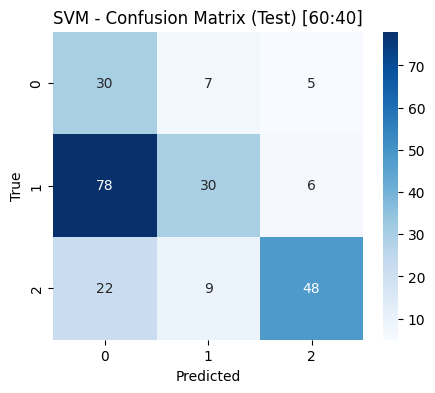


🔹 Evaluasi Split 50:50

=== Random Forest ===

[Train Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       283
           1       1.00      1.00      1.00       283
           2       1.00      1.00      1.00       283

    accuracy                           1.00       849
   macro avg       1.00      1.00      1.00       849
weighted avg       1.00      1.00      1.00       849


[Val Report]
              precision    recall  f1-score   support

           0       0.64      0.53      0.58        53
           1       0.88      0.94      0.91       142
           2       0.90      0.90      0.90        98

    accuracy                           0.85       293
   macro avg       0.81      0.79      0.79       293
weighted avg       0.84      0.85      0.84       293


[Test Report]
              precision    recall  f1-score   support

           0       0.62      0.47      0.54        53
           1       0.86      0.93    

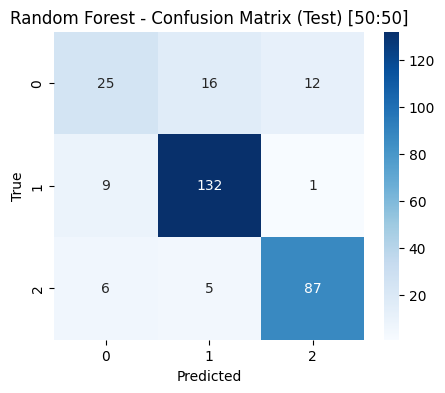


=== SVM ===

[Train Report]
              precision    recall  f1-score   support

           0       0.33      0.11      0.16       283
           1       0.40      0.31      0.35       283
           2       0.40      0.76      0.52       283

    accuracy                           0.39       849
   macro avg       0.38      0.39      0.34       849
weighted avg       0.38      0.39      0.34       849


[Val Report]
              precision    recall  f1-score   support

           0       0.13      0.08      0.10        53
           1       0.54      0.29      0.38       142
           2       0.39      0.73      0.51        98

    accuracy                           0.40       293
   macro avg       0.35      0.37      0.33       293
weighted avg       0.41      0.40      0.37       293


[Test Report]
              precision    recall  f1-score   support

           0       0.15      0.09      0.12        53
           1       0.63      0.33      0.43       142
           2     

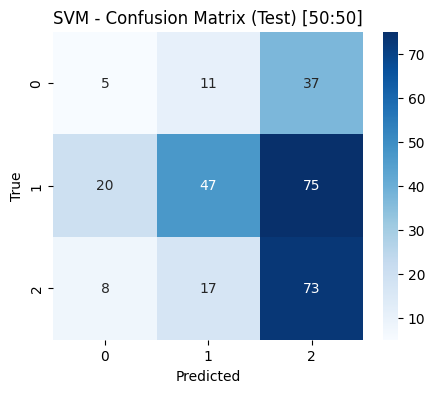

In [ ]:
baseline_results = run_baseline_models(final_splits, models, label_names)


In [ ]:
#2. Menampilkan Accuracy, Precision, Recall, F1-score Secara Ringkas
import pandas as pd

def summarize_results(results):
    summary = []

    for split_name, model_results in results.items():
        for model_name, reports in model_results.items():
            test_report = reports["test_report"]["weighted avg"]

            summary.append({
                "Split": split_name,
                "Model": model_name,
                "Accuracy": reports["test_report"]["accuracy"],
                "Precision": test_report["precision"],
                "Recall": test_report["recall"],
                "F1 Score": test_report["f1-score"]
            })

    return pd.DataFrame(summary)

summary_df = summarize_results(baseline_results)
summary_df


,Split,Model,Accuracy,Precision,Recall,F1 Score
0,90:10,Random Forest,0.898305,0.901082,0.898305,0.890140
1,90:10,SVM,0.305085,0.321992,0.305085,0.233137
2,80:20,Random Forest,0.864407,0.854891,0.864407,0.848225
3,80:20,SVM,0.372881,0.292693,0.372881,0.298750
4,70:30,Random Forest,0.818182,0.801359,0.818182,0.803869
5,70:30,SVM,0.352273,0.492833,0.352273,0.248694
6,60:40,Random Forest,0.885106,0.882372,0.885106,0.878421
7,60:40,SVM,0.459574,0.631112,0.459574,0.478118
8,50:50,Random Forest,0.832765,0.822167,0.832765,0.824894
9,50:50,SVM,0.426621,0.463096,0.426621,0.403524


In [ ]:
#TUNING
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30],
    "min_samples_split": [2, 5, 10]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid_rf,
                       cv=5,
                       scoring='f1_macro')

grid_rf.fit(X_train, y_train)
print(grid_rf.best_params_)


{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}



================= Random Forest (Tuned) =================
Accuracy : 0.847457627118644
Precision: 0.8210150283321015
Recall   : 0.7590888643520222
F1-Score : 0.7680524759793053

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.36      0.48        22
           1       0.83      0.96      0.89        57
           2       0.90      0.95      0.93        39

    accuracy                           0.85       118
   macro avg       0.82      0.76      0.77       118
weighted avg       0.84      0.85      0.83       118



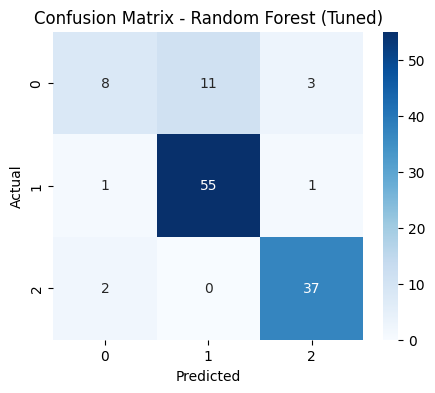


================= SVM (Tuned) =================
Accuracy : 0.7966101694915254
Precision: 0.7598064929766276
Recall   : 0.7531182268024373
F1-Score : 0.7547305561551191

Classification Report:

              precision    recall  f1-score   support

           0       0.63      0.55      0.59        22
           1       0.86      0.84      0.85        57
           2       0.79      0.87      0.83        39

    accuracy                           0.80       118
   macro avg       0.76      0.75      0.75       118
weighted avg       0.79      0.80      0.79       118



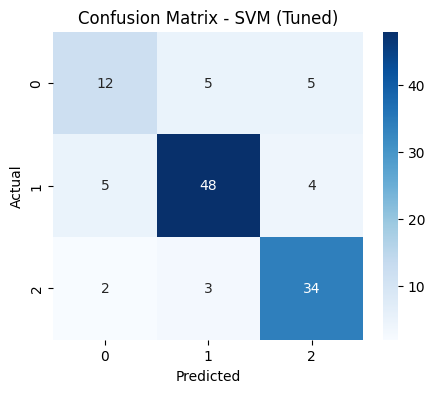

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ambil data train-test sesuai split yang dipilih
X_train = final_splits["80:20"]["X_train"]
y_train = final_splits["80:20"]["y_train"]
X_test  = final_splits["80:20"]["X_test"]
y_test  = final_splits["80:20"]["y_test"]

# Ambil parameter terbaik
best_rf_params = best_params_all["Random Forest"]
best_svm_params = best_params_all["SVM"]

# Buat model baru dengan best params
rf_model = RandomForestClassifier(**best_rf_params, random_state=42)
svm_model = SVC(**best_svm_params, probability=True, random_state=42)

# Train model
rf_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)
svm_pred = svm_model.predict(X_test)

# Function untuk evaluasi
def evaluate(model_name, y_true, y_pred):
    print(f"\n================= {model_name} =================")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='macro'))
    print("Recall   :", recall_score(y_true, y_pred, average='macro'))
    print("F1-Score :", f1_score(y_true, y_pred, average='macro'))
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Evaluasi
evaluate("Random Forest (Tuned)", y_test, rf_pred)
evaluate("SVM (Tuned)", y_test, svm_pred)


In [1]:
import pandas as pd
import numpy as np
import joblib 
from sklearn.preprocessing import OneHotEncoder # Tetap diimpor, tapi hanya untuk konfigurasi awal

# --- 0. KONFIGURASI DAN PEMUATAN OBJEK ---
# (Semua konfigurasi dan pemuatan model/scaler/encoder tetap sama)

# Kolom input ASLI yang diminta dari user (sesuai urutan input)
ORIGINAL_INPUT_COLS = [
    'Sub_Sektor', 'Current_Ratio', 'Cash_Ratio', 'DAR', 'DER', 'NPM', 'ROA', 'ROE',
    'Kepemilikan_Mayoritas', 'Komisaris_Independen', 'Insider_Ownership',
    'BoC_Size', 'BoC_Education', 'TMT_Size_DK', 'TMT_Size_DD',
    'TMT_Education_DK', 'TMT_Education_DD', 'Total_Asset', 'Pertumbuhan_Revenue' 
]

# Definisi Pembagian Kolom untuk Scaling
cols_robust = ["Current_Ratio", "Cash_Ratio", "DER", "NPM", "ROA", "ROE",
               "Total_Asset", "Pertumbuhan_Revenue"]
standard_cols = ["Kepemilikan_Mayoritas", "Komisaris_Independen",
                 "BoC_Size", "TMT_Size_DK", "TMT_Size_DD"]

# Definisi Label Kelas
CLASS_LABELS = {
    0: "Area abu-abu",
    1: "Perusahaan Sehat",
    2: "Potensi Bangkrut"
}

# Mapping untuk mempermudah input Sub_Sektor
SUB_SEKTOR_MAPPING = {
    0: 'Asuransi Jiwa',
    1: 'Asuransi Umum',
    2: 'Reasuransi',
    3: 'Asuransi Wajib',
    4: 'Asuransi Sosial'
}

# Daftar kolom final yang HARUS SESUAI dengan urutan index yang dilihat model saat training
FINAL_MODEL_COLS = [
    'Current_Ratio', 'Cash_Ratio', 'DAR', 'DER', 'NPM', 'ROA', 'ROE',
    'Kepemilikan_Mayoritas', 'Komisaris_Independen', 'Insider_Ownership',
    'BoC_Size', 'BoC_Education', 'TMT_Size_DK', 'TMT_Size_DD',
    'TMT_Education_DK', 'TMT_Education_DD', 'Total_Asset',
    'Pertumbuhan_Revenue', 
    'Sub_Sektor_Asuransi Jiwa',
    'Sub_Sektor_Asuransi Sosial', 
    'Sub_Sektor_Asuransi Umum',
    'Sub_Sektor_Asuransi Wajib', 
    'Sub_Sektor_Reasuransi'
]

# Ambil nama kolom OHE yang diharapkan dari FINAL_MODEL_COLS
OHE_FEATURE_COLUMNS = [col for col in FINAL_MODEL_COLS if col.startswith('Sub_Sektor_')]


# --- PEMUATAN MODEL DAN TRANSFORMER ---
try:
    rf_model = joblib.load('random_forest_80_20_tuned.pkl')
    svm_model = joblib.load('svm_80_20_tuned.pkl')
    print("✅ Model RF dan SVM berhasil dimuat.")

    scaler_robust = joblib.load('robust_scaler_80_20.pkl')
    scaler_standard = joblib.load('standard_scaler_80_20.pkl')
    print("✅ Scaler (robust & standard) 80:20 berhasil dimuat.")
    
    # Encoder OHE tetap dimuat, tapi hanya untuk referensi jika diperlukan
    encoder_ohe = joblib.load('onehot_encoder_80_20.pkl') 
    print("✅ OneHotEncoder 80:20 berhasil dimuat.")
    
except FileNotFoundError as e:
    print(f"❌ ERROR: File tidak ditemukan - {e}. Pastikan semua file (.pkl) ada di lokasi yang benar.")
    exit()


# --- 1. FUNGSI INPUT INTERAKTIF ---

def get_interactive_user_input(columns):
    """Meminta input dari user untuk setiap kolom secara interaktif."""
    
    print("\n=======================================================")
    print("        INPUT NILAI FITUR UNTUK PREDIKSI KELAS")
    print("=======================================================")
    
    user_data = {}
    
    for col in columns:
        while True:
            try:
                # Kolom Sub_Sektor: Minta input angka berdasarkan mapping
                if col == 'Sub_Sektor':
                    print("\n--- Pilihan Sub_Sektor ---")
                    for k, v in SUB_SEKTOR_MAPPING.items():
                        print(f" [{k}] untuk {v}")

                    input_value = input(f"Masukkan angka pilihan untuk '{col}' (Hanya 1 Pilihan): ")
                    choice_key = int(input_value)
                    
                    if choice_key in SUB_SEKTOR_MAPPING:
                        # Simpan kategori tekstual, bukan angka
                        user_data[col] = SUB_SEKTOR_MAPPING[choice_key] 
                        break
                    else:
                        print("⚠️ Pilihan angka tidak valid. Harap masukkan angka yang ada dalam daftar.")
                else:
                    # Logika input numerik
                    input_value = input(f"Masukkan nilai untuk '{col}': ")
                    value = float(input_value)
                    user_data[col] = value
                    break
            except ValueError:
                print("⚠️ Input tidak valid. Harap masukkan nilai numerik (angka) atau angka pilihan yang benar.")
    
    df_new = pd.DataFrame([user_data], columns=columns)
    return df_new


# --- 2. FUNGSI PREPROCESSING DAN PREDIKSI (FINAL) ---

def predict_new_data(df_new, model, scaler_robust, scaler_standard, 
                     cols_robust, standard_cols, final_cols, ohe_cols):
    """Menerapkan preprocessing (OHE Manual, Scaling) dan menghasilkan prediksi."""
    
    # 1. Pisahkan Kolom Sub_Sektor (kategorikal) dan Numerik
    selected_sub_sektor = df_new['Sub_Sektor'].iloc[0]
    df_num = df_new.drop(columns=['Sub_Sektor']).copy()
    
    # 2. Tentukan Kolom yang TIDAK DI-SCALE (Unscaled)
    all_scaled_cols = cols_robust + standard_cols
    unscaled_cols = [col for col in df_num.columns if col not in all_scaled_cols]

    
    # =================================================================
    # A. OHE MANUAL (Solusi Key Alignment)
    # =================================================================
    # a. Buat DataFrame OHE baru dengan semua kolom OHE yang diharapkan
    X_new_encoded_df = pd.DataFrame(0, index=df_new.index, columns=ohe_cols)
    
    # b. Tentukan kolom yang dipilih pengguna
    selected_col_name = f'Sub_Sektor_{selected_sub_sektor}'
    
    # c. Set nilai kolom yang dipilih menjadi 1
    # BARIS INI KINI DIJAMIN BERHASIL KARENA KITA MEMBUAT SEMUA KOLOM OHE DI ATAS
    X_new_encoded_df[selected_col_name] = 1 

    
    # B. Scaling Robust (Hanya .transform)
    X_new_robust_scaled = pd.DataFrame(
        scaler_robust.transform(df_num[cols_robust]),
        columns=cols_robust,
        index=df_num.index
    )
    
    # C. Scaling Standard (Hanya .transform)
    X_new_standard_scaled = pd.DataFrame(
        scaler_standard.transform(df_num[standard_cols]),
        columns=standard_cols,
        index=df_num.index
    )
    
    # D. Menggabungkan SEMUA kolom
    X_new_unscaled = df_num[unscaled_cols]
    
    X_new_processed = pd.concat([
        X_new_robust_scaled, 
        X_new_standard_scaled, 
        X_new_unscaled,
        X_new_encoded_df          # OHE Manual
    ], axis=1)
    
    # Pastikan urutan kolom sesuai dengan saat training (FINAL_MODEL_COLS)
    # Ini mengatasi ValueError: The feature names should match...
    X_new_processed = X_new_processed[final_cols]
    
    # E. Prediksi menggunakan Model
    if hasattr(model, 'predict_proba'):
        prediction_probas = model.predict_proba(X_new_processed)[0]
    else:
        prediction_probas = [0, 0, 0] 
    
    prediction_class = model.predict(X_new_processed)[0]
    
    return prediction_class, prediction_probas


# --- 3. EKSEKUSI UTAMA ---

# 1. Ambil input dari user secara interaktif
df_input = get_interactive_user_input(ORIGINAL_INPUT_COLS)

# 2. TAMPILKAN KONFIRMASI INPUT USER
print("\n=======================================================")
print("          DATA INPUT YANG AKAN DIPROSES")
print("=======================================================")

# Menampilkan data input dalam format vertikal yang rapi
for col in ORIGINAL_INPUT_COLS:
    if col == 'Total_Asset':
        print(f"  {col:<22}: {df_input[col].iloc[0]:,.2f}")
    elif pd.api.types.is_numeric_dtype(df_input[col]):
        print(f"  {col:<22}: {df_input[col].iloc[0]:.4f}")
    else:
        print(f"  {col:<22}: {df_input[col].iloc[0]}")

print("-------------------------------------------------------")

# 3. Lakukan preprocessing dan prediksi untuk kedua model

print("\n\n--- PREDIKSI MODEL RANDOM FOREST ---")
rf_class, rf_probas = predict_new_data(
    df_input, rf_model, scaler_robust, scaler_standard, 
    cols_robust, standard_cols, FINAL_MODEL_COLS, OHE_FEATURE_COLUMNS # Perubahan argumen
)
print(" Probabilitas untuk Setiap Kelas:")
print(f"   Kelas 0 (Area abu-abu):       {rf_probas[0]:.4f}")
print(f"   Kelas 1 (Perusahaan Sehat):   {rf_probas[1]:.4f}")
print(f"   Kelas 2 (Potensi Bangkrut):   {rf_probas[2]:.4f}")
print(f"\n  KELAS PREDIKSI TERPILIH: {CLASS_LABELS[rf_class]} ({rf_class})")
print("=======================================================")


print("\n\n--- PREDIKSI MODEL SVM ---")
svm_class, svm_probas = predict_new_data(
    df_input, svm_model, scaler_robust, scaler_standard, 
    cols_robust, standard_cols, FINAL_MODEL_COLS, OHE_FEATURE_COLUMNS # Perubahan argumen
)

print(" Probabilitas untuk Setiap Kelas:")
print(f"   Kelas 0 (Area abu-abu):       {svm_probas[0]:.4f}")
print(f"   Kelas 1 (Perusahaan Sehat):   {svm_probas[1]:.4f}")
print(f"   Kelas 2 (Potensi Bangkrut):   {svm_probas[2]:.4f}")
print(f"\n  KELAS PREDIKSI TERPILIH: {CLASS_LABELS[svm_class]} ({svm_class})")
print("=======================================================")

✅ Model RF dan SVM berhasil dimuat.
✅ Scaler (robust & standard) 80:20 berhasil dimuat.
✅ OneHotEncoder 80:20 berhasil dimuat.

        INPUT NILAI FITUR UNTUK PREDIKSI KELAS

--- Pilihan Sub_Sektor ---
 [0] untuk Asuransi Jiwa
 [1] untuk Asuransi Umum
 [2] untuk Reasuransi
 [3] untuk Asuransi Wajib
 [4] untuk Asuransi Sosial

          DATA INPUT YANG AKAN DIPROSES
  Sub_Sektor            : Asuransi Umum
  Current_Ratio         : 0.5200
  Cash_Ratio            : 0.1800
  DAR                   : 0.7800
  DER                   : 3.6100
  NPM                   : 0.0900
  ROA                   : 0.0300
  ROE                   : 0.1500
  Kepemilikan_Mayoritas : 0.8000
  Komisaris_Independen  : 2.0000
  Insider_Ownership     : 0.0000
  BoC_Size              : 4.0000
  BoC_Education         : 0.0000
  TMT_Size_DK           : 4.0000
  TMT_Size_DD           : 5.0000
  TMT_Education_DK      : 0.0000
  TMT_Education_DD      : 0.0000
  Total_Asset           : 35,767,906,000,000.00
  Pertumbuhan_R